### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import duckdb
import os

In [2]:
import warnings
warnings.filterwarnings("ignore") # Ignore warnings

### Load Data

In [3]:
# Set pandas display options
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', 500)  # Show up to 500 rows

In [18]:
# Load the flights dataset
flights = pd.read_parquet('dataset/flightlist_train.parquet')

In [17]:
# Show the first 15 rows of the dataset
flights.head(15)

,flight_date,aircraft_type,takeoff,landed,origin_icao,origin_name,destination_icao,destination_name,flight_id
0,2025-04-12,B789,2025-04-12 16:15:35,2025-04-13 04:33:52,WMKK,Kuala Lumpur International Airport,EHAM,Amsterdam Schiphol Airport,prc770822360
1,2025-04-12,A359,2025-04-12 16:40:41,2025-04-13 03:10:15,ZSPD,Shanghai Pudong International Airport,NZAA,Auckland Airport,prc770831136
2,2025-04-12,A359,2025-04-12 17:01:38,2025-04-13 06:10:27,ZSPD,Shanghai Pudong International Airport,LEMD,Madrid Barajas Airport,prc770835414
3,2025-04-12,B789,2025-04-12 17:53:11,2025-04-13 05:05:13,ZSPD,Shanghai Pudong International Airport,LHBP,Budapest Ferenc Liszt International Airport,prc770844923
4,2025-04-12,B789,2025-04-12 18:05:27,2025-04-13 06:23:52,ZSPD,Shanghai Pudong International Airport,LFML,Marseille Provence Airport,prc770847190
5,2025-04-12,B788,2025-04-12 19:38:42,2025-04-13 04:59:13,SKBO,Bogota El Dorado International Airport,LFPG,Paris Charles de Gaulle Airport,prc770852254
6,2025-04-12,A359,2025-04-12 20:06:20,2025-04-13 12:08:17,FAOR,Johannesburg OR Tambo International Airport,KATL,Atlanta Hartsfield-Jackson International Airport,prc770853645
7,2025-04-12,B788,2025-04-12 20:36:07,2025-04-13 05:19:27,SKBO,Bogota El Dorado International Airport,LEMD,Madrid Barajas Airport,prc770859206
8,2025-04-12,B789,2025-04-12 19:38:11,2025-04-12 22:22:46,NZAA,Auckland Airport,YSSY,Sydney Kingsford Smith Airport,prc770860078
9,2025-04-12,B789,2025-04-12 20:04:12,2025-04-13 05:38:45,VOBL,Bengaluru Kempegowda International Airport,EHAM,Amsterdam Schiphol Airport,prc770864956


In [ ]:
"""
Column                                      Description
________________________________________________________________________________________________________________________
flight_date                                 Date of the flight [YYYY-MM-DD]
aircraft_type                               ICAO aircraft type designator
takeoff                                     Takeoff time [UTC]
landed                                      Landing time [UTC]
origin_icao                                 ICAO code of the origin airport
origin_name                                 Name of the origin airport
destination_icao                            ICAO code of the destination airport
destination_name                            Name of the destination airport
flight_id                                   An identifier for the flight
"""

In [5]:
# Display the shape of the dataset
flights.shape

(11037, 9)

In [6]:
# Number of unique aircraft_type in the dataset
flights['aircraft_type'].nunique()

26

In [6]:
# Make a list of unique aircraft types
unique_aircraft_types = flights['aircraft_type'].unique().tolist()
print(f"Unique aircraft types ({len(unique_aircraft_types)}): {unique_aircraft_types}")

Unique aircraft types (26): ['B789', 'A359', 'B788', 'A332', 'A21N', 'A20N', 'A320', 'A333', 'B738', 'A321', 'B739', 'B77W', 'B38M', 'B737', 'B772', 'B744', 'B763', 'A319', 'B752', 'MD11', 'B77L', 'A306', 'B39M', 'A318', 'A388', 'B748']


In [43]:
# Load the airports dataset
airports = pd.read_parquet('dataset/apt.parquet')

In [20]:
# Show the first 15 rows of the airports dataset
airports.head(15)

,icao,longitude,latitude,elevation
0,HCAD,46.637500,6.095802,1001.0
1,OAAK,65.206746,36.942659,900.0
2,OALG,69.023102,33.986500,6333.0
3,OAMK,67.848602,32.879601,6600.0
4,OAPJ,67.020445,34.391726,8800.0
5,OATW,64.425420,33.543090,7370.0
6,AGAF,160.948611,-9.191389,23.0
7,AGAR,161.979547,-9.860544,40.0
8,AGAT,161.011002,-8.873330,NaN
9,AGBA,156.705994,-7.912780,NaN


In [ ]:
"""
Column                                      Description
________________________________________________________________________________________________________________________
icao                                        ICAO airport code
longitude                                   Longitude in decimal degrees in [-180, 180] range
latitude                                    Latitude in decimal degrees in [-90, 90] range
elevation                                   Elevation in feet [ft]
"""

In [8]:
# Display the shape of the airports dataset
airports.shape

(8787, 4)

In [44]:
# Show technical information about the aircraft

# We will use file downloaded from https://www.faa.gov/airports/engineering/aircraft_char_database/aircraft_data/aircraft_data.xlsx
aircraft_df = pd.read_csv('dataset/aircraft_data_exported.csv')
# Delete column 'Remarks' and all columns with 'Unnamed' in the name
aircraft_df = aircraft_df.loc[:, ~aircraft_df.columns.str.contains('^Unnamed|Remarks')]
# Save the DataFrame to a file
aircraft_df.to_csv('dataset/aircraft_data.csv', index=False)
# Import the DataFrame from the file
aircraft_df = pd.read_csv('dataset/aircraft_data.csv')

In [58]:
aircraft_df.head(15)

,ICAO_Code,FAA_Designator,Manufacturer,Model_FAA,Model_BADA,Physical_Class_Engine,Num_Engines,AAC,AAC_minimum,AAC_maximum,ADG,TDG,Approach_Speed_knot,Approach_Speed_minimum_knot,Approach_Speed_maximum_knot,Wingspan_ft_without_winglets_sharklets,Wingspan_ft_with_winglets_sharklets,Length_ft,Tail_Height_at_OEW_ft,Wheelbase_ft,Cockpit_to_Main_Gear_ft,Main_Gear_Width_ft,MTOW_lb,MALW_lb,Main_Gear_Config,ICAO_WTC,Parking_Area_ft2,Class,FAA_Weight,CWT,One_Half_Wake_Category,Two_Wake_Category_Appx_A,Two_Wake_Category_Appx_B,Rotor_Diameter_ft,SRS,LAHSO,FAA_Registry,Registration_Count,TMFS_Operations_FY24,LastUpdate
0,A10,A10,FAIRCHILD,Fairchild A10,Fairchild A-10A,Jet,2,C,NaN,NaN,II,2A,140.0,NaN,NaN,57.5,NaN,53.3,14.7,17.9,17.9,18.3,"50,045",NaN,S,Medium,"3,935.3",Fixed-wing,Large,G,E,D,D,NaN,III,NaN,Yes,281,"12,844",NaN
1,A124,A124,ANTONOV,Antonov AN-124 Ruslan,Antonov AN-124-100,Jet,4,D,NaN,NaN,VI,5,151.0,NaN,NaN,240.5,NaN,226.2,68.2,78.9,92.0,33.0,"892,871","727,525",5D,Heavy,"57,915.6",Fixed-wing,Heavy,D,B,G,G,NaN,III,NaN,Yes,55,506,NaN
2,A19N,A19N,AIRBUS,Airbus A319 Neo,Airbus A319 Neo,Jet,2,C,NaN,NaN,III,3,130.0,NaN,NaN,NaN,117.5,111.0,39.7,36.2,44.9,29.4,"166,449","137,789",D,Medium,"14,790.0",Fixed-wing,Large,F,D,D,C,NaN,III,7.0,No,0,166,NaN
3,A20N,A20N,AIRBUS,Airbus A320 Neo,Airbus A320-271N,Jet,2,C,NaN,NaN,III,3,137.0,NaN,NaN,NaN,117.5,123.3,39.6,41.5,50.2,29.4,"174,165","148,591",D,Medium,"16,358.3",Fixed-wing,Large,F,D,D,C,NaN,III,7.0,Yes,147,"540,276",NaN
4,A21N,A21N,AIRBUS,Airbus A321 Neo,Airbus A321-251N,Jet,2,C,NaN,NaN,III,3,136.0,NaN,NaN,NaN,117.5,146.0,39.7,55.5,64.2,29.4,"209,439","174,606",D,Medium,"19,253.0",Fixed-wing,Large,F,D,D,C,NaN,III,7.0,Yes,106,"307,984",NaN
5,A306,A306,AIRBUS,Airbus A300 B4-600,Airbus A300B4-622,Jet,2,C,NaN,NaN,IV,5,137.0,NaN,NaN,147.1,NaN,177.4,54.7,61.0,75.0,36.0,"363,760","304,230",2D,Heavy,"28,666.7",Fixed-wing,Heavy,C,C,C,B,NaN,III,7.0,Yes,29,"138,268",NaN
6,A30B,A30B,AIRBUS,Airbus A300-B2,Airbus A300B4-203,Jet,2,C,NaN,NaN,IV,5,137.0,NaN,NaN,147.1,NaN,175.5,54.9,60.8,75.0,36.1,"363,760","299,829",2D,Heavy,"28,352.9",Fixed-wing,Heavy,C,C,C,B,NaN,III,8.0,Yes,3,12,NaN
7,A310,A310,AIRBUS,Airbus A310,Airbus A310-204,Jet,2,C,NaN,NaN,IV,5,139.0,NaN,NaN,144.0,NaN,153.2,52.3,49.9,63.9,36.0,"317,465","273,372",2D,Heavy,"24,361.0",Fixed-wing,Heavy,C,C,C,B,NaN,III,7.0,Yes,26,358,NaN
8,A318,A318,AIRBUS,Airbus A318,Airbus A318-112,Jet,2,C,NaN,NaN,III,3,121.0,NaN,NaN,111.9,NaN,103.2,42.3,33.6,42.4,29.4,"149,914","126,766",D,Medium,"13,185.0",Fixed-wing,Large,F,D,D,C,NaN,III,7.0,Yes,7,48,NaN
9,A319,A319,AIRBUS,Airbus A319,Airbus A319-131,Jet,2,C,NaN,NaN,III,3,126.0,NaN,NaN,111.9,117.5,111.0,39.7,36.2,44.9,29.4,"168,653","134,482",D,Medium,"14,140.5",Fixed-wing,Large,F,D,D,C,NaN,III,7.0,Yes,413,"915,976",NaN


In [ ]:
"""
Column                                      Description
________________________________________________________________________________________________________________________
ICAO_Code	                                International Civil Aviation Organization (ICAO) Aircraft Type Designator
FAA_Designator	                            Federal Aviation Administration (FAA) Aircraft Type Designator
Manufacturer	                            Aircraft Manufacturer Name
Model_FAA	                                FAA Aircraft Model Name
Model_BADA	                                Euecontrol Base of Aircraft Data (BADA) Aircraft Model Name
Physical_Class_Engine	                    Engine Class
Num_Engines	                                Number of Engines
AAC	                                        Aircraft Approach Category
AAC_minimum	                                Minimum Aircraft Approach Category
AAC_maximum	                                Maximum Aircraft Approach Category
ADG	                                        Aircraft Design Group
TDG	                                        Taxiway Design Group
Approach_Speed_knot	                        Approach Speed to the runway at Maximum Allowable Landing Weight (MALW)
Approach_Speed_minimum_knot	                Minimum Approach Speed to the runway at a certain Allowable Landing Weight (ALW)
Approach_Speed_maximum_knot	                Maximum Approach Speed to the runway at Maximum Allowable Landing Weight (MALW)
Wingspan_ft_without_winglets_sharklets	    Aircraft Wingspan applicable for those models without winglets or sharklets
Wingspan_ft_with_winglets_sharklets	        Aircraft Wingspan applicable for those models with winglets or sharklets
Length_ft	                                Aircraft Full Length
Tail_Height_at_OEW_ft	                    Aircraft Tail Height at Operating Empty Weight (OEW)
Wheelbase_ft	                            Aircraft Wheelbase
Cockpit_to_Main_Gear_ft	                    Aircraft Cockpit to Main Gear (CMG) Distance
Main_Gear_Width_ft	                        Aircraft Main Gear Width
MTOW_lb	                                    Maximum Takeoff Gross Weight (MTOW)
MALW_lb	                                    Maximum Allowable Landing Weight (MALW)
Main_Gear_Config	                        Main Gears Configuration
ICAO_WTC	                                ICAO Weight Turbulence Category (WTC)
Parking_Area_ft2	                        Minimum Parking Position Sizing (Area)
Class	                                    Aircraft Class
FAA_Weight	                                FAA Weight Class
CWT	                                        Consolidated Wake Turbulence Category
One_Half_Wake_Category	                    RECAT (Recategorization) 1.5 Wake Category
Two_Wake_Category_Appx_A	                RECAT (Recategorization) 2 Wake Category (Appendix A)
Two_Wake_Category_Appx_B	                RECAT (Recategorization) 2 Wake Category (Appendix B)
Rotor_Diameter_ft	                        Rotor Diameter
SRS	                                        Same Runway Separation Category
LAHSO	                                    Land and Hold Short Operations Group
FAA_Registry	                            Flag for FAA Registry
Registration_Count	                        Registration Count in 2022 FAA Database
Total_IFR_Operations_2021_2022	            Total Instrument Flight Rules (IFR) Operations in 2021-2022
"""


In [8]:
# Load fuel burn dataset
fuel_burn = pd.read_parquet('dataset/fuel_train.parquet')

In [23]:
# Show the first 15 rows of the fuel burn dataset
fuel_burn.head(15)

,idx,flight_id,start,end,fuel_kg
0,0,prc770822360,2025-04-13 02:31:04.447,2025-04-13 03:01:04.487,2500.000000
1,1,prc770822360,2025-04-13 03:01:04.487,2025-04-13 03:16:04.226,1200.000000
2,2,prc770822360,2025-04-13 03:16:04.458,2025-04-13 03:46:04.417,2500.000000
3,3,prc770822360,2025-04-13 03:46:04.417,2025-04-13 04:01:04.540,1300.000000
4,4,prc770822360,2025-04-13 04:01:04.540,2025-04-13 04:16:04.263,600.000000
5,5,prc770831136,2025-04-12 21:30:33.782,2025-04-12 21:58:39.507,3049.952608
6,6,prc770831136,2025-04-12 21:58:39.507,2025-04-12 22:02:40.552,355.162536
7,7,prc770831136,2025-04-12 22:02:40.552,2025-04-12 22:22:44.881,1930.941144
8,8,prc770831136,2025-04-12 22:22:44.881,2025-04-12 22:38:54.572,1607.076456
9,9,prc770831136,2025-04-12 22:38:54.572,2025-04-12 22:42:48.575,370.131072


In [ ]:
"""
Column              Description                                         Type
---------------------------------------------------------------------------------
idx                 row index for each record                           BIGINT
flight_id           an identifier for the flight                        VARCHAR
start               a time instant (UTC)                                TIMESTAMP
end                 a time instant (UTC)                                TIMESTAMP
fuel_kg             fuel burnt between start and end [kg]               DOUBLE
"""

In [11]:
# Display the shape of the fuel burn dataset
fuel_burn.shape

(131530, 5)

In [15]:
# Save as csv
fuel_burn.to_csv('dataset/fuel_train.csv', index=False)

In [31]:
# Load the ACARS (Aircraft Communications Addressing and Reporting System) and ADS-B (Automatic Dependent Surveillance-Broadcast) trajectories data
position_data = duckdb.read_parquet('dataset/flights_train/*.parquet')
position_data.shape

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(124094050, 13)

In [11]:
# Show the first 15 rows of the position data
duckdb.sql("SELECT * FROM position_data LIMIT 15").df()

,timestamp,flight_id,typecode,latitude,longitude,altitude,groundspeed,track,vertical_rate,mach,TAS,CAS,source
0,2025-04-12 16:16:35.464999914,prc770822360,B789,2.791214,101.692991,1274.9784,193.0,325.980650,2624.0,NaN,NaN,NaN,adsb
1,2025-04-12 16:16:43.220999956,prc770822360,B789,2.796982,101.689267,1499.9208,NaN,NaN,NaN,NaN,NaN,NaN,adsb
2,2025-04-12 16:17:02.757999897,prc770822360,B789,2.814102,101.681260,1749.8568,NaN,NaN,NaN,NaN,NaN,NaN,adsb
3,2025-04-12 16:17:06.473999977,prc770822360,B789,2.817714,101.680077,1825.1424,NaN,NaN,NaN,NaN,NaN,NaN,adsb
4,2025-04-12 16:17:07.440000057,prc770822360,B789,2.818634,101.679770,1825.1424,NaN,NaN,NaN,NaN,NaN,NaN,adsb
5,2025-04-12 16:17:08.407000065,prc770822360,B789,2.819716,101.679414,1850.1360,227.0,341.245858,1344.0,NaN,NaN,NaN,adsb
6,2025-04-12 16:17:11.562999964,prc770822360,B789,2.822928,101.678325,1925.1168,227.0,341.245858,1344.0,NaN,NaN,NaN,adsb
7,2025-04-12 16:17:12.549999952,prc770822360,B789,2.823952,101.677993,1950.1104,227.0,341.245858,1344.0,NaN,NaN,NaN,adsb
8,2025-04-12 16:17:15.775000095,prc770822360,B789,2.827211,101.676951,2025.0912,232.0,342.424814,1536.0,NaN,NaN,NaN,adsb
9,2025-04-12 16:17:16.808000088,prc770822360,B789,2.828235,101.676620,2050.0848,232.0,342.424814,1536.0,NaN,NaN,NaN,adsb


In [15]:
# Show the schema of the position data
duckdb.sql("DESCRIBE position_data").df()

,column_name,column_type,null,key,default,extra
0,timestamp,TIMESTAMP_NS,YES,None,None,None
1,flight_id,VARCHAR,YES,None,None,None
2,typecode,VARCHAR,YES,None,None,None
3,latitude,DOUBLE,YES,None,None,None
4,longitude,DOUBLE,YES,None,None,None
5,altitude,DOUBLE,YES,None,None,None
6,groundspeed,DOUBLE,YES,None,None,None
7,track,DOUBLE,YES,None,None,None
8,vertical_rate,DOUBLE,YES,None,None,None
9,mach,DOUBLE,YES,None,None,None


In [ ]:
"""
Column              Description                                         Type
---------------------------------------------------------------------------------
timestamp           timestamp for the position report [UTC]             TIMESTAMP
flight_id           an identifier for the flight                        VARCHAR
typecode            the ICAO aircraft type                              VARCHAR
latitude            latitude in decimal degrees in [-90, 90] range      DOUBLE
longitude           longitude in decimal degrees in [-180, 180] range   DOUBLE
altitude            altitude in feet                                    DOUBLE
groundspeed         groundspeed in knots                                DOUBLE
track               track angle in decimal degrees                      DOUBLE
vertical_rate       vertical rate of climb/descent [ft/min]             DOUBLE
mach                Mach number (from source = acars)                   DOUBLE
TAS                 True Air Speed in knots (from source = acars)       DOUBLE
CAS                 Calibrated Air Speed in knots (from source=acars)   DOUBLE
source              source of the position report (adsb or acars)       VARCHAR
"""

In [32]:
# Count number of records from each source
duckdb.sql("SELECT source, COUNT(*) AS count FROM position_data GROUP BY source")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────┬───────────┐
│ source  │   count   │
│ varchar │   int64   │
├─────────┼───────────┤
│ adsb    │ 123960325 │
│ acars   │    133725 │
└─────────┴───────────┘

In [ ]:
# Most of the data comes from ADS-B source

In [11]:
# Make a list of unique flight ids in the position data
unique_flight_ids = duckdb.sql("SELECT DISTINCT flight_id FROM position_data").df()
unique_flight_ids_list = unique_flight_ids['flight_id'].tolist()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [9]:
# Check if all flight ids in the position data are present in the flights_train folder
# Get flight IDs from the folder
file_flight_ids = [
    os.path.splitext(fname)[0]
    for fname in os.listdir('dataset/flights_train')
    if fname.endswith('.parquet')
]

In [28]:
# Compare flight IDs in position data vs files in folder
missing_in_folder = set(unique_flight_ids_list) - set(file_flight_ids)
extra_in_folder = set(file_flight_ids) - set(unique_flight_ids_list)

print("Total unique flight IDs in position data vs files in folder")
print("================================")
print("Missing in folder:", missing_in_folder)
print("Extra in folder:", extra_in_folder)
print("Are they the same?", set(unique_flight_ids_list) == set(file_flight_ids))

Total unique flight IDs in position data vs files in folder
Missing in folder: set()
Extra in folder: set()
Are they the same? True


In [29]:
# Compare flight IDs in flights dataset vs files in folder
flight_ids_in_flights = flights['flight_id'].unique().tolist()
missing_in_folder_flights = set(flight_ids_in_flights) - set(file_flight_ids)
extra_in_folder_flights = set(file_flight_ids) - set(flight_ids_in_flights)
print("Total unique flight IDs in flights dataset vs files in folder")
print("================================")
print("Missing in folder:", missing_in_folder_flights)
print("Extra in folder:", extra_in_folder_flights)
print("Are they the same?", set(flight_ids_in_flights) == set(file_flight_ids))

Total unique flight IDs in flights dataset vs files in folder
Missing in folder: set()
Extra in folder: {'prc776676876', 'prc793704224', 'prc774936945', 'prc771325381', 'prc777024442', 'prc790711796', 'prc795881564', 'prc791102270', 'prc777382670', 'prc779810077', 'prc796713553', 'prc782777477', 'prc777651137', 'prc789350101', 'prc771850706', 'prc776075471', 'prc800691063', 'prc789068882', 'prc786024038', 'prc791880317', 'prc779197344', 'prc785362853', 'prc787265549', 'prc799785406', 'prc779183273', 'prc792088478', 'prc775040960', 'prc796082006', 'prc776057057', 'prc789096114', 'prc796702593', 'prc784293431', 'prc801902579', 'prc794214758', 'prc776054091', 'prc775289161', 'prc790027481', 'prc790374792', 'prc773747872', 'prc781925221', 'prc789649663', 'prc787269403', 'prc776051341', 'prc770905593', 'prc797307453', 'prc792633470', 'prc800152081', 'prc774451821'}
Are they the same? False


### Data Preprocessing

In [10]:
# Take the flights dataset and keep only rows where the 'flight_id' is present in the flight_train folder
flights = flights[flights['flight_id'].isin(file_flight_ids)]

In [11]:
# Do the same for fuel_burn dataset
fuel_burn = fuel_burn[fuel_burn['flight_id'].isin(file_flight_ids)]

#### Handle Missing Values in Airports Dataset

In [15]:
# Check if there is any nan values in airports dataset
airports.isna().sum()

icao           0
longitude      0
latitude       0
elevation    219
dtype: int64

In [45]:
# For missing values in 'elevation' we will find alternative source using 'icao' code
# Load the https://ourairports.com/data/airports.csv dataset
alt_airports = pd.read_csv('dataset/airports.csv')
# Show the first 15 rows of the alternative airports dataset
alt_airports.head(15)

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN
5,322127,00AS,small_airport,Fulton Airport,34.942803,-97.818019,1100.0,NaN,US,US-OK,Alex,no,NaN,NaN,00AS,00AS,NaN,NaN,NaN
6,6527,00AZ,small_airport,Cordes Airport,34.305599,-112.165001,3810.0,NaN,US,US-AZ,Cordes,no,NaN,NaN,00AZ,00AZ,NaN,NaN,NaN
7,6528,00CA,small_airport,Goldstone (GTS) Airport,35.354740,-116.885329,3038.0,NaN,US,US-CA,Barstow,no,NaN,NaN,00CA,00CA,NaN,https://en.wikipedia.org/wiki/Goldstone_Gts_Ai...,NaN
8,324424,00CL,small_airport,Williams Ag Airport,39.427188,-121.763427,87.0,NaN,US,US-CA,Biggs,no,NaN,NaN,00CL,00CL,NaN,NaN,NaN
9,322658,00CN,heliport,Kitchen Creek Helibase Heliport,32.727374,-116.459742,3350.0,NaN,US,US-CA,Pine Valley,no,NaN,NaN,00CN,00CN,NaN,NaN,NaN


In [46]:
# Get list of ICAO codes with missing elevation
missing_elevations = airports[airports['elevation'].isna()]['icao'].tolist()

# For each missing ICAO, find elevation in alt_airports and collect as DataFrame
found_elevations = []
for icao in missing_elevations:
    alt_elevation = alt_airports[alt_airports['icao_code'] == icao]['elevation_ft']
    if not alt_elevation.empty:
        found_elevations.append({'icao': icao, 'elevation': alt_elevation.values[0]})
    else:
        found_elevations.append({'icao': icao, 'elevation': None})
found_elevations_df = pd.DataFrame(found_elevations)

In [13]:
# How many missing elevations were found in the alternative dataset
found_count = found_elevations_df['elevation'].notna().sum()
print(f"Found elevations for {found_count} out of {len(missing_elevations)} missing airports.")

Found elevations for 16 out of 219 missing airports.


In [47]:
# Update the airports dataset with found elevations
for _, row in found_elevations_df.iterrows():
    if pd.notna(row['elevation']):
        airports.loc[airports['icao'] == row['icao'], 'elevation'] = row['elevation']           

In [48]:
# Save the updated airports dataset
airports.to_parquet('dataset/apt_updated.parquet', index=False)

#### Get meteorological data for airports

In [27]:
# Find the earliest and latest timestamps in the flights dataset
min_time = flights['takeoff'].min()
max_time = flights['landed'].max()
print(f"Earliest takeoff: {min_time}, Latest landing: {max_time}")

Earliest takeoff: 2025-04-12 16:15:35, Latest landing: 2025-09-01 05:58:51


In [ ]:
# Collecting meteo data from METAR data using Iowa Environmental Mesonet (IEM) API

In [2]:
# Create a directory to store the data
output_dir = "dataset/meteo_data"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# Create a list of dates for beginning of 2025 till today
import calendar
from datetime import datetime

months = list(range(1, 13))  # All months from January to December
start_year = 2025
end_year = datetime.today().year
today = datetime.today()

all_days = []
for year in range(start_year, end_year + 1):
    for month in months:
        last_day = calendar.monthrange(year, month)[1]
        for day in range(1, last_day + 1):
            date = datetime(year, month, day)
            if date > today:
                break
            all_days.append(date)

print(all_days[:5])
print(f"Total days: {len(all_days)}")

[datetime.datetime(2025, 1, 1, 0, 0), datetime.datetime(2025, 1, 2, 0, 0), datetime.datetime(2025, 1, 3, 0, 0), datetime.datetime(2025, 1, 4, 0, 0), datetime.datetime(2025, 1, 5, 0, 0)]
Total days: 291


In [18]:
# Use nest_asyncio to allow nested asyncio calls
import nest_asyncio
nest_asyncio.apply()
# This code is responsible for enabling nested use of Python's asyncio event loop, which is particularly useful in environments like Jupyter Notebooks. In such environments, an event loop is often already running in the background, and attempting to start a new one (for example, with asyncio.run()) would result in a RuntimeError.

In [127]:
# Function to get meteo data for a given date from IEM API concurrently

import asyncio
import httpx
import io
import datetime
from typing import Union

async def get_meteo_data(date: Union[datetime.date, datetime.datetime]) -> pd.DataFrame:
    """
    Fetch ASOS/meteo data for a single date from IEM API.

    Args:
        date (datetime.date | datetime.datetime): Date for which to request data.
            Only the year/month/day fields are used.

    Returns:
        pandas.DataFrame: Parsed CSV results. Returns an empty DataFrame on errors,
        timeouts or if the response body is empty.

    Notes:
        - Columns in the returned DataFrame typically include:
          `station` (str), `valid` (datetime), `tmpf` (float), `sknt` (float), etc.
        - Network errors and non-200 HTTP responses are handled and logged via prints.
    """
    base_url: str = "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"
    # Build request parameters (all values as strings or 'yes'/'no' where expected)
    params = {
        "data": "all",                   # str: which dataset fields to return
        "year1": str(date.year),         # str: start year
        "month1": f"{date.month:02d}",   # str: start month (zero-padded)
        "day1": f"{date.day:02d}",       # str: start day (zero-padded)
        "year2": str(date.year),         # str: end year (same day)
        "month2": f"{date.month:02d}",   # str: end month
        "day2": f"{date.day:02d}",       # str: end day
        "tz": "UTC",                     # str: timezone for returned timestamps
        "format": "onlycomma",           # str: CSV-like output
        "missing": "null",               # str: how to mark missing values
        "latlon": "yes",                 # str: include lat/lon for each station
    }
    # User-Agent header reduces chance of being blocked by the server
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
    }
    # Use a short timeout to avoid blocking; handle ReadTimeout and other request errors
    timeout_seconds: float = 5.0
    async with httpx.AsyncClient(headers=headers) as client:
        try:
            response = await client.get(base_url, params=params, timeout=timeout_seconds)
        except httpx.ReadTimeout:
            print(f"Timeout fetching {date}")
            return pd.DataFrame()  # return empty df on timeout
        except httpx.RequestError as exc:
            # Covers network errors, DNS failures, connection errors, etc.
            print(f"Request error fetching {date}: {exc}")
            return pd.DataFrame()
    # Successful HTTP response
    if response.status_code != 200:
        print(f"Failed to fetch data for {date}: HTTP {response.status_code}")
        return pd.DataFrame()
    text = response.text or ""
    if not text.strip():
        # Some successful responses may be empty; return empty DataFrame
        print(f"No data returned for {date}")
        return pd.DataFrame()
    try:
        # Parse CSV text into DataFrame (low_memory=False avoids dtype warnings)
        df: pd.DataFrame = pd.read_csv(io.StringIO(text), low_memory=False)
    except Exception as exc:
        print(f"Failed to parse CSV for {date}: {exc}")
        return pd.DataFrame()

    return df

async def fetch_meteo_data(date, semaphore):
    async with semaphore:
        data = await get_meteo_data(date)
        if not data.empty:
            file_path = os.path.join(output_dir, f"meteo_data_{date.strftime('%Y%m%d')}.parquet")
            data.to_parquet(file_path)
            print(f"Saved meteo data for {date} to {file_path}")
        else:
            print(f"No data for {date}")

In [126]:
# Main function to run the asynchronous tasks
async def main():
    # Create a Semaphore with a limit of 3 concurrent tasks
    # This is to avoid overwhelming the IEM API with too many requests at once.
    # Exceeding the rate may result in HTTP 503 (Service Unavailable) error.
    semaphore = asyncio.Semaphore(3)
    tasks = [asyncio.create_task(fetch_meteo_data(d, semaphore)) for d in all_days]
    await asyncio.gather(*tasks)

In [ ]:
# Run the main function to fetch meteo data
asyncio.run(main())

In [ ]:
"""
Column                  Description                                                                 Type
________________________________________________________________________________________________________________________
station                 Three or four character site identifier                                    str
valid                   Timestamp of the observation (local time)                                  datetime64[ns]
lon                     Longitude in decimal degrees in [-180, 180] range                          float64
lat                     Latitude in decimal degrees in [-90, 90] range                             float64
tmpf                    Air Temperature in Fahrenheit, typically @ 2 meters                        float64
dwpf                    Dew Point Temperature in Fahrenheit, typically @ 2 meters                  float64
relh                    Relative Humidity in %                                                     float64
drct                    Wind Direction in degrees from true north                                  float64
sknt                    Wind Speed in knots                                                        float64
p01i                    One hour precipitation in inches                                           float64
alti                    Pressure altimeter in inches                                               float64
mslp                    Sea Level Pressure in millibar                                             float64
vsby                    Visibility in miles                                                        float64
gust                    Wind Gust in knots                                                         float64
skyc1                   Sky Level 1 Coverage                                                       str
skyc2                   Sky Level 2 Coverage                                                       str
skyc3                   Sky Level 3 Coverage                                                       str
skyc4                   Sky Level 4 Coverage                                                       str
skyl1                   Sky Level 1 Altitude in feet                                               float64
skyl2                   Sky Level 2 Altitude in feet                                               float64
skyl3                   Sky Level 3 Altitude in feet                                               float64
skyl4                   Sky Level 4 Altitude in feet                                               float64
wxcodes                 Present Weather Codes (space separated)                                    str
feel                    Apparent Temperature (Wind Chill or Heat Index) in Fahrenheit              float64
ice_accretion_1hr       Ice Accretion over 1 Hour (inches)                                         float64
ice_accretion_3hr       Ice Accretion over 3 Hours (inches)                                        float64
ice_accretion_6hr       Ice Accretion over 6 Hours (inches)                                        float64
peak_wind_gust          Peak Wind Gust (from PK WND METAR remark) (knots)                          float64
peak_wind_drct          Peak Wind Gust Direction (from PK WND METAR remark) (deg)                  float64
peak_wind_time          Peak Wind Gust Time (from PK WND METAR remark)                             datetime64[ns]
metar                   Unprocessed reported observation in METAR format                           str
snowdepth               Snow Depth in inches (from SNWD METAR remark)                              float64
"""

In [ ]:
# We will use this meteo data later for feature engineering

### Feature Engineering

In [ ]:
# Prepare necessary features for downloading ERA5 data from Climate Data Store (CDS)
# We will need time ranges, lat/lon and altitude ranges for each flight segment in fuel_burn dataset

In [19]:
fuel_burn = pd.read_parquet('dataset/fuel_train.parquet')

In [36]:
# Example for first 10 unique flight_ids in fuel_burn dataset
unique_flight_ids = fuel_burn['flight_id'].unique()
results = []

for flight_id in unique_flight_ids[:10]:
    segments = fuel_burn[fuel_burn['flight_id'] == flight_id]
    parquet_path = f'dataset/flights_train/{flight_id}.parquet'
    if not os.path.exists(parquet_path):
        continue
    pos_df = pd.read_parquet(parquet_path)
    for _, seg in segments.iterrows():
        start, end = seg['start'], seg['end']
        filtered = pos_df[(pos_df['timestamp'] >= start) & (pos_df['timestamp'] <= end)]
        for source, group in filtered.groupby('source'):
            stats = {
                'flight_id': flight_id,
                'segment_idx': seg['idx'],
                'source': source,
                'start': start,
                'end': end,
                'latitude_min': group['latitude'].min() if not group['latitude'].empty else np.nan,
                'latitude_max': group['latitude'].max() if not group['latitude'].empty else np.nan,
                'longitude_min': group['longitude'].min() if not group['longitude'].empty else np.nan,
                'longitude_max': group['longitude'].max() if not group['longitude'].empty else np.nan,
                'altitude_min': group['altitude'].min() if not group['altitude'].empty else np.nan,
                'altitude_max': group['altitude'].max() if not group['altitude'].empty else np.nan,
            }
            results.append(stats)

prep_df = pd.DataFrame(results)

In [11]:
# Show the first 15 rows of the statistics dataframe
prep_df.head(15)

,flight_id,segment_idx,source,start,end,latitude_min,latitude_max,longitude_min,longitude_max,altitude_min,altitude_max
0,prc770822360,0,acars,2025-04-13 02:31:04.447,2025-04-13 03:01:04.487,45.183333,47.216667,19.516667,24.350000,NaN,NaN
1,prc770822360,0,adsb,2025-04-13 02:31:04.447,2025-04-13 03:01:04.487,45.189377,47.222855,19.505882,24.342957,35974.9344,35999.9280
2,prc770822360,1,acars,2025-04-13 03:01:04.487,2025-04-13 03:16:04.226,47.216667,48.233333,16.950000,19.516667,NaN,NaN
3,prc770822360,1,adsb,2025-04-13 03:01:04.487,2025-04-13 03:16:04.226,47.223312,48.241653,16.949087,19.504784,35974.9344,35999.9280
4,prc770822360,2,acars,2025-04-13 03:16:04.458,2025-04-13 03:46:04.417,48.233333,50.716667,11.650000,16.950000,NaN,NaN
5,prc770822360,2,adsb,2025-04-13 03:16:04.458,2025-04-13 03:46:04.417,48.242829,50.713531,11.638307,16.946556,35974.9344,35999.9280
6,prc770822360,3,acars,2025-04-13 03:46:04.417,2025-04-13 04:01:04.540,50.716667,51.683333,8.683333,11.650000,NaN,NaN
7,prc770822360,3,adsb,2025-04-13 03:46:04.417,2025-04-13 04:01:04.540,50.714859,51.694026,8.674545,11.635190,35949.9408,36024.9216
8,prc770822360,4,acars,2025-04-13 04:01:04.540,2025-04-13 04:16:04.263,51.683333,52.466667,5.783333,8.683333,NaN,NaN
9,prc770822360,4,adsb,2025-04-13 04:01:04.540,2025-04-13 04:16:04.263,51.694398,52.461812,5.769627,8.673172,15225.0648,35999.9280


In [13]:
# Generate preparation data for all flight segments in fuel_burn dataset
from multiprocessor_a import run_multiprocessor
prep_df = run_multiprocessor(fuel_burn, flights_dir='dataset/flights_train', num_workers=10)

In [14]:
# Number of segments with missing position data i.e. trajectory points
# Count the number of rows in 'missing_timeranges.log' file generated during multiprocessing
log_file = 'missing_timeranges.log'
missing_count = 0
if os.path.exists(log_file):
    with open(log_file, 'r', encoding='utf-8') as f:
        for line in f:
            missing_count += 1
print(f"Number of segments with missing position data: {missing_count}")

Number of segments with missing position data: 3050


#### ERA5 Climate Data Store (CDS) download

In [ ]:
# Get data for wind, temperature, and geopotential from ERA5 Climate Data Store (CDS) for 2025 year

In [5]:
# Load the flights dataset
flights = pd.read_parquet('dataset/flightlist_train.parquet')

In [77]:
# We have to make optimal number of requests to CDS API

# Helper functions to round lat/lon and get time arguments
import math

def safe_round_down(val, res=0.25):
    if pd.isna(val):
        return np.nan
    return res * math.floor(val / res)

def safe_round_up(val, res=0.25):
    if pd.isna(val):
        return np.nan
    return res * math.ceil(val / res)

def get_cds_time_args(min_time, max_time):
    min_time = pd.to_datetime(min_time)
    max_time = pd.to_datetime(max_time)
    min_dt = min_time.replace(minute=0, second=0, microsecond=0)
    max_dt = max_time.replace(minute=0, second=0, microsecond=0)
    min_hour = min_dt.hour
    max_hour = max_dt.hour
    args = []
    if min_dt.date() == max_dt.date():
        hours = [f"{h:02d}:00" for h in range(min_hour, max_hour + 1)]
        args.append({
            "year": str(min_dt.year),
            "month": f"{min_dt.month:02d}",
            "day": f"{min_dt.day:02d}",
            "time": hours
        })
    else:
        # First day: min_hour to 23:00
        hours1 = [f"{h:02d}:00" for h in range(min_hour, 24)]
        args.append({
            "year": str(min_dt.year),
            "month": f"{min_dt.month:02d}",
            "day": f"{min_dt.day:02d}",
            "time": hours1
        })
        # Second day: 00:00 to max_hour
        hours2 = [f"{h:02d}:00" for h in range(0, max_hour + 1)]
        next_day = max_dt
        args.append({
            "year": str(next_day.year),
            "month": f"{next_day.month:02d}",
            "day": f"{next_day.day:02d}",
            "time": hours2
        })
    return args

In [78]:
# --- Main logic ---

# Step 1: Build list of all API call arguments
# Define the function to convert altitude (meters) to pressure (hPa)
def altitude_to_pressure(alt_m):
    # Barometric formula for standard atmosphere
    # P = P_0 * (1 - L * h / T0)^(g*M/(R*L))
    # where:
    # P_0 = 1013.25 hPa (sea level standard atmospheric pressure)
    # L = 0.0065 K/m (temperature lapse rate)
    # h = altitude in meters
    # T0 = 288.15 K (sea level standard temperature)
    # g = 9.80665 m/s² (gravitational acceleration)
    # M = 0.0289644 kg/mol (molar mass of Earth's air)
    # R = 8.3144598 J/(mol·K) (universal
    return 1013.25 * (1 - 0.0065 * alt_m / 288.15) ** 5.255

# ERA5 standard pressure levels (hPa)
all_levels = np.array([
    1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100, 125, 150, 175, 200, 225, 250, 300, 350, 400, 450, 500,
    550, 600, 650, 700, 750, 775, 800, 825, 850, 875, 900, 925, 950, 975, 1000
])

In [18]:
# Build the list of API argument dicts
api_args_list = []
grouped = prep_df.groupby('flight_id')

for flight_id, group in grouped:
    # take representative row for flight-level metadata
    seg = group.iloc[0]

    # spatial bounds
    lat_min = np.clip(group['latitude_min'].min(skipna=True), -90, 90)
    lat_max = np.clip(group['latitude_max'].max(skipna=True), -90, 90)
    lon_min = np.clip(group['longitude_min'].min(skipna=True), -180, 180)
    lon_max = np.clip(group['longitude_max'].max(skipna=True), -180, 180)

    # altitude bounds (ft -> m)
    alt_low_ft = group['altitude_min'].min(skipna=True)   # lowest altitude (near ground)
    alt_high_ft = group['altitude_max'].max(skipna=True)  # highest altitude

    # time window for the whole flight
    start_time = group['start'].min(skipna=True)
    end_time = group['end'].max(skipna=True)

    # skip incomplete flights
    if (
        pd.isna(lat_min) or pd.isna(lat_max) or pd.isna(lon_min) or pd.isna(lon_max) or
        pd.isna(alt_low_ft) or pd.isna(alt_high_ft) or
        pd.isna(start_time) or pd.isna(end_time)
    ):
        continue

    # round spatial bounds to grid
    lat_min = safe_round_down(lat_min)
    lat_max = safe_round_up(lat_max)
    lon_min = safe_round_down(lon_min)
    lon_max = safe_round_up(lon_max)

    alt_low_m = alt_low_ft * 0.3048
    alt_high_m = alt_high_ft * 0.3048

    # convert altitude bounds to pressures and ensure correct ordering
    p_at_low = altitude_to_pressure(alt_low_m)     # pressure at lower altitude (larger value)
    p_at_high = altitude_to_pressure(alt_high_m)   # pressure at higher altitude (smaller value)
    p_lower = min(p_at_low, p_at_high)   # smaller pressure (higher altitude)
    p_upper = max(p_at_low, p_at_high)   # larger pressure (lower altitude)

    # find indices in increasing all_levels array that cover [p_lower, p_upper]
    i_min = np.searchsorted(all_levels, p_lower, side='left')
    i_max = np.searchsorted(all_levels, p_upper, side='right') - 1

    # clamp to valid range
    i_min = max(0, min(i_min, len(all_levels) - 1))
    i_max = max(0, min(i_max, len(all_levels) - 1))

    # ensure increasing order of indices
    if i_min > i_max:
        i_min, i_max = i_max, i_min

    # expand by 3 levels below and 3 above if exist
    idx_start = max(0, i_min - 3)
    idx_end = min(len(all_levels) - 1, i_max + 3)

    # select levels and sort descending (highest pressure first -> lowest altitude last)
    selected_levels = all_levels[idx_start: idx_end + 1][::-1]

    # build time blocks using helper
    time_blocks = get_cds_time_args(start_time, end_time)
    all_years = sorted({tb['year'] for tb in time_blocks})
    all_months = sorted({tb['month'] for tb in time_blocks})
    all_days = sorted({tb['day'] for tb in time_blocks})
    all_times = sorted({t for tb in time_blocks for t in tb['time']})

    api_args_list.append({
        "pressure_level": [str(int(l)) for l in selected_levels],
        "year": all_years,
        "month": all_months,
        "day": all_days,
        "time": all_times,
        "area": [lat_max, lon_min, lat_min, lon_max],
        "flight_id": flight_id,
    })

In [19]:
# Save the API argument list to a file for reference
import json
with open('cds_api_args.json', 'w') as f:
    json.dump(api_args_list, f, indent=2)

In [47]:
# Load the API argument list from the file
import json
with open('cds_api_args.json', 'r') as f:
    api_args_list = json.load(f)    

In [125]:
# Step 2: Download data from CDS asynchronously
# In case of errors we can also use 'cds_download.py' script to download files

# Use nest_asyncio to allow nested asyncio calls
import nest_asyncio
nest_asyncio.apply()

In [14]:
import os
import yaml
import cdsapi
import traceback
import asyncio
from typing import List, Dict, Any

def load_credentials(path: str = "Copernicus.txt") -> Dict[str, str]:
    with open(path, "r") as f:
        creds = yaml.safe_load(f)
    return creds

async def download_one(args, output_dir, creds, semaphore):
    flight_id = args.get("flight_id", "unknown")
    out_name = os.path.join(output_dir, f"CDS_data_{flight_id}.grib")
    DATASET = "reanalysis-era5-pressure-levels"
    VARIABLES = [
        "geopotential", "temperature", "u_component_of_wind",
        "v_component_of_wind", "vertical_velocity"
    ]
    request = {
        "product_type": ["reanalysis"],
        "variable": VARIABLES,
        "pressure_level": args['pressure_level'],
        "year": args['year'],
        "month": args['month'],
        "day": args['day'],
        "time": args['time'],
        "area": args['area'],
        "format": "grib"
    }
    async with semaphore:
        try:
            client = cdsapi.Client(url=creds['url'], key=creds['key'])
            await asyncio.to_thread(client.retrieve, DATASET, request, out_name)
            return {"flight_id": flight_id, "status": "ok", "path": out_name}
        except Exception:
            tb = traceback.format_exc()
            return {"flight_id": flight_id, "status": "error", "error": tb}

async def download_cds_data_async(api_args_list: List[Dict[str, Any]], output_dir: str, creds_path: str = "Copernicus.txt") -> List[Dict[str, Any]]:
    os.makedirs(output_dir, exist_ok=True)
    creds = load_credentials(creds_path)
    semaphore = asyncio.Semaphore(4)
    tasks = [
        download_one(args, output_dir, creds, semaphore)
        for args in api_args_list
    ]
    results = await asyncio.gather(*tasks)
    oks = sum(1 for r in results if r['status'] == 'ok')
    errs = sum(1 for r in results if r['status'] == 'error')
    print(f"Downloads finished: {oks} succeeded, {errs} failed.")
    return results

In [ ]:
results = await download_cds_data_async(api_args_list, 'dataset/ERA5')

In [17]:
# Compare downloaded files with expected flight_ids, compare files in 'dataset/ERA5' with flight_ids in api_args_list
# Re-scan after the first download and extract ids safely
downloaded_files = os.listdir('dataset/ERA5')
downloaded_flight_ids = set()
for f in downloaded_files:
    if f.startswith('CDS_data_') and f.endswith('.grib'):
        fid = f[len('CDS_data_'):-len('.grib')]
        downloaded_flight_ids.add(fid)

# Work from the original slice so indices match the api_args_list entries
expected_api_args = api_args_list
expected_flight_ids = {args['flight_id'] for args in expected_api_args}
missing_flight_ids = expected_flight_ids - downloaded_flight_ids
print(f"Number of missing flight_ids: {len(missing_flight_ids)}")

# Preserve original order and get the correct args for missing IDs
missing_api_args = [args for args in expected_api_args if args['flight_id'] in missing_flight_ids]

Number of missing flight_ids: 0


In [ ]:
# Run the async download for missing files (if any)
results = await download_cds_data_async(missing_api_args, 'dataset/ERA5')

In [6]:
# Load one grib file and show as df
import xarray as xr
grib_path = 'dataset/ERA5/CDS_data_prc770822360.grib'
ds = xr.open_dataset(grib_path, engine='cfgrib')
df = ds.to_dataframe().reset_index()
df.head(20)

,time,isobaricInhPa,latitude,longitude,number,step,valid_time,z,t,u,v,w
0,2025-04-13 02:00:00,700.0,52.5,5.75,0,0 days,2025-04-13 02:00:00,28700.15625,270.263306,-3.370468,13.641693,-0.285167
1,2025-04-13 02:00:00,700.0,52.5,6.00,0,0 days,2025-04-13 02:00:00,28731.40625,270.230103,-3.239609,13.979584,-0.292491
2,2025-04-13 02:00:00,700.0,52.5,6.25,0,0 days,2025-04-13 02:00:00,28765.15625,270.245728,-3.091171,14.301849,-0.233653
3,2025-04-13 02:00:00,700.0,52.5,6.50,0,0 days,2025-04-13 02:00:00,28800.65625,270.304321,-2.864609,14.419037,-0.142100
4,2025-04-13 02:00:00,700.0,52.5,6.75,0,0 days,2025-04-13 02:00:00,28836.40625,270.339478,-2.534531,14.313568,-0.093760
5,2025-04-13 02:00:00,700.0,52.5,7.00,0,0 days,2025-04-13 02:00:00,28871.65625,270.314087,-2.141953,14.038177,-0.134288
6,2025-04-13 02:00:00,700.0,52.5,7.25,0,0 days,2025-04-13 02:00:00,28907.15625,270.265259,-1.681015,13.641693,-0.219005
7,2025-04-13 02:00:00,700.0,52.5,7.50,0,0 days,2025-04-13 02:00:00,28942.15625,270.232056,-1.083359,13.143646,-0.272471
8,2025-04-13 02:00:00,700.0,52.5,7.75,0,0 days,2025-04-13 02:00:00,28975.90625,270.220337,-0.335312,12.561615,-0.280528
9,2025-04-13 02:00:00,700.0,52.5,8.00,0,0 days,2025-04-13 02:00:00,29007.65625,270.232056,0.457657,11.926849,-0.275401


In [ ]:
"""
Column                  Description                                     Type
_______________________________________________________________________________________
time                    Timestamp of the observation (UTC)              datetime64[ns]
isobaricInhPa           Pressure level in hPa                           float64
latitude                Latitude in decimal degrees                     float64
longitude               Longitude in decimal degrees                    float64
valid_time              Valid time of the observation (UTC)             datetime64[ns]
z                       Geopotential in m^2/s^2                         float64
t                       Temperature in Kelvin                           float64
u                       U component of wind in m/s                      float64
v                       V component of wind in m/s                      float64
w                       Vertical velocity in Pa/s                       float64
"""

#### Flight Segment Statistics Calculations

In [22]:
# For every flight segment in fuel_burn, calculate the time since takeoff, time until landing and duration using the flights dataset
fuel_burn = pd.read_parquet('dataset/fuel_train.parquet')

# Merge fuel_burn with flights to get takeoff and landed times
fuel_burn_merged = fuel_burn.merge(
    flights[['flight_id', 'takeoff', 'landed']],
    on='flight_id',
    how='left'
)

# Calculate time differences in seconds
fuel_burn_merged['since_takeoff'] = (fuel_burn_merged['start'] - fuel_burn_merged['takeoff']).dt.total_seconds()
fuel_burn_merged['until_landed'] = (fuel_burn_merged['landed'] - fuel_burn_merged['start']).dt.total_seconds()
fuel_burn_merged['segment_duration'] = (fuel_burn_merged['end'] - fuel_burn_merged['start']).dt.total_seconds()

In [23]:
# Keep only the original columns plus the new ones:
fuel_burn = fuel_burn_merged[
    [c for c in fuel_burn.columns if c != 'fuel_kg'] + ['since_takeoff', 'until_landed', 'segment_duration', 'fuel_kg']
]

In [ ]:
# Define functions needed to calculate TAS and ground speed

In [15]:
import xarray as xr
from typing import Tuple

def get_profile_at_alt(
    ds: xr.Dataset,
    lat: float,
    lon: float,
    alt_ft: float,
    ts,
    interpolate: bool = True
) -> Tuple[float, float, float]:
    """
    Return (u, v, t) interpolated to geometric altitude `alt_ft` (feet)
    at the requested lat/lon and time in `ds`.

    - If `interpolate` is True: attempt linear xarray.interp for time/lat/lon.
    - If False: use nearest neighbor selection.
    - Returns (np.nan, np.nan, np.nan) on irrecoverable errors.

    Expected dataset variables: 'z' (geopotential), 'u', 'v', 't'.
    Time coordinate name preference: 'valid_time' then 'time' if present.
    """
    G0 = 9.80665    # Standard gravity in m/s^2
    alt_m = float(alt_ft) * 0.3048  # Convert feet to meters    
    # Ensure timestamp is pandas.Timestamp and UTC
    if not isinstance(ts, pd.Timestamp):
        timestamp = pd.to_datetime(ts)
    else:
        timestamp = ts    
    if timestamp.tzinfo is None:
        timestamp = timestamp.tz_localize('UTC')
    else:
        timestamp = timestamp.tz_convert('UTC')    
    # Find the closest time index if time dimension exists
    # This approach works even if time coordinate name varies (time, valid_time, etc.)
    if 'time' in ds.dims:
        times = pd.to_datetime(ds['time'].values)
        if times.tz is None:
            times = times.tz_localize('UTC')
        # Find index of closest time point
        idx = np.argmin(np.abs(times - timestamp))
        profile = ds.isel(time=idx)
    else:
        # No time dimension, use dataset as-is
        profile = ds    
    # Select the nearest grid point for the given lat/lon
    profile = profile.sel(latitude=lat, longitude=lon, method='nearest')    
    # Calculate geometric height from geopotential
    height_profile = (profile['z'] / G0).values
    u_profile = profile['u'].values
    v_profile = profile['v'].values
    temp_profile = profile['t'].values    
    # Sort by height for interpolation
    sort_idx = np.argsort(height_profile)
    height_sorted = height_profile[sort_idx]
    u_sorted = u_profile[sort_idx]
    v_sorted = v_profile[sort_idx]
    temp_sorted = temp_profile[sort_idx]    
    try:
        # Interpolate to target altitude or pick nearest level depending on `interpolate`
        if interpolate:
            u_interp = float(np.interp(alt_m, height_sorted, u_sorted))
            v_interp = float(np.interp(alt_m, height_sorted, v_sorted))
            temp_interp = float(np.interp(alt_m, height_sorted, temp_sorted))
        else:
            idx = int(np.argmin(np.abs(height_sorted - alt_m)))
            u_interp = float(u_sorted[idx])
            v_interp = float(v_sorted[idx])
            temp_interp = float(temp_sorted[idx])
        return u_interp, v_interp, temp_interp
    except Exception:
        return np.nan, np.nan, np.nan

# Example Usage:
# ds = xr.open_dataset('dataset/ERA5/CDS_data_prc770822360.grib', engine='cfgrib')
# u, v, temp = get_profile_at_alt(ds, lat=52.11, lon=-69.66, alt_ft=32000, ts='2025-04-13T02:01:11Z', interpolate=True)
# print(f"At alt_ft altitude: u={u:.2f} m/s, v={v:.2f} m/s, temp={temp:.2f} K")

In [16]:
def calculate_tas(groundspeed_kts, track_deg, u_wind_ms, v_wind_ms):
    """
    Calculates True Airspeed (TAS) from groundspeed, track, and wind components.

    Args:
        groundspeed_kts (float): Groundspeed in knots.
        track_deg (float): Track angle in degrees (0-360, North=0).
        u_wind_ms (float): U-component of wind (Eastward) in m/s.
        v_wind_ms (float): V-component of wind (Northward) in m/s.

    Returns:
        float: True Airspeed (TAS) in knots.
    """
    # --- Unit Conversions ---
    KTS_TO_MS = 0.514444
    MS_TO_KTS = 1 / KTS_TO_MS
    # Convert groundspeed to m/s
    gs_ms = groundspeed_kts * KTS_TO_MS    
    # Convert track angle to radians (math convention: 0=East)
    # Meteorological convention (0=North) to math convention: angle_math = 90 - angle_met
    track_rad = np.deg2rad(90 - track_deg)
    # --- Decompose Groundspeed into u and v components ---
    # u_gs is the Eastward component, v_gs is the Northward component
    u_gs = gs_ms * np.cos(track_rad)
    v_gs = gs_ms * np.sin(track_rad)
    # --- Calculate Airspeed Components (vector subtraction) ---
    # Airspeed = Groundspeed - Windspeed
    u_tas = u_gs - u_wind_ms
    v_tas = v_gs - v_wind_ms
    # --- Calculate TAS magnitude and convert to knots ---
    tas_ms = np.sqrt(u_tas**2 + v_tas**2)
    tas_kts = tas_ms * MS_TO_KTS
    
    return tas_kts

# Example Usage:
# groundspeed = 482.7     # knots
# track = 305.65          # degrees (Westward)
# u_wind = 3.11           # m/s (from East)
# v_wind = 20.64          # m/s (from South)
# tas = calculate_tas(groundspeed, track, u_wind, v_wind)
# print(f"Calculated TAS: {tas:.2f} knots")

In [17]:
def calculate_groundspeed(tas_kts, track_deg, u_wind_ms, v_wind_ms):
    """
    Compute groundspeed (knots) from True Airspeed (TAS), track and wind components.

    Args:
        tas_kts (float): True Airspeed in knots.
        track_deg (float): Track angle in degrees (meteorological convention: 0 = North).
        u_wind_ms (float): U-component of wind (eastward) in m/s.
        v_wind_ms (float): V-component of wind (northward) in m/s.

    Returns:
        float: Groundspeed in knots, or np.nan if inputs are invalid.
    """
    # quick NaN checks
    if np.any([tas_kts is None, track_deg is None, u_wind_ms is None, v_wind_ms is None]):
        return np.nan
    try:
        tas_kts = float(tas_kts)
        track_deg = float(track_deg)
        u_wind_ms = float(u_wind_ms)
        v_wind_ms = float(v_wind_ms)
    except Exception:
        return np.nan
    # Constants
    KTS_TO_MS = 0.514444
    # Convert TAS to m/s
    tas_ms = tas_kts * KTS_TO_MS
    # Convert track from meteorological (0 = North) to math angle used for components
    # math angle where 0 = East and positive counter-clockwise: angle_math = 90 - track_deg
    track_rad = np.deg2rad(90.0 - track_deg)
    # Air-relative components (eastward, northward)
    u_tas = tas_ms * np.cos(track_rad)
    v_tas = tas_ms * np.sin(track_rad)
    # Groundspeed components = air-relative + wind
    u_gs = u_tas + u_wind_ms
    v_gs = v_tas + v_wind_ms
    # Resulting groundspeed magnitude (m/s) -> convert to knots
    gs_ms = np.hypot(u_gs, v_gs)
    gs_kts = gs_ms / KTS_TO_MS
    
    return float(gs_kts)

In [ ]:
# Geopotential height (z / g0) from the model is generally closest to the altitude reported by ADS‑B — provided you compare the same reference (MSL vs pressure altitude) and account for ADS‑B being often barometric altitude (from the aircraft altimeter) rather than GNSS height.
# Use geopotential height when your GRIB has z. Use the hypsometric equation only when z is not available and you can supply a good layer‑mean virtual temperature (Tv_mean) between the two pressures — otherwise hypsometric estimates can be biased.
# Best: geopotential height = z / g0 (direct model quantity).
# If no z: hypsometric: Delta_h = (Rd * Tv_mean / g0) * ln(p_ref / p).
# Watch ADS‑B reference: barometric altitude needs pressure/QNH adjustments; GNSS altitudes are geometric.

def geopotential_height_from_z(z):
    """
    Convert geopotential (z, m^2/s^2) to geopotential height in meters.
    Use this when GRIB provides `z` variable.
    """
    g0 = 9.80665       # m/s^2, standard gravity
    return np.asarray(z, dtype=float) / g0

def approx_height_from_pressure(p_hpa, p_ref_hpa=1013.25, T_mean_k=270.0):
    """
    Estimate geometric height (m) of a pressure level using the hypsometric equation:
      delta_z = (Rd * T_mean / g0) * ln(p_ref / p)
    Args:
      p_hpa: pressure in hPa (scalar or array)
      p_ref_hpa: reference pressure (default 1013.25 hPa)
      T_mean_k: mean virtual temperature of the layer in K (user must choose; typical 260-290 K)
    Returns:
      height above reference (m). If p_ref_hpa=1013.25 this is approximate altitude above mean sea level.
    Note:
      This is an approximation — accurate heights require the actual temperature profile or model geopotential `z`.
    """
    g0 = 9.80665       # m/s^2, standard gravity
    Rd = 287.05        # J/(kg K), specific gas constant for dry air
    p = np.asarray(p_hpa, dtype=float)
    return (Rd * T_mean_k / g0) * np.log(p_ref_hpa / p)

# Example typical conversions (approximate)
# 850 hPa ~ 1.5 km, 700 hPa ~ 3.0 km, 500 hPa ~ 5.5 km (values vary with temperature)
# levels = np.array([1000, 850, 700, 500, 300, 100])
#     for T in (270.0, 288.0):
#         heights = approx_height_from_pressure(levels, T_mean_k=T)
#         print(f"T_mean={T} K -> heights (m):", dict(zip(levels.astype(int), np.round(heights).astype(int))))

In [ ]:
# If we have downloaded 'qv' (specific humidity) from ERA5 dataset, we can calculate virtual temperature Tv, and T mean for hypsometric equation

def t_to_virtual(t_k: np.ndarray, qv: np.ndarray) -> np.ndarray:
    """Convert temperature (K) and specific humidity (kg/kg) to virtual temperature (K)."""
    # Tv = T * (1 + 0.61 * qv)  (approximation)
    qv = np.asarray(qv, dtype=float)
    return np.asarray(t_k, dtype=float) * (1.0 + 0.61 * np.nan_to_num(qv, nan=0.0))

def estimate_T_mean_k(grib_df: pd.DataFrame, level_hpa: float, use_virtual: bool = True) -> float:
    """
    Estimate mean temperature (K) for a given pressure surface.
    - grib_df: dataframe from xarray.to_dataframe() with columns `isobaricInhPa`, `t` (K) and optionally `qv` (kg/kg).
    - level_hpa: pressure level in hPa to use (e.g., 850).
    - use_virtual: if True and `qv` present, compute virtual temperature mean.
    Returns:
      scalar mean temperature in Kelvin (float).
    """
    subset = grib_df[grib_df['isobaricInhPa'] == level_hpa]
    if subset.empty:
        raise ValueError(f"No rows for level {level_hpa} hPa in dataframe")
    t = subset['t'].to_numpy(dtype=float)
    if use_virtual and 'qv' in subset.columns:
        qv = subset['qv'].to_numpy(dtype=float)
        tv = t_to_virtual(t, qv)
        return float(np.nanmean(tv))
    # fallback: use plain temperature mean
    return float(np.nanmean(t)) 

# Example usage:
# T_mean_k = estimate_T_mean_k(grib_df, 850, use_virtual=True)
# Then call approx_height_from_pressure(p_hpa=850, p_ref_hpa=1013.25, T_mean_k=T_mean_k)

In [18]:
# Functions to calculate TAS from Mach, and vice versa

import math

# Constants
GAMMA = 1.4                     # ratio of specific heats for air
R_AIR = 287.058                 # J/(kg*K)
KTS_TO_MS = 0.514444            # 1 knot = 0.514444 m/s
MS_TO_KTS = 1.0 / KTS_TO_MS     # inverse conversion

def isa_temperature(alt_m: float) -> float:
    """
    ISA temperature in Kelvin for a given geometric altitude in meters.
    Valid up to the tropopause (~11000 m). Above that returns tropopause T.
    """
    T0 = 288.15
    L = 0.0065
    return T0 - L * alt_m if alt_m <= 11000 else 216.65

def speed_of_sound(temp_k: float) -> float:
    """Speed of sound (m/s) for temperature temp_k (Kelvin)."""
    return math.sqrt(GAMMA * R_AIR * temp_k)

def mach_from_tas(tas: float,
                  tas_unit: str = "m/s",
                  temp_k: float = None,
                  temp_c: float = None,
                  alt_ft: float = None) -> float:
    """
    Compute Mach number from TAS.
    - tas: true airspeed value
    - tas_unit: 'm/s' (default) or 'kts'
    - temp_k: static air temperature in Kelvin (preferred)
    - temp_c: static air temperature in Celsius (alternative)
    - alt_ft: geometric altitude in feet; if provided and temperature not given, ISA temperature is used

    Returns:
      Mach number (dimensionless)
    """
    unit = tas_unit.lower()
    if unit in ("kt", "kts", "knot", "knots"):
        tas_ms = float(tas) * KTS_TO_MS
    elif unit in ("m/s", "ms"):
        tas_ms = float(tas)
    else:
        raise ValueError("Unsupported TAS unit")

    # Resolve temperature to Kelvin; prefer explicitly provided values
    if temp_k is None:
        if temp_c is not None:
            temp_k = float(temp_c) + 273.15
        elif alt_ft is not None:
            alt_m = float(alt_ft) * 0.3048
            temp_k = isa_temperature(alt_m)
        else:
            raise ValueError("Provide temp_k (K) or temp_c (C) or alt_ft (ft) to compute Mach.")

    return tas_ms / speed_of_sound(float(temp_k))

def tas_from_mach(mach: float,
                  out_unit: str = "m/s",
                  temp_k: float = None,
                  temp_c: float = None,
                  alt_ft: float = None) -> float:
    """
    Compute True Airspeed from Mach number.
    - mach: Mach number (dimensionless)
    - out_unit: 'm/s' (default) or 'kts'
    - temp_k: static air temperature in Kelvin (preferred)
    - temp_c: static air temperature in Celsius (alternative)
    - alt_ft: geometric altitude in feet; if provided and temperature not given, ISA temperature is used

    Returns:
      TAS in the requested unit (float).
    """
    if temp_k is None:
        if temp_c is not None:
            temp_k = float(temp_c) + 273.15
        elif alt_ft is not None:
            alt_m = float(alt_ft) * 0.3048
            temp_k = isa_temperature(alt_m)
        else:
            raise ValueError("Provide temp_k (K) or temp_c (C) or alt_ft (ft) to compute TAS.")

    tas_ms = float(mach) * speed_of_sound(float(temp_k))
    out = out_unit.lower()
    if out in ("kt", "kts", "knot", "knots"):
        return tas_ms * MS_TO_KTS
    if out in ("m/s", "ms"):
        return tas_ms
    raise ValueError("Unsupported output unit: choose 'kts' or 'm/s'.")

# Examples:
# m = mach_from_tas(250, tas_unit='kts', alt_ft=29528)   # TAS=250 kt at ~9000 m (29528 ft)
# t = tas_from_mach(0.78, out_unit='kts', temp_c=-20)    # Mach 0.78, temperature -20°C -> TAS in knots

In [ ]:
# Example of calculating statistics for a flight segments

In [19]:
# Haversine formula to calculate distance between two lat/lon points
# python
from typing import Union

def haversine(
    lat1: Union[float, np.ndarray],
    lon1: Union[float, np.ndarray],
    lat2: Union[float, np.ndarray],
    lon2: Union[float, np.ndarray]
) -> Union[float, np.ndarray]:
    """
    Compute great-circle distance(s) between points on the Earth using the Haversine formula.

    Args:
        lat1 (float | np.ndarray): Latitude of point 1 in degrees.
        lon1 (float | np.ndarray): Longitude of point 1 in degrees.
        lat2 (float | np.ndarray): Latitude of point 2 in degrees.
        lon2 (float | np.ndarray): Longitude of point 2 in degrees.

    Returns:
        float | np.ndarray: Distance in meters. Returns a scalar if all inputs are scalars,
                           otherwise returns a numpy array with broadcasted shape.
    """
    # Mean Earth radius in meters (WGS84 mean)
    R: float = 6_371_000.0
    # Convert inputs to numpy arrays for vectorized operations
    lat1_a = np.asarray(lat1, dtype=float)
    lon1_a = np.asarray(lon1, dtype=float)
    lat2_a = np.asarray(lat2, dtype=float)
    lon2_a = np.asarray(lon2, dtype=float)
    # Convert degrees to radians
    phi1: np.ndarray = np.radians(lat1_a)   # latitude1 in radians
    phi2: np.ndarray = np.radians(lat2_a)   # latitude2 in radians
    # Differences in radians
    dphi: np.ndarray = np.radians(lat2_a - lat1_a)    # delta latitude
    dlambda: np.ndarray = np.radians(lon2_a - lon1_a) # delta longitude
    # Normalize longitude difference to range [-pi, +pi] to handle dateline crossing
    dlambda = (dlambda + np.pi) % (2 * np.pi) - np.pi
    # Haversine formula
    sin_dphi_2 = np.sin(dphi / 2.0)
    sin_dlambda_2 = np.sin(dlambda / 2.0)
    a = sin_dphi_2**2 + np.cos(phi1) * np.cos(phi2) * sin_dlambda_2**2
    # Numerical safety: clamp a to [0, 1]
    a = np.clip(a, 0.0, 1.0)
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    dist = R * c  # distance in meters
    # If all inputs were scalars, return a Python float for convenience
    if dist.shape == ():  # 0-d array (scalar)
        return float(dist)
    
    return dist

In [20]:
# Function to calculate length of flight segments in 3D space using all lat/lon/alt points in the segment
# python
from typing import Sequence

def calculate_3d_distance(
    latitudes: Sequence[float],
    longitudes: Sequence[float],
    altitudes: Sequence[float],
    alt_unit: str = 'ft'
) -> float:
    """
    Calculate the 3D path length connecting consecutive points.

    Args:
        latitudes (Sequence[float]): Latitudes in decimal degrees.
        longitudes (Sequence[float]): Longitudes in decimal degrees.
        altitudes (Sequence[float]): Altitudes in either feet or meters (see `alt_unit`).
        alt_unit (str): Unit of `altitudes`. One of {'ft', 'm'}. Default: 'ft'.

    Returns:
        float: Total 3D distance in meters.

    Notes:
        - Horizontal distances are computed using the `haversine` function (returns meters).
        - Vertical distances are converted to meters if `alt_unit` == 'ft'.
        - The function requires all three input sequences to be the same length.
    """
    # Convert inputs to numpy arrays of floats for vectorized arithmetic
    lat = np.asarray(latitudes, dtype=float)
    lon = np.asarray(longitudes, dtype=float)
    alt = np.asarray(altitudes, dtype=float)
    # Validate lengths
    if lat.size != lon.size or lat.size != alt.size:
        raise ValueError("latitudes, longitudes and altitudes must have the same length")
    # If less than 2 points, distance is zero
    if lat.size < 2:
        return 0.0
    # Convert altitude to meters if provided in feet
    if alt_unit.lower() == 'ft':
        alt_m = alt * 0.3048  # 1 foot = 0.3048 meters
    elif alt_unit.lower() == 'm':
        alt_m = alt
    else:
        raise ValueError("alt_unit must be either 'ft' or 'm'")
    # Compute horizontal distances between consecutive points (meters)
    # haversine supports vectorized inputs, so provide consecutive pairs
    horiz = haversine(lat[:-1], lon[:-1], lat[1:], lon[1:])  # array of length N-1
    # Compute vertical differences between consecutive points (meters)
    vert = alt_m[1:] - alt_m[:-1]
    # Compute 3D segment distances and sum
    segments = np.sqrt(horiz**2 + vert**2)
    total_distance_m = float(np.sum(segments))

    return total_distance_m

In [21]:
# We will use first five flight_id-s for demonstration, later we will loop through all flight_ids using multiprocessing

def fill_tas_column(group_sorted, grib_df):
    """
    Fill the TAS (True Airspeed) column for a sorted group DataFrame.
    Uses available TAS, CAS, Mach, or calculates from groundspeed and wind if needed.
    Optimized for vectorized operations where possible.
    """
    required = ['TAS', 'CAS', 'mach', 'track', 'groundspeed', 'latitude', 'longitude', 'altitude', 'timestamp']
    for col in required:
        if col not in group_sorted.columns:
            group_sorted[col] = np.nan    
    # Copy existing TAS values
    tas_vals = group_sorted['TAS'].copy()    
    # Fill from CAS where TAS is missing
    cas_mask = tas_vals.isna() & group_sorted['CAS'].notna()
    tas_vals[cas_mask] = group_sorted.loc[cas_mask, 'CAS']    
    # Batch process rows needing weather data
    needs_weather = tas_vals.isna() & (
        group_sorted['mach'].notna() | 
        (group_sorted['groundspeed'].notna() & group_sorted['track'].notna())
    )    
    if needs_weather.any():
        weather_rows = group_sorted[needs_weather]
        for idx, row in weather_rows.iterrows():
            u, v, temp_k = get_profile_at_alt(grib_df, row['latitude'], row['longitude'], 
                                               row['altitude'], row['timestamp'])            
            # Try Mach first
            if pd.notna(row['mach']) and pd.notna(temp_k):
                tas_vals[idx] = tas_from_mach(row['mach'], out_unit='kts', temp_k=temp_k)
            # Then try groundspeed calculation
            elif pd.notna(u) and pd.notna(v) and pd.notna(row['groundspeed']) and pd.notna(row['track']):
                tas_vals[idx] = calculate_tas(row['groundspeed'], row['track'], u, v)    
    group_sorted['TAS'] = tas_vals
    return group_sorted

def fill_groundspeed_column(group_sorted, grib_df):
    """
    Fill the groundspeed column for a sorted group DataFrame.
    Uses available groundspeed, or calculates from TAS, track, and wind if needed.
    Optimized for vectorized operations where possible.
    """
    # Copy existing groundspeed values
    gs_vals = group_sorted['groundspeed'].copy()    
    # Only process rows where groundspeed is missing but TAS and track exist
    needs_calc = gs_vals.isna() & group_sorted['TAS'].notna() & group_sorted['track'].notna()    
    if needs_calc.any():
        calc_rows = group_sorted[needs_calc]
        for idx, row in calc_rows.iterrows():
            u, v, _ = get_profile_at_alt(grib_df, row['latitude'], row['longitude'], 
                                          row['altitude'], row['timestamp'])
            if pd.notna(u) and pd.notna(v):
                gs_vals[idx] = calculate_groundspeed(row['TAS'], row['track'], u, v)    
    group_sorted['groundspeed'] = gs_vals
    return group_sorted

In [69]:
import xarray as xr

# If FAST is True, we use mean values for calculations; if False, we calculate TAS and groundspeed for each row
# In FAST mode, TAS_std values will be NaN-s

FAST = True  # Set to True for fast (mean-based), False for slow (per-row) calculation

unique_flight_ids = fuel_burn['flight_id'].unique()
results = []
grib_cache = {}

for flight_id in unique_flight_ids[:5]:
    segments = fuel_burn[fuel_burn['flight_id'] == flight_id]
    parquet_path = f'dataset/flights_train/{flight_id}.parquet'
    grib_path = f'dataset/ERA5/CDS_data_{flight_id}.grib'
    if not os.path.exists(parquet_path) or not os.path.exists(grib_path):
        continue
    pos_df = pd.read_parquet(parquet_path)
    if flight_id not in grib_cache:
        grib_cache[flight_id] = xr.open_dataset(grib_path, engine='cfgrib')
    grib_df = grib_cache[flight_id]

    for _, seg in segments.iterrows():
        start, end = seg['start'], seg['end']
        mask = (pos_df['timestamp'] >= start) & (pos_df['timestamp'] <= end)
        filtered = pos_df[mask]
        total_count = len(filtered)
        acars_count = (filtered['source'] == 'acars').sum()
        adsb_count = (filtered['source'] == 'adsb').sum()

        for source, group in filtered.groupby('source'):
            group_sorted = group.sort_values('timestamp')

            if FAST:
                # Calculate mean values for the group
                lat_mean = group_sorted['latitude'].mean(skipna=True)
                lon_mean = group_sorted['longitude'].mean(skipna=True)
                alt_mean = group_sorted['altitude'].mean(skipna=True)
                time_mean = pd.to_datetime(group_sorted['timestamp']).mean()
                track_mean = group_sorted['track'].mean(skipna=True)
                gs_mean = group_sorted['groundspeed'].mean(skipna=True)
                tas_mean = group_sorted['TAS'].mean(skipna=True)
                cas_mean = group_sorted['CAS'].mean(skipna=True)
                mach_mean = group_sorted['mach'].mean(skipna=True)            
                # Fill TAS using fallback logic
                final_tas = np.nan
                if not np.isnan(tas_mean):
                    final_tas = tas_mean
                if np.isnan(final_tas) and not np.isnan(cas_mean):
                    final_tas = cas_mean
                if np.isnan(final_tas) and not np.isnan(mach_mean):
                    u, v, temp_k = get_profile_at_alt(grib_df, lat_mean, lon_mean, alt_mean, time_mean)
                    if not np.isnan(temp_k):
                        final_tas = tas_from_mach(mach_mean, out_unit='kts', temp_k=temp_k)
                if np.isnan(final_tas) and not np.isnan(gs_mean) and not np.isnan(track_mean):
                    u, v, temp_k = get_profile_at_alt(grib_df, lat_mean, lon_mean, alt_mean, time_mean)
                    if not np.isnan(u) and not np.isnan(v):
                        final_tas = calculate_tas(gs_mean, track_mean, u, v)          
                # Fill groundspeed using fallback logic
                final_gs = np.nan
                if not np.isnan(gs_mean):
                    final_gs = gs_mean
                if np.isnan(final_gs) and not np.isnan(final_tas) and not np.isnan(track_mean):
                    u, v, temp_k = get_profile_at_alt(grib_df, lat_mean, lon_mean, alt_mean, time_mean)
                    if not np.isnan(u) and not np.isnan(v):
                        final_gs = calculate_groundspeed(final_tas, track_mean, u, v)           
                stats = {
                    'flight_id': flight_id,
                    'segment_idx': seg['idx'],
                    'source': source,
                    'typecode': group_sorted['typecode'].iloc[0] if 'typecode' in group_sorted.columns else None,
                    'start': start,
                    'end': end,
                    'since_takeoff': seg['since_takeoff'],
                    'until_landed': seg['until_landed'],
                    'segment_duration': seg['segment_duration'],
                    'acars_count': acars_count,
                    'adsb_count': adsb_count,
                    'source_percentage': len(group_sorted) / total_count * 100 if total_count > 0 else 0,
                    'altitude_mean': alt_mean,
                    'altitude_std': group_sorted['altitude'].std(skipna=True),
                    'groundspeed_mean': final_gs,
                    'groundspeed_std': group_sorted['groundspeed'].std(skipna=True),
                    'vertical_rate_mean': group_sorted['vertical_rate'].mean(skipna=True),
                    'vertical_rate_std': group_sorted['vertical_rate'].std(skipna=True),
                    'TAS_mean': final_tas,
                    'TAS_std': group_sorted['TAS'].std(skipna=True),
                    'latitude_mean': lat_mean,
                    'longitude_mean': lon_mean,
                    'haversine_distance': haversine(
                        group_sorted['latitude'].iloc[0], group_sorted['longitude'].iloc[0],
                        group_sorted['latitude'].iloc[-1], group_sorted['longitude'].iloc[-1]
                    ) if len(group_sorted) >= 2 else np.nan,
                    '3d_distance': calculate_3d_distance(
                        group_sorted['latitude'], group_sorted['longitude'], group_sorted['altitude']
                    ) if len(group_sorted) >= 2 else np.nan,
                    'fuel_kg': seg['fuel_kg'],
                }
                results.append(stats)
                
            else:   # FAST == False slow calculation
                # Slow: calculate TAS and groundspeed for each row
                group_sorted = fill_tas_column(group_sorted, grib_df)
                group_sorted = fill_groundspeed_column(group_sorted, grib_df)
                stats = {
                    'flight_id': flight_id,
                    'segment_idx': seg['idx'],
                    'source': source,
                    'typecode': group_sorted['typecode'].iloc[0],
                    'start': start,
                    'end': end,
                    'since_takeoff': seg['since_takeoff'],
                    'until_landed': seg['until_landed'],
                    'segment_duration': seg['segment_duration'],
                    'acars_count': acars_count,
                    'adsb_count': adsb_count,
                    'source_percentage': len(group_sorted) / total_count * 100 if total_count > 0 else 0,
                    'altitude_mean': group_sorted['altitude'].mean(),
                    'altitude_std': group_sorted['altitude'].std(),
                    'groundspeed_mean': group_sorted['groundspeed'].mean(),
                    'groundspeed_std': group_sorted['groundspeed'].std(),
                    'vertical_rate_mean': group_sorted['vertical_rate'].mean(),
                    'vertical_rate_std': group_sorted['vertical_rate'].std(),
                    'TAS_mean': group_sorted['TAS'].mean(),                    
                    'TAS_std': group_sorted['TAS'].std(),
                    'latitude_mean': group_sorted['latitude'].mean(),
                    'longitude_mean': group_sorted['longitude'].mean(),                    
                }
                if len(group_sorted) >= 2:
                    stats['haversine_distance'] = haversine(
                        group_sorted['latitude'].iloc[0], group_sorted['longitude'].iloc[0],
                        group_sorted['latitude'].iloc[-1], group_sorted['longitude'].iloc[-1]
                    )
                else:
                    stats['haversine_distance'] = np.nan
                if len(group_sorted) >= 2:
                    stats['3d_distance'] = calculate_3d_distance(
                        group_sorted['latitude'], group_sorted['longitude'], group_sorted['altitude'], alt_unit='ft'
                    )
                else:
                    stats['3d_distance'] = np.nan                    
                stats['fuel_kg'] = seg['fuel_kg']

                results.append(stats)

stats_df = pd.DataFrame(results)

In [70]:
# Show the first 50 rows of the statistics dataframe
stats_df.head(50)

,flight_id,segment_idx,source,typecode,start,end,since_takeoff,until_landed,segment_duration,acars_count,adsb_count,source_percentage,altitude_mean,altitude_std,groundspeed_mean,groundspeed_std,vertical_rate_mean,vertical_rate_std,TAS_mean,TAS_std,latitude_mean,longitude_mean,haversine_distance,3d_distance,fuel_kg
0,prc770822360,0,acars,B789,2025-04-13 02:31:04.447,2025-04-13 03:01:04.487,36929.447,7367.553,1800.040,2,3076,0.064977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.200000,21.933333,435188.656644,NaN,2500.000000
1,prc770822360,0,adsb,B789,2025-04-13 02:31:04.447,2025-04-13 03:01:04.487,36929.447,7367.553,1800.040,2,3076,99.935023,35988.585001,1.244545e+01,472.013723,4.054457,-3.360382,46.372524,487.721438,NaN,46.238080,21.882290,435407.417246,440999.825796,2500.000000
2,prc770822360,1,acars,B789,2025-04-13 03:01:04.487,2025-04-13 03:16:04.226,38729.487,5567.513,899.739,2,1788,0.111732,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.725000,18.233333,222779.279050,NaN,1200.000000
3,prc770822360,1,adsb,B789,2025-04-13 03:01:04.487,2025-04-13 03:16:04.226,38729.487,5567.513,899.739,2,1788,99.888268,35989.290344,1.236119e+01,484.703549,7.434831,-29.862213,36.801336,489.704554,NaN,47.722068,18.225377,222143.902984,222558.727051,1200.000000
4,prc770822360,2,acars,B789,2025-04-13 03:16:04.458,2025-04-13 03:46:04.417,39629.458,4667.542,1799.959,2,3478,0.057471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.475000,14.300000,471924.722788,NaN,2500.000000
5,prc770822360,2,adsb,B789,2025-04-13 03:16:04.458,2025-04-13 03:46:04.417,39629.458,4667.542,1799.959,2,3478,99.942529,35988.990605,1.240091e+01,511.885794,9.377808,-36.040854,43.789453,505.671390,NaN,49.482057,14.337256,471569.087130,471945.693489,2500.000000
6,prc770822360,3,acars,B789,2025-04-13 03:46:04.417,2025-04-13 04:01:04.540,41429.417,2867.583,900.123,2,1748,0.114286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.200000,10.166667,232955.732801,NaN,1300.000000
7,prc770822360,3,adsb,B789,2025-04-13 03:46:04.417,2025-04-13 04:01:04.540,41429.417,2867.583,900.123,2,1748,99.885714,35988.474983,1.318192e+01,506.388982,4.106634,-34.457429,64.974600,497.389974,NaN,51.243280,10.164217,233211.340347,233728.018039,1300.000000
8,prc770822360,4,acars,B789,2025-04-13 04:01:04.540,2025-04-13 04:16:04.263,42329.540,1967.460,899.723,2,1516,0.131752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.075000,7.233333,216471.572581,NaN,600.000000
9,prc770822360,4,adsb,B789,2025-04-13 04:01:04.540,2025-04-13 04:16:04.263,42329.540,1967.460,899.723,2,1516,99.868248,29491.527367,7.484110e+03,467.748289,32.123663,-1531.863118,1170.475897,470.630144,NaN,52.071828,7.275619,215975.521041,216241.417638,600.000000


In [72]:
from multiprocessor_b import run_multiprocessor
# Run the multiprocessing function to process all flight_ids
stats_df = run_multiprocessor(fuel_burn, num_workers=10, FAST=True)

In [73]:
# Display the shape of the final statistics dataframe
stats_df.shape

(202010, 25)

In [74]:
# Show first 20 rows of the final statistics dataframe
stats_df.head(20)

,flight_id,segment_idx,source,typecode,start,end,since_takeoff,until_landed,segment_duration,acars_count,adsb_count,source_percentage,altitude_mean,altitude_std,groundspeed_mean,groundspeed_std,vertical_rate_mean,vertical_rate_std,TAS_mean,TAS_std,latitude_mean,longitude_mean,haversine_distance,3d_distance,fuel_kg
0,prc770822360,0,acars,B789,2025-04-13 02:31:04.447,2025-04-13 03:01:04.487,36929.447,7367.553,1800.040,2,3076,0.064977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.200000,21.933333,435188.656644,NaN,2500.000000
1,prc770822360,0,adsb,B789,2025-04-13 02:31:04.447,2025-04-13 03:01:04.487,36929.447,7367.553,1800.040,2,3076,99.935023,35988.585001,12.445445,472.013723,4.054457,-3.360382,46.372524,487.721438,NaN,46.238080,21.882290,435407.417246,440999.825796,2500.000000
2,prc770822360,1,acars,B789,2025-04-13 03:01:04.487,2025-04-13 03:16:04.226,38729.487,5567.513,899.739,2,1788,0.111732,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.725000,18.233333,222779.279050,NaN,1200.000000
3,prc770822360,1,adsb,B789,2025-04-13 03:01:04.487,2025-04-13 03:16:04.226,38729.487,5567.513,899.739,2,1788,99.888268,35989.290344,12.361191,484.703549,7.434831,-29.862213,36.801336,489.704554,NaN,47.722068,18.225377,222143.902984,222558.727051,1200.000000
4,prc770822360,2,acars,B789,2025-04-13 03:16:04.458,2025-04-13 03:46:04.417,39629.458,4667.542,1799.959,2,3478,0.057471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.475000,14.300000,471924.722788,NaN,2500.000000
5,prc770822360,2,adsb,B789,2025-04-13 03:16:04.458,2025-04-13 03:46:04.417,39629.458,4667.542,1799.959,2,3478,99.942529,35988.990605,12.400906,511.885794,9.377808,-36.040854,43.789453,505.671390,NaN,49.482057,14.337256,471569.087130,471945.693489,2500.000000
6,prc770822360,3,acars,B789,2025-04-13 03:46:04.417,2025-04-13 04:01:04.540,41429.417,2867.583,900.123,2,1748,0.114286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.200000,10.166667,232955.732801,NaN,1300.000000
7,prc770822360,3,adsb,B789,2025-04-13 03:46:04.417,2025-04-13 04:01:04.540,41429.417,2867.583,900.123,2,1748,99.885714,35988.474983,13.181923,506.388982,4.106634,-34.457429,64.974600,497.389974,NaN,51.243280,10.164217,233211.340347,233728.018039,1300.000000
8,prc770822360,4,acars,B789,2025-04-13 04:01:04.540,2025-04-13 04:16:04.263,42329.540,1967.460,899.723,2,1516,0.131752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.075000,7.233333,216471.572581,NaN,600.000000
9,prc770822360,4,adsb,B789,2025-04-13 04:01:04.540,2025-04-13 04:16:04.263,42329.540,1967.460,899.723,2,1516,99.868248,29491.527367,7484.109707,467.748289,32.123663,-1531.863118,1170.475897,470.630144,NaN,52.071828,7.275619,215975.521041,216241.417638,600.000000


In [75]:
# Compare segment_idx in stats_df vs fuel_burn dataframe
missing_segments_stats = set(fuel_burn['idx']) - set(stats_df['segment_idx'])
print(f"Number of missing segments in stats_df: {len(missing_segments_stats)}")

Number of missing segments in stats_df: 4461


In [76]:
# Save the statistics dataframe to a parquet file
stats_df.to_parquet('dataset/flight_segment_stats.parquet', index=False)

In [77]:
# Save as csv
stats_df.to_csv('dataset/flight_segment_stats.csv', index=False)

#### Agreagate ADS-B and ACARS statistics per flight segment

In [118]:
# Function to unite rows for each flight segment
from typing import Dict, List

def vectorized_unite_rows(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate per unique (`flight_id`, `segment_idx`) into a single row per segment.

    - Compute weighted mean (using `source_percentage`) only for the specified columns.
    - For all other columns take the first non-null value.
    - Exclude `acars_count`, `adsb_count`, and `source_percentage` from the output.
    - `source`: if both 'acars' and 'adsb' present -> 'acars+adsb', else first.
    - Ensure `fuel_kg` is moved to the last column if present.
    """
    if 'segment_idx' not in df.columns or 'flight_id' not in df.columns:
        raise ValueError("Input DataFrame must contain `flight_id` and `segment_idx` columns")
    # Columns that should be averaged with weights
    weighted_cols = {
        'altitude_mean', 'altitude_std',
        'groundspeed_mean', 'groundspeed_std',
        'vertical_rate_mean', 'vertical_rate_std',
        'TAS_mean', 'TAS_std',
        'latitude_mean', 'longitude_mean',
        'haversine_distance', '3d_distance'
    }
    # Columns to remove from final output (but source_percentage may be used as weights)
    exclude_from_output = {'acars_count', 'adsb_count', 'source_percentage'}
    def agg_source(s: pd.Series) -> str:
        unique = set(s.dropna().unique())
        if unique == {'acars', 'adsb'}:
            return 'acars+adsb'
        first = s.dropna()
        return first.iloc[0] if not first.empty else np.nan
    def _weighted_mean(series: pd.Series) -> float:
        vals = series.to_numpy(dtype=float)
        if 'source_percentage' in df.columns:
            weights = df.loc[series.index, 'source_percentage'].to_numpy(dtype=float)
            valid = ~np.isnan(vals)
            if valid.any():
                v = vals[valid]
                w = weights[valid]
                wsum = np.nansum(w)
                if wsum > 0:
                    return float(np.nansum(v * w) / wsum)
                return float(np.nanmean(v))
            return float(np.nan)
        return float(np.nanmean(vals))
    # Build aggregation mapping: weighted_cols -> weighted mean, others -> first
    agg_dict: Dict[str, object] = {}
    for col in df.columns:
        if col in ('flight_id', 'segment_idx', 'source'):
            continue
        if col in exclude_from_output:
            continue
        if col in weighted_cols:
            agg_dict[col] = _weighted_mean
        else:
            agg_dict[col] = 'first'
    agg_dict['source'] = agg_source
    united_df = df.groupby(['flight_id', 'segment_idx'], as_index=False).agg(agg_dict)
    # Ensure excluded columns are not present (safety)
    for c in exclude_from_output:
        if c in united_df.columns:
            united_df = united_df.drop(columns=[c])
    # Move fuel_kg to the last column if present
    cols: List[str] = list(united_df.columns)
    if 'fuel_kg' in cols:
        cols = [c for c in cols if c != 'fuel_kg'] + ['fuel_kg']
        united_df = united_df[cols]

    return united_df

In [24]:
# Load stats dataframe from parquet file
stats_df = pd.read_parquet('dataset/flight_segment_stats.parquet')

In [48]:
# Call the function to unite rows for each flight segment
united_df = vectorized_unite_rows(stats_df)

In [28]:
# Display the shape of the united dataframe
united_df.shape

(127069, 22)

In [81]:
# Show first 20 rows of the united dataframe
united_df.head(20)

,segment_idx,flight_id,typecode,start,end,since_takeoff,until_landed,segment_duration,altitude_mean,altitude_std,groundspeed_mean,groundspeed_std,vertical_rate_mean,vertical_rate_std,TAS_mean,TAS_std,latitude_mean,longitude_mean,haversine_distance,3d_distance,source,fuel_kg
0,0,prc770822360,B789,2025-04-13 02:31:04.447,2025-04-13 03:01:04.487,36929.447,7367.553,1800.040,35988.585001,12.445445,472.013723,4.054457,-3.360382,46.372524,487.721438,NaN,46.238055,21.882323,435407.275101,440999.825796,acars+adsb,2500.000000
1,1,prc770822360,B789,2025-04-13 03:01:04.487,2025-04-13 03:16:04.226,38729.487,5567.513,899.739,35989.290344,12.361191,484.703549,7.434831,-29.862213,36.801336,489.704554,NaN,47.722071,18.225386,222144.612901,222558.727051,acars+adsb,1200.000000
2,2,prc770822360,B789,2025-04-13 03:16:04.458,2025-04-13 03:46:04.417,39629.458,4667.542,1799.959,35988.990605,12.400906,511.885794,9.377808,-36.040854,43.789453,505.671390,NaN,49.482053,14.337235,471569.291518,471945.693489,acars+adsb,2500.000000
3,3,prc770822360,B789,2025-04-13 03:46:04.417,2025-04-13 04:01:04.540,41429.417,2867.583,900.123,35988.474983,13.181923,506.388982,4.106634,-34.457429,64.974600,497.389974,NaN,51.243231,10.164220,233211.048224,233728.018039,acars+adsb,1300.000000
4,4,prc770822360,B789,2025-04-13 04:01:04.540,2025-04-13 04:16:04.263,42329.540,1967.460,899.723,29491.527367,7484.109707,467.748289,32.123663,-1531.863118,1170.475897,470.630144,NaN,52.071832,7.275563,215976.174600,216241.417638,acars+adsb,600.000000
5,5,prc770831136,A359,2025-04-12 21:30:33.782,2025-04-12 21:58:39.507,17392.782,20381.218,1685.725,37006.000000,0.000000,NaN,NaN,NaN,NaN,278.000000,NaN,2.435000,152.725000,414464.974338,414464.974338,acars,3049.952608
6,6,prc770831136,A359,2025-04-12 21:58:39.507,2025-04-12 22:02:40.552,19078.507,18695.493,241.045,37006.000000,0.000000,NaN,NaN,NaN,NaN,278.500000,NaN,0.610000,153.830000,59879.339649,59879.339649,acars,355.162536
7,7,prc770831136,A359,2025-04-12 22:02:40.552,2025-04-12 22:22:44.881,19319.552,18454.448,1204.329,37004.000000,2.828427,NaN,NaN,NaN,NaN,278.000000,NaN,-0.745000,154.650000,292329.527309,292329.527312,acars,1930.941144
8,8,prc770831136,A359,2025-04-12 22:22:44.881,2025-04-12 22:38:54.572,20523.881,17250.119,969.691,37001.500000,0.707107,NaN,NaN,NaN,NaN,275.500000,NaN,-2.785000,155.850000,233981.554997,233981.554998,acars,1607.076456
9,9,prc770831136,A359,2025-04-12 22:38:54.572,2025-04-12 22:42:48.575,21493.572,16280.428,234.003,37002.000000,1.414214,NaN,NaN,NaN,NaN,274.000000,NaN,-3.920000,156.510000,57953.063618,57953.063621,acars,370.131072


In [57]:
# Compare segment_idx in united_df vs fuel_burn dataframe
missing_segments = set(fuel_burn['idx']) - set(united_df['segment_idx'])
print(f"Number of missing segments in united_df: {len(missing_segments)}")

Number of missing segments in united_df: 4461


In [77]:
# Before next step make a dictionary mapping from flight_id to typecode
# Drop NaNs, group by flight_id, and take the first typecode for each group
flight_typecode_map = (
    flights[['flight_id', 'aircraft_type']]
    .dropna(subset=['aircraft_type'])
    .groupby('flight_id')['aircraft_type']
    .first()
    .to_dict()
)

In [78]:
# Save the flight_typecode_map to a json file for future reference
import json
with open('dataset/flight_typecode_map.json', 'w') as f:
    json.dump(flight_typecode_map, f)

In [80]:
# For every missing segment in united_df, just add a row with nan values except flight_id, segment_idx, start, end, since_takeoff, until_landed, segment_duration and fuel_kg

# Identify missing segment indices
missing_segments = set(fuel_burn['idx']) - set(united_df['segment_idx'])

# Columns to keep with real values
keep_cols = ['flight_id', 'idx', 'start', 'end', 'since_takeoff', 'until_landed', 'segment_duration', 'fuel_kg']
# Map 'idx' to 'segment_idx' for consistency
rename_map = {'idx': 'segment_idx'}
missing_rows = []
# Prepare missing rows
for idx in missing_segments:
    row = fuel_burn[fuel_burn['idx'] == idx][keep_cols].rename(columns=rename_map)
    # Add NaN for all other columns in united_df
    for col in united_df.columns:
        if col not in row.columns:
            if col == 'typecode':
                flight_id = row['flight_id'].iloc[0]
                row[col] = flight_typecode_map.get(flight_id, np.nan)
            else:
                row[col] = np.nan
    # Ensure column order matches united_df
    row = row[united_df.columns]
    missing_rows.append(row)

# Concatenate missing rows to united_df
if missing_rows:
    united_df = pd.concat([united_df] + missing_rows, ignore_index=True)
    
# Sort by segment_idx
united_df = united_df.sort_values('segment_idx').reset_index(drop=True)

In [82]:
# Save the united dataframe to a parquet file
united_df.to_parquet('dataset/flight_segment_stats_united.parquet', index=False)

In [83]:
# Save as csv
united_df.to_csv('dataset/flight_segment_stats_united.csv', index=False)

#### Extract Climb, Descend and Cruise Phases

In [100]:
# Load the united flight segment statistics dataframe
united_df = pd.read_parquet('dataset/flight_segment_stats_united.parquet')

In [46]:
# Function to calculate if flight segment is in climb, cruise or descent phase
from typing import List
from openap.phase import FlightPhase

def get_flight_phase(trajectory_df: pd.DataFrame) -> List[str]:
    """
    Determine flight phase labels for a trajectory.

    Args:
        trajectory_df (pd.DataFrame): Trajectory with columns:
            - `timestamp` (datetime64[ns] or convertible): observation times
            - `altitude` (float): altitude in feet
            - `groundspeed` (float): groundspeed in knots
            - `vertical_rate` (float): vertical rate in feet per minute

    Returns:
        List[str]: Phase label for each row. Possible labels include:
            - `GND`  : on-ground
            - `CL`   : climb
            - `DE`   : descend
            - `LVL`  : level flight
            - `CR`   : cruise
            - `NA`   : unlabeled
        Returns an empty list if `trajectory_df` is empty.
    """
    # Return empty list early for empty input
    if trajectory_df.empty:
        return []
    # Validate required columns
    required = {'timestamp', 'altitude', 'groundspeed', 'vertical_rate'}
    missing = required - set(trajectory_df.columns)
    if missing:
        raise ValueError(f"trajectory_df is missing required columns: {sorted(missing)}")
    # Ensure timestamp is datetime and compute seconds since first sample (float array)
    ts_series = pd.to_datetime(trajectory_df['timestamp'], utc=True)
    ts_seconds: np.ndarray = (ts_series - ts_series.iloc[0]).dt.total_seconds().to_numpy(dtype=float)
    # Extract numeric series as float arrays (altitude [ft], groundspeed [kts], vertical_rate [ft/min])
    alt: np.ndarray = trajectory_df['altitude'].to_numpy(dtype=float)
    spd: np.ndarray = trajectory_df['groundspeed'].to_numpy(dtype=float)
    roc: np.ndarray = trajectory_df['vertical_rate'].to_numpy(dtype=float)
    # Instantiate FlightPhase, feed trajectory and get labels
    fp = FlightPhase()
    fp.set_trajectory(ts_seconds, alt, spd, roc)
    labels = fp.phaselabel()

    # Ensure return type is a list of strings (one per input row)
    return list(labels)

In [47]:
# Function to find and extract climb phase from trajectory dataframe

from typing import Final

MIN_LENGTH: Final[int] = 10  # Minimum number of points required in a phase
MIN_PERIOD: Final[int] = 5   # Minimum seconds between neighboring points to keep

def extract_climb_phase(trajectory_df: pd.DataFrame) -> pd.DataFrame:
    """
    Extracts and returns the climb phase (`'CL'`) from `trajectory_df`.

    Args:
        trajectory_df (pd.DataFrame): Trajectory with at least columns:
            - `timestamp`: datetime-like
            - columns required by `get_flight_phase`

    Returns:
        pd.DataFrame: Filtered climb-phase rows with an added `phase` column.
                      Returns an empty DataFrame if not enough points or input empty.
    """
    if trajectory_df.empty:
        return pd.DataFrame()
    # Work on a copy and reset index for positional indexing
    df = trajectory_df.reset_index(drop=True).copy()
    # Ensure timestamp column is datetime64[ns]
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    # Get phase labels (expects get_flight_phase to accept pd.DataFrame)
    labels = get_flight_phase(df)
    # Defensive: ensure labels length matches rows
    if len(labels) != len(df):
        raise ValueError("Length of phase labels does not match number of trajectory rows")
    df['phase'] = labels
    # Select climb phase rows
    climb_phase = df[df['phase'] == 'CL'].reset_index(drop=True)
    # Require minimum number of points
    if len(climb_phase) < MIN_LENGTH:
        return pd.DataFrame()
    # Use numpy datetime64 array for fast time arithmetic
    timestamps = climb_phase['timestamp'].values.astype('datetime64[ns]')
    # Keep first point, then ensure at least MIN_PERIOD seconds between kept neighbors
    keep_indices = [0]
    last_kept_time = timestamps[0]
    for i in range(1, timestamps.shape[0]):
        # Compute seconds difference as float
        sec_diff = (timestamps[i] - last_kept_time) / np.timedelta64(1, 's')
        if sec_diff >= MIN_PERIOD:
            keep_indices.append(i)
            last_kept_time = timestamps[i]
    # Subsample and validate length again
    climb_phase = climb_phase.iloc[keep_indices].reset_index(drop=True)
    if len(climb_phase) < MIN_LENGTH:
        return pd.DataFrame()

    return climb_phase

In [48]:
# Function to find and extract descend phase from trajectory dataframe
from typing import List

def extract_descend_phase(trajectory_df: pd.DataFrame) -> pd.DataFrame:
    """
    Extracts and returns the descent phase (`DE`) from `trajectory_df`.

    Args:
        trajectory_df (pd.DataFrame): Trajectory with at least:
            - `timestamp` (datetime-like)
            - columns required by `get_flight_phase` (e.g. `altitude`, `groundspeed`, `vertical_rate`)

    Returns:
        pd.DataFrame: Filtered descent-phase rows with an added `phase` column.
                      Returns an empty DataFrame if input is empty or not enough points remain
                      after subsampling by `MIN_PERIOD`.
    """
    # Early exit for empty input
    if trajectory_df.empty:
        return pd.DataFrame()
    # Work on a copy and ensure positional index
    df: pd.DataFrame = trajectory_df.reset_index(drop=True).copy()
    # Ensure timestamp column is parsed as UTC datetimes
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    # Compute phase labels for every row
    labels: List[str] = get_flight_phase(df)
    if len(labels) != len(df):
        raise ValueError("Length of phase labels does not match number of trajectory rows")
    # Attach phase labels and select descent rows
    df['phase'] = labels
    descend_phase: pd.DataFrame = df[df['phase'] == 'DE'].reset_index(drop=True)
    # Require minimum number of points to consider this a valid phase
    if len(descend_phase) < MIN_LENGTH:
        return pd.DataFrame()
    # Use numpy datetime64 array for fast time arithmetic
    timestamps: np.ndarray = descend_phase['timestamp'].values.astype('datetime64[ns]')
    # Subsample: keep first point and then keep points at least MIN_PERIOD seconds apart
    keep_indices: List[int] = [0]
    last_kept_time: np.datetime64 = timestamps[0]
    for i in range(1, timestamps.shape[0]):
        sec_diff: float = (timestamps[i] - last_kept_time) / np.timedelta64(1, 's')
        if sec_diff >= MIN_PERIOD:
            keep_indices.append(i)
            last_kept_time = timestamps[i]
    # Apply subsampling and re-check minimum length
    descend_phase = descend_phase.iloc[keep_indices].reset_index(drop=True)
    if len(descend_phase) < MIN_LENGTH:
        return pd.DataFrame()

    return descend_phase

In [8]:
# Example usage of extract_climb_phase and extract_descend_phase functions
# We will use first ten flight_id-s from united_df for demonstration

unique_flight_ids = united_df['flight_id'].unique()
results = []

for flight_id in unique_flight_ids[:10]:
    segments = united_df[united_df['flight_id'] == flight_id]
    parquet_path = f'dataset/flights_train/{flight_id}.parquet'
    if not os.path.exists(parquet_path):
        continue
    pos_df = pd.read_parquet(parquet_path)
    for _, seg in segments.iterrows():
        start, end = seg['start'], seg['end']
        filtered = pos_df[(pos_df['timestamp'] >= start) & (pos_df['timestamp'] <= end)]
        climb_phase_df = extract_climb_phase(filtered)
        descend_phase_df = extract_descend_phase(filtered)
        result_row = seg.to_dict()
        result_row['has_climb_phase'] = not climb_phase_df.empty
        result_row['has_descend_phase'] = not descend_phase_df.empty
        results.append(result_row)

united_with_phases = pd.DataFrame(results)

In [9]:
# Show the first 50 rows of the united dataframe with climb and descend phase
united_with_phases.head(50)

,segment_idx,flight_id,typecode,start,end,since_takeoff,until_landed,segment_duration,altitude_mean,altitude_std,groundspeed_mean,groundspeed_std,vertical_rate_mean,vertical_rate_std,TAS_mean,TAS_std,latitude_mean,longitude_mean,haversine_distance,3d_distance,source,fuel_kg,has_climb_phase,has_descend_phase
0,0,prc770822360,B789,2025-04-13 02:31:04.447,2025-04-13 03:01:04.487,36929.447,7367.553,1800.040,35988.585001,12.445445,472.013723,4.054457,-3.360382,46.372524,487.721438,NaN,46.238055,21.882323,435407.275101,440999.825796,acars+adsb,2500.000000,False,False
1,1,prc770822360,B789,2025-04-13 03:01:04.487,2025-04-13 03:16:04.226,38729.487,5567.513,899.739,35989.290344,12.361191,484.703549,7.434831,-29.862213,36.801336,489.704554,NaN,47.722071,18.225386,222144.612901,222558.727051,acars+adsb,1200.000000,False,False
2,2,prc770822360,B789,2025-04-13 03:16:04.458,2025-04-13 03:46:04.417,39629.458,4667.542,1799.959,35988.990605,12.400906,511.885794,9.377808,-36.040854,43.789453,505.671390,NaN,49.482053,14.337235,471569.291518,471945.693489,acars+adsb,2500.000000,False,False
3,3,prc770822360,B789,2025-04-13 03:46:04.417,2025-04-13 04:01:04.540,41429.417,2867.583,900.123,35988.474983,13.181923,506.388982,4.106634,-34.457429,64.974600,497.389974,NaN,51.243231,10.164220,233211.048224,233728.018039,acars+adsb,1300.000000,False,False
4,4,prc770822360,B789,2025-04-13 04:01:04.540,2025-04-13 04:16:04.263,42329.540,1967.460,899.723,29491.527367,7484.109707,467.748289,32.123663,-1531.863118,1170.475897,470.630144,NaN,52.071832,7.275563,215976.174600,216241.417638,acars+adsb,600.000000,False,True
5,5,prc770831136,A359,2025-04-12 21:30:33.782,2025-04-12 21:58:39.507,17392.782,20381.218,1685.725,37006.000000,0.000000,NaN,NaN,NaN,NaN,278.000000,NaN,2.435000,152.725000,414464.974338,414464.974338,acars,3049.952608,False,False
6,6,prc770831136,A359,2025-04-12 21:58:39.507,2025-04-12 22:02:40.552,19078.507,18695.493,241.045,37006.000000,0.000000,NaN,NaN,NaN,NaN,278.500000,NaN,0.610000,153.830000,59879.339649,59879.339649,acars,355.162536,False,False
7,7,prc770831136,A359,2025-04-12 22:02:40.552,2025-04-12 22:22:44.881,19319.552,18454.448,1204.329,37004.000000,2.828427,NaN,NaN,NaN,NaN,278.000000,NaN,-0.745000,154.650000,292329.527309,292329.527312,acars,1930.941144,False,False
8,8,prc770831136,A359,2025-04-12 22:22:44.881,2025-04-12 22:38:54.572,20523.881,17250.119,969.691,37001.500000,0.707107,NaN,NaN,NaN,NaN,275.500000,NaN,-2.785000,155.850000,233981.554997,233981.554998,acars,1607.076456,False,False
9,9,prc770831136,A359,2025-04-12 22:38:54.572,2025-04-12 22:42:48.575,21493.572,16280.428,234.003,37002.000000,1.414214,NaN,NaN,NaN,NaN,274.000000,NaN,-3.920000,156.510000,57953.063618,57953.063621,acars,370.131072,False,False


In [73]:
# Reload multiprocessor_c module to get latest changes, if needed.
# If you have made changes to multiprocessor_c.py, uncomment and run the following code block
"""
import importlib
import multiprocessor_c
importlib.reload(multiprocessor_c)
from multiprocessor_c import run_multiprocess_united
"""

In [10]:
# First find out how many flights have at least one segment with climb or descend phase, with at least one point in the phase, i.e. MIN_LENGTH=1 and MIN_PERIOD=0
from multiprocessor_c import run_multiprocess_united
united_with_phases = run_multiprocess_united(united_df, num_workers=10, min_length=1, min_period=0)

In [11]:
# How many flights have at least one segment with climb or descend phase
unique_flights = united_with_phases['flight_id'].nunique()
climb_flights = united_with_phases.groupby('flight_id')['has_climb_phase'].any().sum()
descend_flights = united_with_phases.groupby('flight_id')['has_descend_phase'].any().sum()
flights_with_either = (
    united_with_phases
    .groupby('flight_id')[['has_climb_phase', 'has_descend_phase']]
    .any()
    .any(axis=1)
    .sum()
)

print(f"Number of unique flights: {unique_flights}")
print(f"Number of flights with at least one climb CL label: {climb_flights}")
print(f"Number of flights with at least one descend DE label: {descend_flights}")
print(f"Number of flights with at least one climb or descend label: {flights_with_either}")

Number of unique flights: 11037
Number of flights with at least one climb CL label: 3513
Number of flights with at least one descend DE label: 4336
Number of flights with at least one climb or descend label: 7250


In [12]:
# We need to find optimal MIN_LENGTH and MIN_PERIOD values to get reasonable number of climb and descend phases
# We will use MIN_LENGTH=5 and MIN_PERIOD=1
from multiprocessor_c import run_multiprocess_united
united_with_phases = run_multiprocess_united(united_df, num_workers=10, min_length=5, min_period=1)

In [13]:
# How many flights have at least one segment with climb or descend phase when MIN_LENGTH=5 and MIN_PERIOD=1
unique_flights = united_with_phases['flight_id'].nunique()
climb_flights = united_with_phases.groupby('flight_id')['has_climb_phase'].any().sum()
descend_flights = united_with_phases.groupby('flight_id')['has_descend_phase'].any().sum()
flights_with_either = (
    united_with_phases
    .groupby('flight_id')[['has_climb_phase', 'has_descend_phase']]
    .any()
    .any(axis=1)
    .sum()
)

print(f"Number of unique flights: {unique_flights}")
print(f"Number of flights with at least one climb phase: {climb_flights}")
print(f"Number of flights with at least one descend phase: {descend_flights}")
print(f"Number of flights with at least one climb or descend phase: {flights_with_either}")

Number of unique flights: 11037
Number of flights with at least one climb phase: 1955
Number of flights with at least one descend phase: 2745
Number of flights with at least one climb or descend phase: 4471


In [14]:
# Percentage of flights with climb or descend phase
percentage_with_either = (flights_with_either / unique_flights) * 100
print(f"Percentage of flights with at least one climb or descend phase: {percentage_with_either:.2f}%")

Percentage of flights with at least one climb or descend phase: 40.51%


In [106]:
# Since there is enough percentage of flights with climb or descend phase, we will extract them using MIN_LENGTH=5 and MIN_PERIOD=1
# Phase data will be saved in 'dataset/phases' directory
# We are also extracting cruise phase
# Name format: {flight_id}_{segment_idx}_climb.parquet, {flight_id}_{segment_idx}_descend.parquet, {flight_id}_{segment_idx}_cruise.parquet
from multiprocessor_d import run_multiprocess_phases
united_with_phases = run_multiprocess_phases(united_df, num_workers=10, min_length=5, min_period=1, flights_dir='dataset/flights_train', phases_dir='dataset/phases')

In [107]:
# Save the united dataframe with climb and descend phase info to a parquet file
united_with_phases.to_parquet('dataset/flight_segment_stats_united_with_phases.parquet', index=False)

In [108]:
# Save as csv
united_with_phases.to_csv('dataset/flight_segment_stats_united_with_phases.csv', index=False)

In [18]:
# Show one of the saved climb phase files
climb_phase_file = 'dataset/phases/prc770882767_219_climb.parquet'  # Replace with an actual file name
climb_phase_df = pd.read_parquet(climb_phase_file)
climb_phase_df.head(20)

,timestamp,flight_id,typecode,latitude,longitude,altitude,groundspeed,track,vertical_rate,mach,TAS,CAS,source,phase
0,2025-04-12 22:22:23.206000090,prc770882767,A20N,41.402815,-71.249979,30925.0080,407.0,236.231766,1536.0,NaN,NaN,NaN,adsb,CL
1,2025-04-12 22:22:23.523999929,prc770882767,A20N,41.402397,-71.250809,30950.0016,407.0,236.231766,1536.0,NaN,NaN,NaN,adsb,CL
2,2025-04-12 22:24:22.858000040,prc770882767,A20N,41.280579,-71.491943,33699.9072,399.0,236.150446,960.0,NaN,NaN,NaN,adsb,CL
3,2025-04-12 22:24:23.378000021,prc770882767,A20N,41.280075,-71.492920,33699.9072,399.0,236.150446,960.0,NaN,NaN,NaN,adsb,CL
4,2025-04-12 22:24:23.885999918,prc770882767,A20N,41.279572,-71.493958,33699.9072,399.0,236.150446,960.0,NaN,NaN,NaN,adsb,CL
5,2025-04-12 22:24:24.312000036,prc770882767,A20N,41.279068,-71.494934,33724.9008,399.0,236.150446,960.0,NaN,NaN,NaN,adsb,CL
6,2025-04-12 22:24:24.845999956,prc770882767,A20N,41.278474,-71.496090,33724.9008,399.0,236.150446,960.0,NaN,NaN,NaN,adsb,CL
7,2025-04-12 22:24:25.464999914,prc770882767,A20N,41.277832,-71.497314,33724.9008,399.0,236.150446,896.0,NaN,NaN,NaN,adsb,CL
8,2025-04-12 22:24:26.003000021,prc770882767,A20N,41.277357,-71.498274,33749.8944,399.0,236.150446,896.0,NaN,NaN,NaN,adsb,CL
9,2025-04-12 22:24:26.573999882,prc770882767,A20N,41.276733,-71.499451,33749.8944,399.0,236.150446,896.0,NaN,NaN,NaN,adsb,CL


In [19]:
# Display the shape of the climb phase dataframe
climb_phase_df.shape

(211, 14)

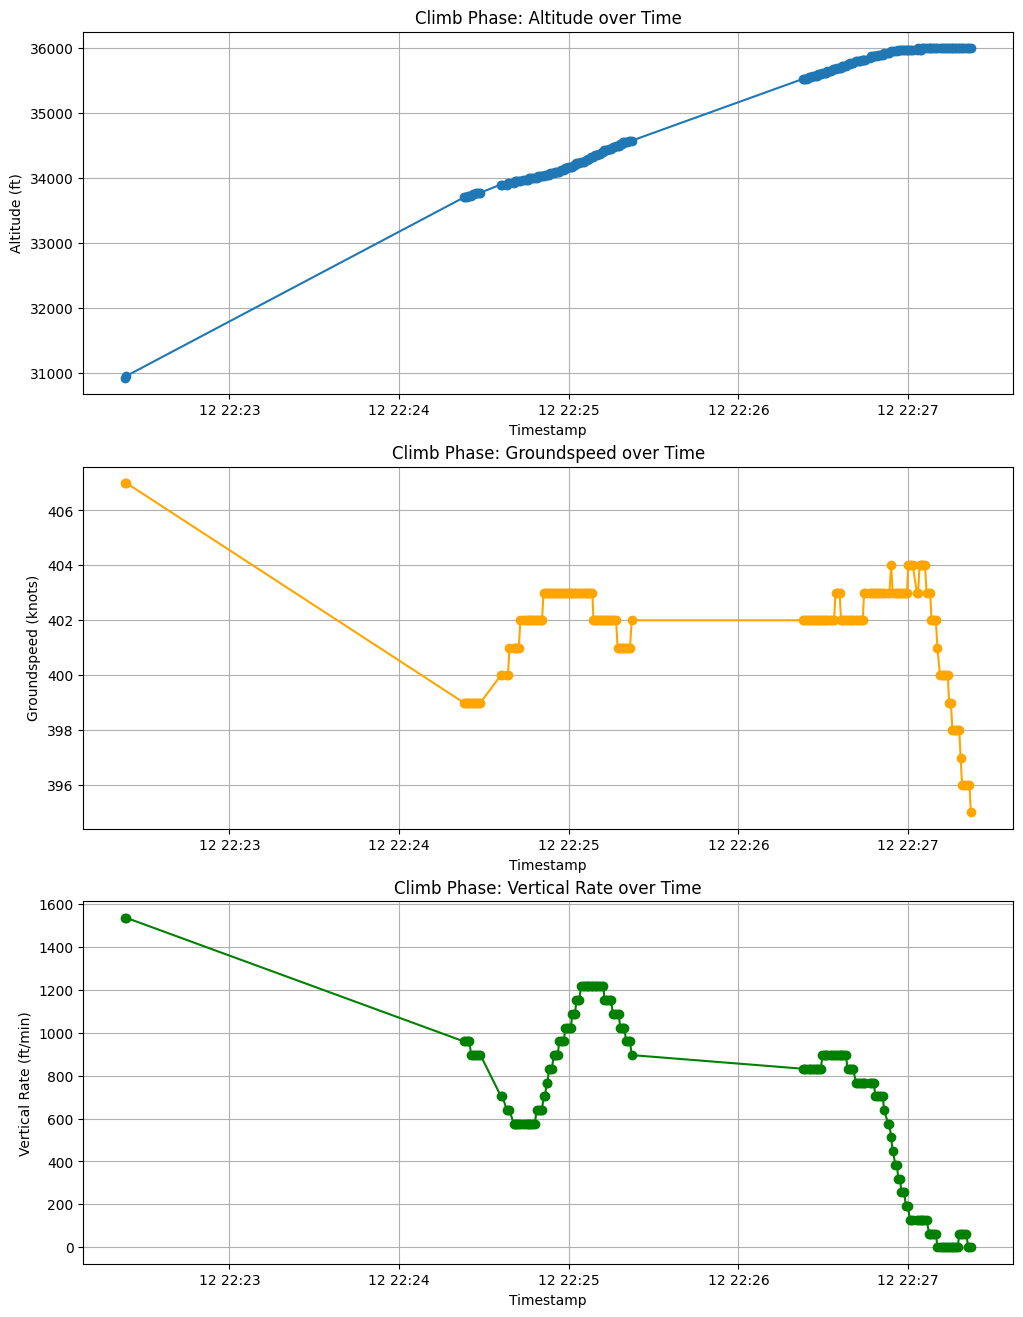

In [20]:
# Display plots of altitude, groundspeed, vertical_rate over time for the climb phase
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 16))  # Height doubled from 8 to 16

plt.subplot(3, 1, 1)
plt.plot(climb_phase_df['timestamp'], climb_phase_df['altitude'], marker='o')
plt.title('Climb Phase: Altitude over Time')
plt.xlabel('Timestamp')
plt.ylabel('Altitude (ft)')
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(climb_phase_df['timestamp'], climb_phase_df['groundspeed'], marker='o', color='orange')
plt.title('Climb Phase: Groundspeed over Time')
plt.xlabel('Timestamp')
plt.ylabel('Groundspeed (knots)')
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(climb_phase_df['timestamp'], climb_phase_df['vertical_rate'], marker='o', color='green')
plt.title('Climb Phase: Vertical Rate over Time')
plt.xlabel('Timestamp')
plt.ylabel('Vertical Rate (ft/min)')
plt.grid()

In [21]:
# Convert timestamp to datetime
climb_phase_df['timestamp'] = pd.to_datetime(climb_phase_df['timestamp'], utc=True)

In [22]:
# Convert flight data to traffic Flight object
from traffic.core import Traffic

flight = Traffic(climb_phase_df)[0]
dict(flight)

{'flight_id': 'prc770882767',
 'icao24': None,
 'aircraft': None,
 'start': Timestamp('2025-04-12 22:22:23.206000090+0000', tz='UTC'),
 'stop': Timestamp('2025-04-12 22:27:22.201999903+0000', tz='UTC'),
 'duration': Timedelta('0 days 00:04:58.995999813')}

In [23]:
# Filter data
flight_filtered = flight.filter("aggressive")

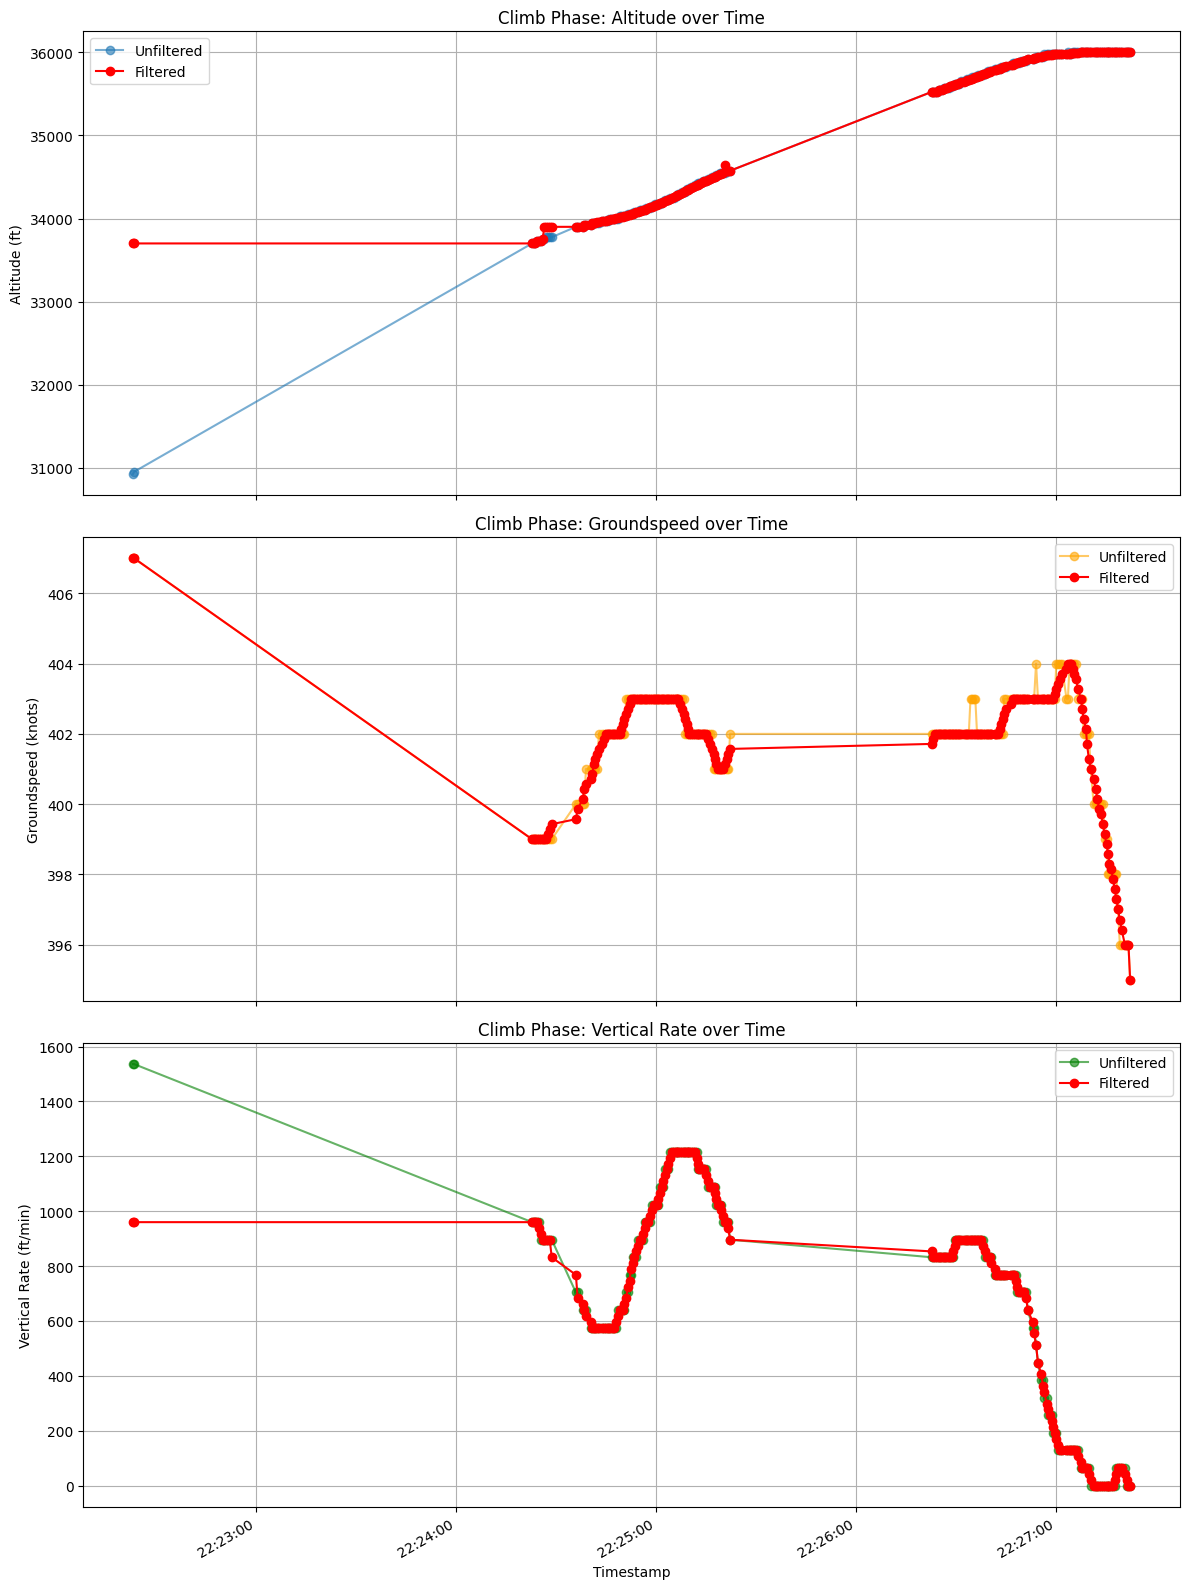

In [24]:
# Plot filtered vs unfiltered altitude
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter, AutoDateLocator

# Prepare dataframes
df_raw = climb_phase_df.copy()
df_filt = pd.DataFrame(flight_filtered.data).copy()
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_filt['timestamp'] = pd.to_datetime(df_filt['timestamp'])
df_raw = df_raw.sort_values('timestamp').reset_index(drop=True)
df_filt = df_filt.sort_values('timestamp').reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharex=True)
locator = AutoDateLocator()
fmt = DateFormatter("%H:%M:%S")

# Altitude
axes[0].plot(df_raw['timestamp'], df_raw['altitude'], marker='o', label='Unfiltered', alpha=0.6)
if 'altitude' in df_filt.columns:
    axes[0].plot(df_filt['timestamp'], df_filt['altitude'], marker='o', color='red', label='Filtered')
axes[0].set_title('Climb Phase: Altitude over Time')
axes[0].set_ylabel('Altitude (ft)')
axes[0].legend()
axes[0].grid()

# Groundspeed
axes[1].plot(df_raw['timestamp'], df_raw['groundspeed'], marker='o', color='orange', label='Unfiltered', alpha=0.6)
if 'groundspeed' in df_filt.columns:
    axes[1].plot(df_filt['timestamp'], df_filt['groundspeed'], marker='o', color='red', label='Filtered')
axes[1].set_title('Climb Phase: Groundspeed over Time')
axes[1].set_ylabel('Groundspeed (knots)')
axes[1].legend()
axes[1].grid()

# Vertical Rate
axes[2].plot(df_raw['timestamp'], df_raw['vertical_rate'], marker='o', color='green', label='Unfiltered', alpha=0.6)
if 'vertical_rate' in df_filt.columns:
    axes[2].plot(df_filt['timestamp'], df_filt['vertical_rate'], marker='o', color='red', label='Filtered')
axes[2].set_title('Climb Phase: Vertical Rate over Time')
axes[2].set_xlabel('Timestamp')
axes[2].set_ylabel('Vertical Rate (ft/min)')
axes[2].legend()
axes[2].grid()

axes[2].xaxis.set_major_locator(locator)
axes[2].xaxis.set_major_formatter(fmt)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

#### Calculate aircraft mass using point-mass model

In [4]:
# Load the united flight segment statistics with phases dataframe
united_with_phases = pd.read_parquet('dataset/flight_segment_stats_united_with_phases.parquet')

In [5]:
# Shape of the dataframe
united_with_phases.shape

(131530, 28)

In [ ]:
# We will use total energy model to estimate aircraft mass during climb and descend phases
# (Thrust-Drag)/m * tas - energy_rate = 0
# where energy_rate = 0.5 * d(tas ** 2) / dt + g_0 * dalt * tau / dt = tas * vertical_rate + g_0 * altitude_rate

In [27]:
# Use OpenAP library to get necessary aerodynamic data
# Find out support for aircraft types in the dataset
from openap import prop
avaiable_aircraft = prop.available_aircraft()

print(f"Supports {len(avaiable_aircraft)} aircraft types")
print(avaiable_aircraft)

Supports 37 aircraft types
['a19n', 'a20n', 'a21n', 'a318', 'a319', 'a320', 'a321', 'a332', 'a333', 'a343', 'a359', 'a388', 'b37m', 'b38m', 'b39m', 'b3xm', 'b734', 'b737', 'b738', 'b739', 'b744', 'b748', 'b752', 'b763', 'b772', 'b773', 'b77w', 'b788', 'b789', 'c550', 'crj9', 'e145', 'e170', 'e190', 'e195', 'e75l', 'glf6']


In [28]:
# Example calculation for one climb phase
climb_phase_df = pd.read_parquet('dataset/phases/prc770882767_219_climb.parquet')

In [29]:
# Display the shape of the climb phase dataframe
climb_phase_df.shape

(211, 14)

In [30]:
# Find aircraft type from climb_phase_df
ac = climb_phase_df['typecode'].iloc[0].lower()
print(f"Aircraft type in climb phase: {ac}")

Aircraft type in climb phase: a20n


In [31]:
ac_data = prop.aircraft(ac)
print(ac_data)

{'aircraft': 'Airbus A320neo', 'mtow': 79000, 'mlw': 66000, 'oew': 44300, 'mfc': 29700, 'vmo': 350, 'mmo': 0.82, 'ceiling': 12500, 'pax': {'max': 194, 'low': 150, 'high': 180}, 'fuselage': {'length': 37.57, 'height': 4.14, 'width': 3.95}, 'wing': {'area': 124, 'span': 35.8, 'mac': 4.29, 'sweep': 25, 't/c': None}, 'flaps': {'type': 'single-slotted', 'area': 21.1, 'bf/b': 0.78, 'lambda_f': 0.9, 'cf/c': 0.176, 'Sf/S': 0.17}, 'cruise': {'height': 11000, 'mach': 0.78, 'range': 6300}, 'engine': {'type': 'turbofan', 'mount': 'wing', 'number': 2, 'default': 'PW1127G-JM', 'options': {'A320-271N': 'PW1127G-JM', 'A320-272N': 'PW1124G1-JM', 'A320-273N': 'PW1129G-JM', 'A320-251N': 'LEAP-1A26', 'A320-252N': 'LEAP-1A24', 'A320-253N': 'LEAP-1A29'}}, 'drag': {'cd0': 0.017, 'k': 0.038, 'e': 0.807, 'gears': 0.017}, 'fuel': {'aircraft': 'Airbus A320', 'engine': 'CFM56-5B4/P', 'fuel_coef': 2.65942225}, 'limits': {'MTOW': 79000, 'MLW': 66000, 'OEW': 44300, 'MFC': 29700, 'VMO': 350, 'MMO': 0.82, 'ceiling': 1

In [6]:
# Compute drag coefficients
# The model D = c_0 + c_2 * m^2 splits total drag D into a mass-independent term c_0 (parasite / zero-lift drag) and a term that scales with mass^2 (induced drag).
# Rearranging for c_2 from one measurement gives c_2 = (D - c_0) / m**2. If you have D at m=0 then D(0)=c_0, otherwise estimate c_0 from a fit.

from openap import drag
from typing import Tuple
from numpy.typing import ArrayLike

def compute_c0_c1(ac: str, tas: ArrayLike, alt_ft: ArrayLike, mass2: float = 10000.0) -> Tuple[np.ndarray, np.ndarray]:
    """
    Vectorized: Compute c_0 and c_1 for D = c_0 + c_1 * m**2 for arrays of tas and alt_ft.
    Args:
        ac: aircraft type string (as accepted by openap.drag.Drag)
        tas: np.ndarray of True Air Speed in knots
        alt_ft: np.ndarray of altitude in feet
        mass2: second mass point in kg (default 10000)
    Returns:
        c0, c1: arrays of same shape as tas/alt_ft
    """
    dmodel = drag.Drag(ac)
    tas = np.asarray(tas)
    alt_ft = np.asarray(alt_ft)
    c0 = np.empty_like(tas, dtype=float)
    c1 = np.empty_like(tas, dtype=float)
    # The drag.clean() function estimates the drag force when the aircraft is at the clean configuration, which means no flaps or landing gear are deployed.
    for idx, _ in np.ndenumerate(tas):
        t = tas[idx]
        a = alt_ft[idx]
        D0 = float(dmodel.clean(alt=a, tas=t, mass=0))
        Dm = float(dmodel.clean(alt=a, tas=t, mass=mass2))
        c0[idx] = D0
        c1[idx] = (Dm - D0) / (mass2 ** 2)
    return c0, c1

In [56]:
# Compute thrust
from openap import thrust
from numpy.typing import ArrayLike
from typing import Union, Optional
from openap import thrust

def compute_thrust(
    phase_flag: Union[str, ArrayLike],
    ac: str,
    tas: ArrayLike,
    alt_ft: ArrayLike,
    roc: Optional[ArrayLike] = None
) -> np.ndarray:
    """
    Vectorized: Compute thrust for climb or descent.
    Args:
        hase_flag: Phase label(s). Allowed values: `CL` (climb), `DE` (descent), `CR` (cruise).
        ac: aircraft type string
        tas: np.ndarray of True Air Speed in knots
        alt_ft: np.ndarray of altitude in feet
        roc: np.ndarray of rate of climb in ft/min
    Returns:
        thrust: np.ndarray of thrust values in Newtons (N)
    """
    tmodel = thrust.Thrust(ac)
    tas = np.asarray(tas, dtype=float)
    alt_ft = np.asarray(alt_ft, dtype=float)
    if tas.shape != alt_ft.shape:
        raise ValueError("tas and alt_ft must have the same shape")
    n = tas.size
    # Prepare roc array
    if roc is None:
        roc_arr = np.zeros(n, dtype=float)
    else:
        roc_arr = np.asarray(roc, dtype=float)
        if roc_arr.shape != tas.shape:
            raise ValueError("roc must be None or have same shape as tas/alt_ft")
    # Normalize phase_flag to array of strings
    phase_arr = np.asarray(phase_flag, dtype=object)
    if phase_arr.ndim == 0:
        phase_arr = np.full(n, str(phase_arr).upper(), dtype=object)
    else:
        if phase_arr.shape != tas.shape:
            # allow 1D array matching length
            if phase_arr.size == n:
                phase_arr = phase_arr.astype(object)
            else:
                raise ValueError("phase_flag must be scalar or array-like with same length as tas")
    # Validate and uppercase values
    def _norm(ph):
        if ph is None:
            raise ValueError("phase_flag contains None")
        s = str(ph).strip().upper()
        if s not in ("CL", "DE", "CR"):
            raise ValueError(f"Unsupported phase flag: {ph!r}. Allowed: 'CL','DE','CR'")
        return s
    phase_arr = np.vectorize(_norm)(phase_arr)
    thr = np.empty(n, dtype=float)
    for i in range(n):
        ph = phase_arr[i]
        if ph == "CL":
            thr[i] = tmodel.climb(tas=tas[i], alt=alt_ft[i], roc=roc_arr[i])
        elif ph == "DE":
            thr[i] = tmodel.descend(tas=tas[i], alt=alt_ft[i], roc=roc_arr[i])
        else:  # "CR"
            thr[i] = tmodel.cruise(tas=tas[i], alt=alt_ft[i])

    return thr

In [8]:
# The energy rate is calculated as the change in potential and kinetic energy per unit time
# e =  0.5 * d(tas ** 2) / dt + g_0 * dalt * tau / dt

from pitot import isa
from numpy.typing import ArrayLike

def energy_rate(alt_ft: ArrayLike, tas_kts: ArrayLike, timestamp: ArrayLike) -> np.ndarray:
    """
    Computes energy rate per unit mass for a trajectory.

    Args:
        alt_ft (array-like): Altitude values in feet.
        tas_kts (array-like): True Air Speed in knots.
        timestamp (array-like): Timestamps corresponding to samples (pandas/datetime64-like).

    Returns:
        numpy.ndarray: Energy rate in W/kg (J/s per kg) for each sample. Entries with zero dt are np.nan.
    """
    alt_ft = np.asarray(alt_ft, dtype=float)
    tas_kts = np.asarray(tas_kts, dtype=float)
    timestamp = np.asarray(timestamp)
    # Unit conversions
    alt_m = alt_ft * 0.3048           # feet -> meters
    tas_ms = tas_kts * 0.514444       # knots -> m/s
    g_0 = 9.80665   # Standard gravity in m/s^2
    # Use ISA temperature at altitude in meters (if needed)
    tempISA = isa.temperature(alt_m)
    # tau = temperature / tempISA (not available here) -> assume 1
    tau = 1.0
    # Differences
    dalt = np.diff(alt_m, prepend=alt_m[0])            # meters
    tas2 = tas_ms ** 2                                 # (m/s)^2
    dtas2 = np.diff(tas2, prepend=tas2[0])             # (m/s)^2 differences
    # Replace 'datetime64[s]' with 'datetime64[ms]' for higher resolution, to avoid zero dt
    dt = np.diff(timestamp.astype('datetime64[ms]').astype(float), prepend=timestamp[0].astype('datetime64[ms]').astype(float))
    # Avoid division by zero
    dt[dt == 0] = np.nan
    # energy rate per unit mass: (g0 * dalt * tau + 0.5 * d(tas^2)) / dt
    e = (g_0 * dalt * tau + 0.5 * dtas2) / dt

    return e

In [70]:
# To estimate mass at each point using the energy balance equation, we need to:
#
# 1. Compute drag at two mass points using compute_c0_c1 (which gives c_0 and c_1 for D = c_0 + c_1 m^2).
# 2. Compute thrust at each point using compute_thrust.
# 3. Compute energy rate using energy_rate function.
# 4. Formulate the quadratic equation in mass: (Thrust - (c0 + c1 * m^2)) * TAS / m - energy_rate = 0
#    Rearranged: -c1 * TAS * m^2 - energy_rate * m + (Thrust - c0) = 0
#    This is a quadratic in m: (a * m^2 + b * m + c = 0)
# 5. Solve for mass at each point (take the physically meaningful root).

In [9]:
# Function to solve quadratic equation for mass
from scipy.optimize import minimize_scalar

def estimate_mass_least_squares(a, b, c, mass_bounds=(1000.0, 200000.0), tol=1e-3):
    """
    Estimate a single mass (kg) minimizing sum((a_i*m^2 + b_i*m + c_i)^2) over all samples,
    ignoring samples where a, b, or c are NaN.

    Args:
        a, b, c: array-like coefficients for each sample (same length).
        mass_bounds: (min_mass, max_mass) search interval in kg.
        tol: minimization tolerance. Lower tol means higher precision but possibly longer computation.

    Returns:
        Estimated mass (float, kg). Returns np.nan if input invalid or all values are NaN.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    c = np.asarray(c, dtype=float)
    mask = ~(np.isnan(a) | np.isnan(b) | np.isnan(c))
    if not np.any(mask):
        return np.nan
    a, b, c = a[mask], b[mask], c[mask]
    if a.size == 0:
        return np.nan
    def obj(m):
        r = a * m**2 + b * m + c
        return np.sum(r**2)
    res = minimize_scalar(obj, bounds=mass_bounds, method='bounded', options={'xatol': tol})
    return float(res.x) if res.success else np.nan

In [10]:
# Main function to estimate mass from climb phase dataframe

def estimate_mass_from_energy_balance(trajectory_df, ac: str, is_climb: bool = True) -> np.ndarray:
    """
    Estimate aircraft mass per sample by solving the point-mass energy-balance quadratic:
        (Thrust - Drag)/m * TAS - energy_rate = 0
    Rearranged to a*m^2 + b*m + c = 0 with:
        a = -c1 * TAS_m_s
        b = -energy_rate        (units: J/s per kg \= W/kg)
        c = Thrust - c0         (units: N)

    Args:
        trajectory_df (pandas.DataFrame or similar): Table containing at least the following columns:
            - `TAS` : True Air Speed in knots
            - `altitude` : Altitude in feet
            - `vertical_rate` : Vertical rate in ft/min
            - `timestamp` : Timestamp (pandas datetime / numpy datetime64). Timezone-aware or UTC recommended.
        ac (str): Aircraft type string accepted by the `openap` helpers used elsewhere (e.g. `compute_c0_c1`, `compute_thrust`).
        is_climb (bool, optional): If True, compute climb thrust; if False, use descent/idle thrust. Default True.

    Returns:
        numpy.ndarray:
            1-D array of estimated masses in kilograms (kg), shaped to match the number of input samples.
            Elements where a physically meaningful positive root cannot be found (no real positive root,
            invalid inputs, zero\-/NaN time deltas, etc.) are set to `np.nan`.
    """
    # Validate input type and required columns
    if trajectory_df is None:
        raise ValueError("`trajectory_df` must be provided")
    df = pd.DataFrame(trajectory_df).copy()
    required = {'TAS', 'altitude', 'vertical_rate', 'timestamp'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in trajectory_df: {sorted(missing)}")
    # Extract arrays and normalize types
    tas = np.asarray(df['TAS'].values, dtype=float)               # knots
    alt_ft = np.asarray(df['altitude'].values, dtype=float)      # feet
    roc = np.asarray(df['vertical_rate'].values, dtype=float)    # ft/min
    timestamp = np.asarray(pd.to_datetime(df['timestamp'], utc=True).values)  # datetime64[ns, UTC]
    # Compute model components (these helper functions are assumed available in module)
    c0, c1 = compute_c0_c1(ac, tas, alt_ft)
    phase_flag = 'CL' if is_climb else 'DE'
    thr = compute_thrust(phase_flag, ac, tas, alt_ft, roc)  # N
    e_rate = energy_rate(alt_ft, tas, timestamp)                  # W/kg (J/s per kg)
    # Convert TAS to m/s for coefficient `a`
    KTS2MS = 0.514444
    tas_ms = tas * KTS2MS
    # Build quadratic coefficients and ensure broadcasting to same shape
    a = -np.asarray(c1, dtype=float) * np.asarray(tas_ms, dtype=float)
    b = -np.asarray(e_rate, dtype=float)
    c = np.asarray(thr, dtype=float) - np.asarray(c0, dtype=float)
    # Broadcast to common shape
    a_b, b_b, c_b = np.broadcast_arrays(a, b, c)
    # Solve quadratic per-sample using existing solver
    mass = estimate_mass_least_squares(a=a_b, b=b_b, c=c_b)  # expected output in kg or np.nan
    # Ensure result is 1-D with same length as input rows
    mass = np.asarray(mass).reshape(-1)[:len(df)]
    
    return mass

In [11]:
# Function to filter climb phase dataframe using traffic library
# python
from traffic.core import Traffic

def filter_trajectory(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert `timestamp` to UTC datetime, apply the Traffic('aggressive') filter, and return the filtered DataFrame.

    Args:
        df (pandas.DataFrame): Input trajectory with at least a `timestamp` column.  
            Recommended columns for meaningful filtering: `latitude`, `longitude`, `altitude`, `groundspeed`, etc.

    Returns:
        pandas.DataFrame: Filtered trajectory rows. If filtering yields rows, `timestamp` is timezone-aware UTC and rows
        are sorted by `timestamp`. If filtering produces no usable `timestamp`, returns an empty DataFrame with the same
        columns as the input.
    """
    if df is None:
        raise ValueError("`df` must be provided")
    if 'timestamp' not in df.columns:
        raise ValueError("Input DataFrame must contain a `timestamp` column")
    df_copy = df.copy()
    df_copy['timestamp'] = pd.to_datetime(df_copy['timestamp'], utc=True)
    # Build Traffic object and apply aggressive filter
    flight = Traffic(df_copy)[0]
    flight_filtered = flight.filter("aggressive")
    df_filt = pd.DataFrame(flight_filtered.data)
    # Ensure timestamp remains timezone-aware and sort; if missing, return empty frame with same columns
    if 'timestamp' in df_filt.columns and not df_filt.empty:
        df_filt['timestamp'] = pd.to_datetime(df_filt['timestamp'], utc=True)
        df_filt = df_filt.sort_values('timestamp').reset_index(drop=True)
    else:
        df_filt = pd.DataFrame(columns=df.columns)

    return df_filt

In [65]:
# Compute fuel flow using thrust-based model

from openap import FuelFlow

def calculate_fuel_flow(phase_df, phase_flag, ac_type):
    """
    Calculate fuel flow for a flight phase using thrust-based model.

    Args:
        phase_df : pandas.DataFrame
            DataFrame containing columns for TAS, vertical_rate, and altitude.
        phase_flag : str
            Flight phase flag: 'CL' (climb), 'DE' (descend), or 'CR' (cruise).
        ac_type : str
            Aircraft type designator.

    Returns:
        numpy.ndarray
            Array of fuel flow values (kg/s) for each row in `phase_df`.
    """
    # instantiate the FuelFlow model for the given aircraft type
    ff = FuelFlow(ac_type)
    tas_kts = phase_df['TAS']
    roc_ft_min = phase_df['vertical_rate']
    alt_ft = phase_df['altitude']
    thrust_values = compute_thrust(phase_flag, ac_type, tas_kts, alt_ft, roc_ft_min)       
    result = []
        
    return ff.at_thrust(thrust_values)

In [22]:
# Example: Estimate mass for all points in climb_phase_df
climb_phase_file = 'dataset/phases/prc770882767_219_climb.parquet'  # Replace with an actual file name
climb_phase_df = pd.read_parquet(climb_phase_file)
climb_phase_df = filter_trajectory(climb_phase_df)

In [23]:
# Simplified function to fill TAS column using GRIB data
def fill_tas_column_simplified(group_sorted, grib_df):
    """
    Fill the TAS (True Airspeed) column for a sorted group DataFrame.
    Calculates TAS from groundspeed, track, and wind (u, v) only.
    """
    required = ['TAS', 'groundspeed', 'track', 'latitude', 'longitude', 'altitude', 'timestamp']
    for col in required:
        if col not in group_sorted.columns:
            group_sorted[col] = np.nan
    tas_vals = group_sorted['TAS'].copy()
    needs_weather = tas_vals.isna() & (
        group_sorted['groundspeed'].notna() & group_sorted['track'].notna()
    )
    if needs_weather.any():
        weather_rows = group_sorted[needs_weather]
        for idx, row in weather_rows.iterrows():
            u, v, _ = get_profile_at_alt(grib_df, row['latitude'], row['longitude'],
                                         row['altitude'], row['timestamp'])
            if pd.notna(u) and pd.notna(v) and pd.notna(row['groundspeed']) and pd.notna(row['track']):
                tas_vals[idx] = calculate_tas(row['groundspeed'], row['track'], u, v)
    group_sorted['TAS'] = tas_vals
    return group_sorted

In [24]:
# Fill TAS column using GRIB data
climb_phase_df = climb_phase_df.sort_values('timestamp').reset_index(drop=True)
flight_id = climb_phase_df['flight_id'].iloc[0]

import xarray as xr
grib_file_path = f'dataset/ERA5/CDS_data_{flight_id}.grib'
grib_file = xr.open_dataset(grib_file_path, engine='cfgrib')
climb_phase_df = fill_tas_column_simplified(climb_phase_df, grib_file)

In [25]:
# Filter rows with missing any of 'TAS', 'altitude', 'vertical_rate','timestamp'
climb_phase_df = climb_phase_df.dropna(subset=['TAS', 'altitude', 'vertical_rate', 'timestamp'])

In [26]:
# If there is duplicated timestamps, keep the first occurrence
climb_phase_df = climb_phase_df.drop_duplicates(subset=['timestamp'])

In [58]:
ac = climb_phase_df['typecode'].iloc[0].lower()
is_climb = climb_phase_df['phase'].iloc[0] == 'CL'
estimated_mass = estimate_mass_from_energy_balance(climb_phase_df, ac, is_climb=True)
print(f"Estimated mass (kg) for climb/descend phase: {estimated_mass}")

Estimated mass (kg) for climb/descend phase: [6663.83333894]


In [67]:
# Calculate mean fuel flow for the climb phase
fuel_flow = np.nanmean(calculate_fuel_flow(climb_phase_df, 'CL', ac))
print(f"Fuel flow (kg/s) for climb phase: {fuel_flow}")

Fuel flow (kg/s) for climb phase: 0.6529225416890602


In [69]:
# How many non nan values united_with_phases has in path columns
num_climb_paths = (united_with_phases['climb_phase_path'].astype(str).str.len() > 0).sum()
num_descend_paths = (united_with_phases['descend_phase_path'].astype(str).str.len() > 0).sum()
num_cruise_paths = (united_with_phases['cruise_phase_path'].astype(str).str.len() > 0).sum()
print(f"Number of climb phase paths: {num_climb_paths}")
print(f"Number of descend phase paths: {num_descend_paths}")
print(f"Number of cruise phase paths: {num_cruise_paths}")

Number of climb phase paths: 3036
Number of descend phase paths: 4517
Number of cruise phase paths: 24393


In [70]:
# For every file in phases directory find out how many rows are there, then give min, max and mean rows number
phase_files = os.listdir('dataset/phases')
row_counts = []
for file in phase_files:
    if file.endswith('.parquet'):
        df = pd.read_parquet(os.path.join('dataset/phases', file))
        row_counts.append(len(df))
row_counts = np.array(row_counts)
print(f"Min rows in phase files: {row_counts.min()}")
print(f"Max rows in phase files: {row_counts.max()}")
print(f"Mean rows in phase files: {row_counts.mean():.2f}")

Min rows in phase files: 5
Max rows in phase files: 3298
Mean rows in phase files: 173.29


In [72]:
# Calculate estimated mass for all climb and descend phases in united_with_phases dataframe
from tqdm.notebook import tqdm
from multiprocessor_e import run_mass_estimation
result_df = run_mass_estimation(united_with_phases, num_workers=10, resample_n=100, era5_dir='dataset/ERA5')

Processing files:   0%|          | 0/131530 [00:00<?, ?it/s]

Exception in thread Thread-6:
Traceback (most recent call last):
  File "C:\Program Files\Python310\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "D:\PYCHARM_PROJEKTI\PRCdc2025\venv\lib\site-packages\tqdm\_monitor.py", line 84, in run
    instance.refresh(nolock=True)
  File "D:\PYCHARM_PROJEKTI\PRCdc2025\venv\lib\site-packages\tqdm\std.py", line 1347, in refresh
    self.display()
  File "D:\PYCHARM_PROJEKTI\PRCdc2025\venv\lib\site-packages\tqdm\notebook.py", line 171, in display
    rtext.value = right
  File "D:\PYCHARM_PROJEKTI\PRCdc2025\venv\lib\site-packages\traitlets\traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "D:\PYCHARM_PROJEKTI\PRCdc2025\venv\lib\site-packages\traitlets\traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "D:\PYCHARM_PROJEKTI\PRCdc2025\venv\lib\site-packages\traitlets\traitlets.py", line 1513, in _notify_trait
    self.notify_change(
  File "D:\PYCHARM_PROJEKTI\PRCdc202

In [78]:
# Show first 20 rows of the result dataframe
result_df.head(20)

,flight_id,segment_idx,typecode,start,end,since_takeoff,until_landed,segment_duration,altitude_mean,altitude_std,groundspeed_mean,groundspeed_std,vertical_rate_mean,vertical_rate_std,TAS_mean,TAS_std,latitude_mean,longitude_mean,haversine_distance,3d_distance,source,fuel_flow_CR,fuel_flow_DE,estimated_mass_descend,estimated_mass_climb,fuel_flow_CL,fuel_kg
0,prc770822360,0,B789,2025-04-13 02:31:04.447,2025-04-13 03:01:04.487,36929.447,7367.553,1800.040,35988.585001,12.445445,472.013723,4.054457,-3.360382,46.372524,487.721438,NaN,46.238055,21.882323,435407.275101,440999.825796,acars+adsb,NaN,NaN,NaN,NaN,NaN,2500.000000
1,prc770822360,1,B789,2025-04-13 03:01:04.487,2025-04-13 03:16:04.226,38729.487,5567.513,899.739,35989.290344,12.361191,484.703549,7.434831,-29.862213,36.801336,489.704554,NaN,47.722071,18.225386,222144.612901,222558.727051,acars+adsb,NaN,NaN,NaN,NaN,NaN,1200.000000
2,prc770822360,2,B789,2025-04-13 03:16:04.458,2025-04-13 03:46:04.417,39629.458,4667.542,1799.959,35988.990605,12.400906,511.885794,9.377808,-36.040854,43.789453,505.671390,NaN,49.482053,14.337235,471569.291518,471945.693489,acars+adsb,NaN,NaN,NaN,NaN,NaN,2500.000000
3,prc770822360,3,B789,2025-04-13 03:46:04.417,2025-04-13 04:01:04.540,41429.417,2867.583,900.123,35988.474983,13.181923,506.388982,4.106634,-34.457429,64.974600,497.389974,NaN,51.243231,10.164220,233211.048224,233728.018039,acars+adsb,NaN,NaN,NaN,NaN,NaN,1300.000000
4,prc770822360,4,B789,2025-04-13 04:01:04.540,2025-04-13 04:16:04.263,42329.540,1967.460,899.723,29491.527367,7484.109707,467.748289,32.123663,-1531.863118,1170.475897,470.630144,NaN,52.071832,7.275563,215976.174600,216241.417638,acars+adsb,2.593195,NaN,NaN,NaN,NaN,600.000000
5,prc770831136,5,A359,2025-04-12 21:30:33.782,2025-04-12 21:58:39.507,17392.782,20381.218,1685.725,37006.000000,0.000000,NaN,NaN,NaN,NaN,278.000000,NaN,2.435000,152.725000,414464.974338,414464.974338,acars,NaN,NaN,NaN,NaN,NaN,3049.952608
6,prc770831136,6,A359,2025-04-12 21:58:39.507,2025-04-12 22:02:40.552,19078.507,18695.493,241.045,37006.000000,0.000000,NaN,NaN,NaN,NaN,278.500000,NaN,0.610000,153.830000,59879.339649,59879.339649,acars,NaN,NaN,NaN,NaN,NaN,355.162536
7,prc770831136,7,A359,2025-04-12 22:02:40.552,2025-04-12 22:22:44.881,19319.552,18454.448,1204.329,37004.000000,2.828427,NaN,NaN,NaN,NaN,278.000000,NaN,-0.745000,154.650000,292329.527309,292329.527312,acars,NaN,NaN,NaN,NaN,NaN,1930.941144
8,prc770831136,8,A359,2025-04-12 22:22:44.881,2025-04-12 22:38:54.572,20523.881,17250.119,969.691,37001.500000,0.707107,NaN,NaN,NaN,NaN,275.500000,NaN,-2.785000,155.850000,233981.554997,233981.554998,acars,NaN,NaN,NaN,NaN,NaN,1607.076456
9,prc770831136,9,A359,2025-04-12 22:38:54.572,2025-04-12 22:42:48.575,21493.572,16280.428,234.003,37002.000000,1.414214,NaN,NaN,NaN,NaN,274.000000,NaN,-3.920000,156.510000,57953.063618,57953.063621,acars,NaN,NaN,NaN,NaN,NaN,370.131072


In [75]:
# How many rows have estimated mass not null
mask = result_df['estimated_mass_descend'].notna() | result_df['estimated_mass_climb'].notna()
num_segments_with_mass = mask.sum()
total_segments = len(result_df)
print(f"Segments with estimated mass: {num_segments_with_mass} out of {total_segments}")

Segments with estimated mass: 2952 out of 131530


In [161]:
# Rearrange columns
# Define the desired order for the last columns
last_cols = ['estimated_mass_climb', 'estimated_mass_descend', 'fuel_flow_CL', 'fuel_flow_DE', 'fuel_flow_CR', 'fuel_kg']
# Get the remaining columns (all except the last ones)
remaining_cols = [col for col in result_df.columns if col not in last_cols]
# Reorder the DataFrame
result_df = result_df[remaining_cols + last_cols]

In [162]:
# Save the result dataframe to a parquet file
result_df.to_parquet('dataset/flight_segment_stats_united_with_estimated_mass.parquet', index=False)

In [163]:
# Save as csv
result_df.to_csv('dataset/flight_segment_stats_united_with_estimated_mass.csv', index=False)

#### Merge flight, airport and aircraft data

In [167]:
# Load result dataframe
result_df = pd.read_parquet('dataset/flight_segment_stats_united_with_estimated_mass.parquet')

In [168]:
# Load flights, airports and aircraft datasets
flights = pd.read_parquet('dataset/flightlist_train.parquet')
airports = pd.read_parquet('dataset/apt.parquet')
aircraft_df = pd.read_csv('dataset/aircraft_data.csv')

In [169]:
# Take result_df, remove 'source' column. Then merge with flights dataset to get flight_date, takeoff, landed, origin_icao, destination_icao using 'flight_id'
final_df = result_df.drop(columns=['source','typecode']).merge(
    flights[['flight_id', 'flight_date', 'takeoff', 'landed', 'origin_icao', 'destination_icao', 'aircraft_type']],
    on='flight_id',
    how='left'
)
# Rearrange columns to have flight information first and 'fuel_kg' last
cols = ['flight_id', 'flight_date', 'takeoff', 'landed', 'origin_icao', 'destination_icao', 'aircraft_type'] + \
       [c for c in final_df.columns if c not in ['flight_id', 'flight_date', 'takeoff', 'landed', 'origin_icao', 'destination_icao', 'aircraft_type', 'fuel_kg']] + ['fuel_kg']

final_df = final_df[cols]

In [170]:
# Show first 20 rows of the final dataframe
final_df.head(20)

,flight_id,flight_date,takeoff,landed,origin_icao,destination_icao,aircraft_type,segment_idx,start,end,since_takeoff,until_landed,segment_duration,altitude_mean,altitude_std,groundspeed_mean,groundspeed_std,vertical_rate_mean,vertical_rate_std,TAS_mean,TAS_std,latitude_mean,longitude_mean,haversine_distance,3d_distance,estimated_mass_climb,estimated_mass_descend,fuel_flow_CL,fuel_flow_DE,fuel_flow_CR,fuel_kg
0,prc770822360,2025-04-12,2025-04-12 16:15:35,2025-04-13 04:33:52,WMKK,EHAM,B789,0,2025-04-13 02:31:04.447,2025-04-13 03:01:04.487,36929.447,7367.553,1800.040,35988.585001,12.445445,472.013723,4.054457,-3.360382,46.372524,487.721438,NaN,46.238055,21.882323,435407.275101,440999.825796,None,NaN,NaN,NaN,NaN,2500.000000
1,prc770822360,2025-04-12,2025-04-12 16:15:35,2025-04-13 04:33:52,WMKK,EHAM,B789,1,2025-04-13 03:01:04.487,2025-04-13 03:16:04.226,38729.487,5567.513,899.739,35989.290344,12.361191,484.703549,7.434831,-29.862213,36.801336,489.704554,NaN,47.722071,18.225386,222144.612901,222558.727051,None,NaN,NaN,NaN,NaN,1200.000000
2,prc770822360,2025-04-12,2025-04-12 16:15:35,2025-04-13 04:33:52,WMKK,EHAM,B789,2,2025-04-13 03:16:04.458,2025-04-13 03:46:04.417,39629.458,4667.542,1799.959,35988.990605,12.400906,511.885794,9.377808,-36.040854,43.789453,505.671390,NaN,49.482053,14.337235,471569.291518,471945.693489,None,NaN,NaN,NaN,NaN,2500.000000
3,prc770822360,2025-04-12,2025-04-12 16:15:35,2025-04-13 04:33:52,WMKK,EHAM,B789,3,2025-04-13 03:46:04.417,2025-04-13 04:01:04.540,41429.417,2867.583,900.123,35988.474983,13.181923,506.388982,4.106634,-34.457429,64.974600,497.389974,NaN,51.243231,10.164220,233211.048224,233728.018039,None,NaN,NaN,NaN,NaN,1300.000000
4,prc770822360,2025-04-12,2025-04-12 16:15:35,2025-04-13 04:33:52,WMKK,EHAM,B789,4,2025-04-13 04:01:04.540,2025-04-13 04:16:04.263,42329.540,1967.460,899.723,29491.527367,7484.109707,467.748289,32.123663,-1531.863118,1170.475897,470.630144,NaN,52.071832,7.275563,215976.174600,216241.417638,None,NaN,NaN,NaN,2.593195,600.000000
5,prc770831136,2025-04-12,2025-04-12 16:40:41,2025-04-13 03:10:15,ZSPD,NZAA,A359,5,2025-04-12 21:30:33.782,2025-04-12 21:58:39.507,17392.782,20381.218,1685.725,37006.000000,0.000000,NaN,NaN,NaN,NaN,278.000000,NaN,2.435000,152.725000,414464.974338,414464.974338,None,NaN,NaN,NaN,NaN,3049.952608
6,prc770831136,2025-04-12,2025-04-12 16:40:41,2025-04-13 03:10:15,ZSPD,NZAA,A359,6,2025-04-12 21:58:39.507,2025-04-12 22:02:40.552,19078.507,18695.493,241.045,37006.000000,0.000000,NaN,NaN,NaN,NaN,278.500000,NaN,0.610000,153.830000,59879.339649,59879.339649,None,NaN,NaN,NaN,NaN,355.162536
7,prc770831136,2025-04-12,2025-04-12 16:40:41,2025-04-13 03:10:15,ZSPD,NZAA,A359,7,2025-04-12 22:02:40.552,2025-04-12 22:22:44.881,19319.552,18454.448,1204.329,37004.000000,2.828427,NaN,NaN,NaN,NaN,278.000000,NaN,-0.745000,154.650000,292329.527309,292329.527312,None,NaN,NaN,NaN,NaN,1930.941144
8,prc770831136,2025-04-12,2025-04-12 16:40:41,2025-04-13 03:10:15,ZSPD,NZAA,A359,8,2025-04-12 22:22:44.881,2025-04-12 22:38:54.572,20523.881,17250.119,969.691,37001.500000,0.707107,NaN,NaN,NaN,NaN,275.500000,NaN,-2.785000,155.850000,233981.554997,233981.554998,None,NaN,NaN,NaN,NaN,1607.076456
9,prc770831136,2025-04-12,2025-04-12 16:40:41,2025-04-13 03:10:15,ZSPD,NZAA,A359,9,2025-04-12 22:38:54.572,2025-04-12 22:42:48.575,21493.572,16280.428,234.003,37002.000000,1.414214,NaN,NaN,NaN,NaN,274.000000,NaN,-3.920000,156.510000,57953.063618,57953.063621,None,NaN,NaN,NaN,NaN,370.131072


In [171]:
# For every flight_id in final_df get origin and destination airport elevation from airports dataset
final_df = final_df.merge(
    airports[['icao', 'elevation']].rename(columns={'icao': 'origin_icao', 'elevation': 'origin_elevation'}),
    on='origin_icao',
    how='left'
).merge(
    airports[['icao', 'elevation']].rename(columns={'icao': 'destination_icao', 'elevation': 'destination_elevation'}),
    on='destination_icao',
    how='left'
)

In [172]:
# Put origin_elevation after origin_icao and destination_elevation after destination_icao
cols = final_df.columns.tolist()
cols.insert(cols.index('origin_icao') + 1, cols.pop(cols.index('origin_elevation')))
cols.insert(cols.index('destination_icao') + 1, cols.pop(cols.index('destination_elevation')))
final_df = final_df[cols]

In [173]:
# For every aircraft_type in final_df get aircraft data from aircraft_df
final_df = final_df.merge(
    aircraft_df[['ICAO_Code', 'Num_Engines', 'Wingspan_ft_without_winglets_sharklets', 'Wingspan_ft_with_winglets_sharklets', 'Length_ft', 'MTOW_lb', 'MALW_lb']].rename(columns={'ICAO_Code': 'aircraft_type'}),
    on='aircraft_type',
    how='left'
)

In [174]:
# Rearrange columns to have aircraft info after aircraft_type
aircraft_cols = [
    'Num_Engines',
    'Wingspan_ft_without_winglets_sharklets',
    'Wingspan_ft_with_winglets_sharklets',
    'Length_ft',
    'MTOW_lb',
    'MALW_lb'
]
cols = final_df.columns.tolist()
for i, col in enumerate(aircraft_cols, start=1):
    if col in cols:
        cols.insert(cols.index('aircraft_type') + i, cols.pop(cols.index(col)))
final_df = final_df[cols]

In [175]:
# Convert MTOW_lb and MALW_lb to kg (1 lb = 0.453592 kg), rename columns to MTOW_kg and MALW_kgpython
# Remove commas and convert to numeric
final_df['MTOW_lb'] = pd.to_numeric(final_df['MTOW_lb'].str.replace(',', ''), errors='coerce')
final_df['MALW_lb'] = pd.to_numeric(final_df['MALW_lb'].str.replace(',', ''), errors='coerce')
# Convert to kg in place
final_df['MTOW_lb'] = final_df['MTOW_lb'] * 0.453592
final_df['MALW_lb'] = final_df['MALW_lb'] * 0.453592
# Rename columns to kg
final_df = final_df.rename(columns={'MTOW_lb': 'MTOW_kg', 'MALW_lb': 'MALW_kg'})

In [176]:
# Save the final dataframe to a parquet file
final_df.to_parquet('dataset/final_flight_segments.parquet', index=False)

#### Merge meteorological data

In [177]:
# Load the final dataframe
final_df = pd.read_parquet('dataset/final_flight_segments.parquet')

In [178]:
# Function to enrich final_df with meteo data for origin and destination airports
# Explanation:
# For each flight, load the correct meteo file by takeoff date.
# Find the closest meteo station to the origin and destination airports using their coordinates.
# For each airport, find the meteo row with the closest timestamp to takeoff (origin) and landed (destination).
# Extract the required meteo columns, prefixing with origin_ and destination_, and add to final_df.

from typing import List, Optional, Tuple
from sklearn.neighbors import NearestNeighbors

meteo_cols = [
    'valid', 'tmpf', 'relh', 'drct', 'sknt', 'alti', 'mslp', 'gust',
    'ice_accretion_1hr', 'ice_accretion_3hr', 'ice_accretion_6hr',
    'peak_wind_gust', 'peak_wind_drct', 'peak_wind_time'
]

def get_station_coords(meteo_df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return unique meteorological station coordinates and station ids.

    Args:
        meteo_df: DataFrame containing at least columns `station`, `lat`, `lon`.

    Returns:
        coords: numpy array of shape (N, 2) with rows [lat, lon].
        stations: numpy array of station identifiers (N,).
    """
    required = {'station', 'lat', 'lon'}
    if not required.issubset(meteo_df.columns):
        raise ValueError(f"meteo_df must contain columns: {required}")
    # Drop rows with missing essential values and keep unique station entries
    unique = (
        meteo_df[['station', 'lat', 'lon']]
        .dropna(subset=['station', 'lat', 'lon'])
        .drop_duplicates(subset=['station'])
        .reset_index(drop=True)
    )
    coords = unique[['lat', 'lon']].to_numpy(dtype=float)
    stations = unique['station'].to_numpy(dtype=object)
    return coords, stations

def find_nearest_stations(airports_df: pd.DataFrame, meteo_df: pd.DataFrame) -> np.ndarray:
    """
    Find the nearest meteorological station for each airport row.

    Args:
        airports_df: DataFrame with columns `latitude` and `longitude`.
        meteo_df: Meteorological observations DataFrame used by `get_station_coords`
                  (must provide `station`, `lat`, `lon`).

    Returns:
        1-D numpy array of station identifiers aligned with `airports_df` rows.
    """
    # Basic input validation
    if not {'latitude', 'longitude'}.issubset(airports_df.columns):
        raise ValueError("airports_df must contain 'latitude' and 'longitude' columns")
    # Ensure no missing coordinates for query points
    if airports_df[['latitude', 'longitude']].isna().any(axis=1).any():
        raise ValueError("airports_df contains NaN in 'latitude' or 'longitude'")
    coords, stations = get_station_coords(meteo_df)
    if coords.size == 0 or stations.size == 0:
        return np.empty(0, dtype=object)
    # Fit nearest-neighbour model on station coords and query with airport coords
    nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(coords)
    airport_coords = airports_df[['latitude', 'longitude']].to_numpy(dtype=float)
    _, indices = nn.kneighbors(airport_coords)

    return stations[indices.ravel()]

In [179]:
# Function to sanitize meteo columns

def sanitize_meteo_columns(df: pd.DataFrame, meteo_cols: list) -> pd.DataFrame:
    df = df.copy()
    for col in meteo_cols:
        if col not in df.columns:
            continue
        # Datetime columns
        if col == 'valid' or col.endswith('_time') or 'time' in col:
            pass
        else:
            # Remove non-numeric characters and convert to float
            cleaned = df[col].astype(str).str.replace(r'[^0-9\-\+Ee\.\,]', '', regex=True)
            cleaned = cleaned.str.replace(',', '', regex=False)
            df[col] = pd.to_numeric(cleaned, errors='coerce')
    return df

In [180]:
from tqdm.notebook import tqdm

def enrich_with_meteo_optimized(
    final_df: pd.DataFrame,
    airports: pd.DataFrame,
    meteo_dir: str,
    meteo_cols: Optional[List[str]] = None,
    show_progress: bool = True,
) -> pd.DataFrame:
    """
    Enrich `final_df` with meteorological observations from per-day parquet files in `meteo_dir`.

    Behavior:
    - Converts flight takeoff/landed and meteo `valid` timestamps to timezone-aware UTC datetimes.
    - For each day present in flights (takeoff or landed normalized to day) loads `meteo_data_{YYYYMMDD}.parquet`.
    - For airports that appear in flights for that day finds nearest METEO station present in that day's file.
    - For each origin/destination selects the METEO row at that station with timestamp closest to takeoff/landed.
    - Appends fields prefixed with `origin_` and `destination_` to the returned DataFrame.
    - Ensures `fuel_kg` column is last if present.

    Args:
        final_df: flights DataFrame with columns at least `takeoff`, `landed`, `origin_icao`, `destination_icao`.
        airports: airports DataFrame with columns `icao`, `latitude`, `longitude`.
        meteo_dir: directory containing files named `meteo_data_{YYYYMMDD}.parquet`.
        meteo_cols: list of meteo column names to extract (if None, a sensible default is used).
        show_progress: display tqdm progress bars when True.

    Returns:
        DataFrame: copy of `final_df` with added meteorological columns.
    """
    if meteo_cols is None:
        meteo_cols = [
            'valid', 'tmpf', 'relh', 'drct', 'sknt', 'alti', 'mslp', 'gust',
            'ice_accretion_1hr', 'ice_accretion_3hr', 'ice_accretion_6hr',
            'peak_wind_gust', 'peak_wind_drct', 'peak_wind_time'
        ]
    # Work on a copy
    df = final_df.copy()
    # Ensure timestamp columns are timezone-aware (UTC)
    if 'takeoff' in df.columns:
        df['takeoff'] = pd.to_datetime(df['takeoff'], utc=True)
    if 'landed' in df.columns:
        df['landed'] = pd.to_datetime(df['landed'], utc=True)
    # Normalize days to identify which daily files to load
    takeoff_days = df['takeoff'].dt.normalize() if 'takeoff' in df.columns else pd.Series(dtype='datetime64[ns]')
    landed_days = df['landed'].dt.normalize() if 'landed' in df.columns else pd.Series(dtype='datetime64[ns]')
    all_days = pd.Series(pd.concat([takeoff_days, landed_days])).drop_duplicates().sort_values()
    # Prepare results container: dict idx -> dict of extracted values
    final_idx = df.index
    meteo_results: Dict = {idx: {} for idx in final_idx}
    # Prepare a quick lookup for airport coordinates by ICAO
    # Accept either 'icao' index or a column named 'icao'
    airports_loc = airports.set_index('icao', drop=False)
    # Some airport tables use 'latitude'/'longitude' or 'lat'/'lon' - try to be flexible
    lat_col = 'latitude' if 'latitude' in airports_loc.columns else ('lat' if 'lat' in airports_loc.columns else None)
    lon_col = 'longitude' if 'longitude' in airports_loc.columns else ('lon' if 'lon' in airports_loc.columns else None)
    if lat_col is None or lon_col is None:
        raise ValueError("`airports` must contain latitude/longitude (columns named 'latitude'/'longitude' or 'lat'/'lon').")
    # Progress over days
    for day in tqdm(all_days, desc='Meteo days', disable=not show_progress, unit='day'):
        if pd.isna(day):
            continue
        date_str = pd.Timestamp(day).strftime('%Y%m%d')
        meteo_file = os.path.join(meteo_dir, f'meteo_data_{date_str}.parquet')
        if not os.path.exists(meteo_file):
            continue
        meteo_df = pd.read_parquet(meteo_file)
        meteo_df = sanitize_meteo_columns(meteo_df, meteo_cols)
        if meteo_df.empty:
            continue
        if not {'station', 'lat', 'lon', 'valid'}.issubset(meteo_df.columns):
            continue
        meteo_df['valid'] = pd.to_datetime(meteo_df['valid'], utc=True)
        station_unique = meteo_df.drop_duplicates(subset=['station'])[['station', 'lat', 'lon']].dropna(subset=['lat','lon'])
        if station_unique.empty:
            continue
        station_coords = station_unique[['lat', 'lon']].to_numpy(dtype=float)
        station_ids = station_unique['station'].to_numpy(dtype=object)
        nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
        nn.fit(station_coords)
        mask_day = (takeoff_days == day) | (landed_days == day)
        indices_to_process = df.index[mask_day].tolist()
        if not indices_to_process:
            continue
        icaos_needed = set()
        for idx in indices_to_process:
            if 'origin_icao' in df.columns:
                icaos_needed.add(df.at[idx, 'origin_icao'])
            if 'destination_icao' in df.columns:
                icaos_needed.add(df.at[idx, 'destination_icao'])
        icaos_needed = {ic for ic in icaos_needed if pd.notna(ic)}
        icao_list = []
        airport_query_coords = []
        for icao in icaos_needed:
            if icao in airports_loc.index:
                try:
                    lat = float(airports_loc.at[icao, lat_col])
                    lon = float(airports_loc.at[icao, lon_col])
                except Exception:
                    continue
                icao_list.append(icao)
                airport_query_coords.append([lat, lon])
        if len(airport_query_coords) == 0:
            airport_to_station = {}
        else:
            airport_query_coords = np.array(airport_query_coords, dtype=float)
            _, nn_idx = nn.kneighbors(airport_query_coords, return_distance=True)
            nn_idx = nn_idx.ravel()
            airport_to_station = {icao_list[i]: station_ids[nn_idx[i]] for i in range(len(icao_list))}
        meteo_by_station = {s: g.sort_values('valid').reset_index(drop=True) for s, g in meteo_df.groupby('station')}
        for idx in tqdm(indices_to_process, desc=f'Rows {date_str}', leave=False, disable=not show_progress):
            for role, timecol, icao_col in (
                ('origin', 'takeoff', 'origin_icao'),
                ('destination', 'landed', 'destination_icao'),
            ):
                if icao_col not in df.columns or timecol not in df.columns:
                    continue
                icao = df.at[idx, icao_col]
                target_ts = df.at[idx, timecol]
                # skip if missing ICAO or timestamp
                if pd.isna(icao) or pd.isna(target_ts):
                    for col in meteo_cols:
                        meteo_results[idx].setdefault(f'{role}_{col}', np.nan)
                    continue
                # NEW CHECK: only process this role if its timestamp belongs to the current day
                # compare normalized UTC dates
                if pd.to_datetime(target_ts, utc=True).normalize() != pd.Timestamp(day):
                    # skip extracting this role from this day's file (prevents later-day override)
                    continue
                if icao not in airport_to_station:
                    for col in meteo_cols:
                        meteo_results[idx].setdefault(f'{role}_{col}', np.nan)
                    continue
                station_id = airport_to_station[icao]
                station_df = meteo_by_station.get(station_id)
                if station_df is None or station_df.empty:
                    for col in meteo_cols:
                        meteo_results[idx].setdefault(f'{role}_{col}', np.nan)
                    continue
                # nearest observation by time (within this day's file)
                timediffs = np.abs(station_df['valid'] - pd.to_datetime(target_ts, utc=True))
                best_pos = int(timediffs.values.argmin())
                best_row = station_df.iloc[best_pos]
                for col in meteo_cols:
                    meteo_results[idx][f'{role}_{col}'] = best_row[col] if col in best_row.index else np.nan
    meteo_df_out = pd.DataFrame.from_dict(meteo_results, orient='index')
    meteo_df_out.index = meteo_df_out.index.astype(final_idx.dtype) if len(final_idx) else meteo_df_out.index
    meteo_df_out = meteo_df_out.reindex(final_idx)
    out_df = pd.concat([df, meteo_df_out], axis=1)
    if 'fuel_kg' in out_df.columns:
        cols = [c for c in out_df.columns if c != 'fuel_kg'] + ['fuel_kg']
        out_df = out_df[cols]

    return out_df

In [181]:
# Use the function to enrich final_df
meteo_dir = 'dataset/meteo_data'
final_plus_meteo_df = enrich_with_meteo_optimized(final_df, airports, meteo_dir, meteo_cols)

Meteo days:   0%|          | 0/127 [00:00<?, ?day/s]

Rows 20250412:   0%|          | 0/344 [00:00<?, ?it/s]

Rows 20250413:   0%|          | 0/2384 [00:00<?, ?it/s]

Rows 20250414:   0%|          | 0/2042 [00:00<?, ?it/s]

Rows 20250415:   0%|          | 0/1907 [00:00<?, ?it/s]

...

Rows 20250812:   0%|          | 0/1116 [00:00<?, ?it/s]

Rows 20250813:   0%|          | 0/769 [00:00<?, ?it/s]

Rows 20250814:   0%|          | 0/13 [00:00<?, ?it/s]

Rows 20250831:   0%|          | 0/96 [00:00<?, ?it/s]

Rows 20250901:   0%|          | 0/96 [00:00<?, ?it/s]

In [182]:
# Show first 20 rows of the final_plus_meteo_df dataframe
final_plus_meteo_df.head(20)

,flight_id,flight_date,takeoff,landed,origin_icao,origin_elevation,destination_icao,destination_elevation,aircraft_type,Num_Engines,Wingspan_ft_without_winglets_sharklets,Wingspan_ft_with_winglets_sharklets,Length_ft,MTOW_kg,MALW_kg,segment_idx,start,end,since_takeoff,until_landed,segment_duration,altitude_mean,altitude_std,groundspeed_mean,groundspeed_std,vertical_rate_mean,vertical_rate_std,TAS_mean,TAS_std,latitude_mean,longitude_mean,haversine_distance,3d_distance,estimated_mass_climb,estimated_mass_descend,fuel_flow_CL,fuel_flow_DE,fuel_flow_CR,origin_valid,origin_tmpf,origin_relh,origin_drct,origin_sknt,origin_alti,origin_mslp,origin_gust,origin_ice_accretion_1hr,origin_ice_accretion_3hr,origin_ice_accretion_6hr,origin_peak_wind_gust,origin_peak_wind_drct,origin_peak_wind_time,destination_valid,destination_tmpf,destination_relh,destination_drct,destination_sknt,destination_alti,destination_mslp,destination_gust,destination_ice_accretion_1hr,destination_ice_accretion_3hr,destination_ice_accretion_6hr,destination_peak_wind_gust,destination_peak_wind_drct,destination_peak_wind_time,fuel_kg
0,prc770822360,2025-04-12,2025-04-12 16:15:35+00:00,2025-04-13 04:33:52+00:00,WMKK,69.0,EHAM,-11.0,B789,2,197.3,NaN,206.1,254011.52000,192776.600000,0,2025-04-13 02:31:04.447,2025-04-13 03:01:04.487,36929.447,7367.553,1800.040,35988.585001,12.445445,472.013723,4.054457,-3.360382,46.372524,487.721438,NaN,46.238055,21.882323,435407.275101,440999.825796,None,NaN,NaN,NaN,NaN,2025-04-12 16:30:00+00:00,78.8,88.75,NaN,2.00,29.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,2025-04-13 04:25:00+00:00,55.4,93.65,190.0,9.0,29.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,2500.000000
1,prc770822360,2025-04-12,2025-04-12 16:15:35+00:00,2025-04-13 04:33:52+00:00,WMKK,69.0,EHAM,-11.0,B789,2,197.3,NaN,206.1,254011.52000,192776.600000,1,2025-04-13 03:01:04.487,2025-04-13 03:16:04.226,38729.487,5567.513,899.739,35989.290344,12.361191,484.703549,7.434831,-29.862213,36.801336,489.704554,NaN,47.722071,18.225386,222144.612901,222558.727051,None,NaN,NaN,NaN,NaN,2025-04-12 16:30:00+00:00,78.8,88.75,NaN,2.00,29.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,2025-04-13 04:25:00+00:00,55.4,93.65,190.0,9.0,29.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,1200.000000
2,prc770822360,2025-04-12,2025-04-12 16:15:35+00:00,2025-04-13 04:33:52+00:00,WMKK,69.0,EHAM,-11.0,B789,2,197.3,NaN,206.1,254011.52000,192776.600000,2,2025-04-13 03:16:04.458,2025-04-13 03:46:04.417,39629.458,4667.542,1799.959,35988.990605,12.400906,511.885794,9.377808,-36.040854,43.789453,505.671390,NaN,49.482053,14.337235,471569.291518,471945.693489,None,NaN,NaN,NaN,NaN,2025-04-12 16:30:00+00:00,78.8,88.75,NaN,2.00,29.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,2025-04-13 04:25:00+00:00,55.4,93.65,190.0,9.0,29.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,2500.000000
3,prc770822360,2025-04-12,2025-04-12 16:15:35+00:00,2025-04-13 04:33:52+00:00,WMKK,69.0,EHAM,-11.0,B789,2,197.3,NaN,206.1,254011.52000,192776.600000,3,2025-04-13 03:46:04.417,2025-04-13 04:01:04.540,41429.417,2867.583,900.123,35988.474983,13.181923,506.388982,4.106634,-34.457429,64.974600,497.389974,NaN,51.243231,10.164220,233211.048224,233728.018039,None,NaN,NaN,NaN,NaN,2025-04-12 16:30:00+00:00,78.8,88.75,NaN,2.00,29.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,2025-04-13 04:25:00+00:00,55.4,93.65,190.0,9.0,29.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,1300.000000
4,prc770822360,2025-04-12,2025-04-12 16:15:35+00:00,2025-04-13 04:33:52+00:00,WMKK,69.0,EHAM,-11.0,B789,2,197.3,NaN,206.1,254011.52000,192776.600000,4,2025-04-13 04:01:04.540,2025-04-13 04:16:04.263,42329.540,1967.460,899.723,29491.527367,7484.109707,467.748289,32.123663,-1531.863118,1170.475897,470.630144,NaN,52.071832,7.275563,215976.174600,216241.417638,None,NaN,NaN,NaN,2.593195,2025-04-12 16:30:00+00:00,78.8,88.75,NaN,2.00,29.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,2025-04-13 04:25:00+00:00,55.4,93.65,190.0,9.0,29.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,600.000000
5,prc770831136,2025-04-12,2025-04-12 16:40:41+00:00,2025-04-13 03:10:15+00:00,ZSPD,13.0,NZAA,2

In [183]:
# Save the final_plus_meteo_df dataframe to a parquet file
final_plus_meteo_df.to_parquet('dataset/final_flight_segments_with_meteo.parquet', index=False)

In [184]:
# Save as csv
final_plus_meteo_df.to_csv('dataset/final_flight_segments_with_meteo.csv', index=False)

### Data cleaning

In [185]:
# Load the final_plus_meteo_df dataframe
final_plus_meteo_df = pd.read_parquet('dataset/final_flight_segments_with_meteo.parquet')

In [186]:
# Show datatypes of the columns
print(final_plus_meteo_df.dtypes)

flight_id                                              object
flight_date                                            object
takeoff                                   datetime64[us, UTC]
landed                                    datetime64[us, UTC]
origin_icao                                            object
origin_elevation                                      float64
destination_icao                                       object
destination_elevation                                 float64
aircraft_type                                          object
Num_Engines                                             int64
Wingspan_ft_without_winglets_sharklets                float64
Wingspan_ft_with_winglets_sharklets                   float64
Length_ft                                             float64
MTOW_kg                                               float64
MALW_kg                                               float64
segment_idx                                             int64
start   

In [187]:
# Convert columns to appropriate types
df = final_plus_meteo_df.copy()
# Convert estimated_mass_climb and estimated_mass_descend to float
# python
df['estimated_mass_climb'] = pd.to_numeric(df['estimated_mass_climb'].astype(str).str.extract(r'^\[\s*((?:\d+\.\d*|\d*\.\d+))\s*\]$')[0], errors='coerce').astype(float)
df['estimated_mass_descend'] = pd.to_numeric(df['estimated_mass_descend'].astype(str).str.extract(r'^\[\s*((?:\d+\.\d*|\d*\.\d+))\s*\]$')[0], errors='coerce').astype(float)
# Convert origin_peak_wind_time and destination_peak_wind_time to datetime
df['origin_peak_wind_time'] = pd.to_datetime(df['origin_peak_wind_time'], format='%Y-%m-%d %H:%M', errors='coerce')
df['destination_peak_wind_time'] = pd.to_datetime(df['destination_peak_wind_time'], format='%Y-%m-%d %H:%M', errors='coerce')
final_plus_meteo_df = df

In [188]:
# Make a list for columns to drop, take helper columns first
# We will save this list for later use
columns_to_drop = ['flight_id', 'flight_date', 'segment_idx', 'origin_valid', 'destination_valid']

In [189]:
# Drop columns that are not useful for model training
final_plus_meteo_df = final_plus_meteo_df.drop(columns=columns_to_drop)

In [190]:
# Let check if some cells are empty strings or spaces
import swifter
mask = (final_plus_meteo_df.swifter.apply(lambda x: x.astype(str).str.contains(r'^\s*$', regex=True))).sum()

Pandas Apply:   0%|          | 0/62 [00:00<?, ?it/s]

In [191]:
print(f'Number of empty cells:\n{mask}')

Number of empty cells:
takeoff                                   0
landed                                    0
origin_icao                               0
origin_elevation                          0
destination_icao                          0
destination_elevation                     0
aircraft_type                             0
Num_Engines                               0
Wingspan_ft_without_winglets_sharklets    0
Wingspan_ft_with_winglets_sharklets       0
Length_ft                                 0
MTOW_kg                                   0
MALW_kg                                   0
start                                     0
end                                       0
since_takeoff                             0
until_landed                              0
segment_duration                          0
altitude_mean                             0
altitude_std                              0
groundspeed_mean                          0
groundspeed_std                           0
vertical_

In [192]:
# Identify columns with all Nan values
columns_nans = final_plus_meteo_df.columns[final_plus_meteo_df.isna().all()].tolist()
print(f'Columns with all NaN values:\n{columns_nans}')

Columns with all NaN values:
['estimated_mass_descend', 'fuel_flow_DE', 'origin_ice_accretion_1hr', 'origin_ice_accretion_3hr', 'origin_ice_accretion_6hr', 'destination_ice_accretion_1hr', 'destination_ice_accretion_3hr', 'destination_ice_accretion_6hr']


In [193]:
final_plus_meteo_df = final_plus_meteo_df.drop(columns=columns_nans)

In [194]:
# List columns with more than 50% missing values
missing_values_columns = final_plus_meteo_df.columns[final_plus_meteo_df.isna().mean() > 0.5]
print(missing_values_columns.tolist())

['Wingspan_ft_without_winglets_sharklets', 'TAS_std', 'estimated_mass_climb', 'fuel_flow_CL', 'fuel_flow_CR', 'origin_mslp', 'origin_gust', 'origin_peak_wind_gust', 'origin_peak_wind_drct', 'origin_peak_wind_time', 'destination_mslp', 'destination_gust', 'destination_peak_wind_gust', 'destination_peak_wind_drct', 'destination_peak_wind_time']


In [ ]:
# We will leave NaN values as is, XGBoost can handle them natively

In [195]:
# Check for duplicate rows
final_plus_meteo_df.duplicated().any()

np.False_

In [196]:
# Ckeck for duplicate column names
duplicate_column_names = final_plus_meteo_df.columns[final_plus_meteo_df.columns.duplicated()].tolist()
print(duplicate_column_names)

[]


In [ ]:
# We will go without removing the outliers

In [ ]:
# For model trainig we will use XGBoost, so we need to prepare the data accordingly

In [197]:
# We need to handle 'datetime64' columns separately
datetime_columns = final_plus_meteo_df.select_dtypes(include=['datetime64', 'datetimetz']).columns
print(datetime_columns.tolist())

['takeoff', 'landed', 'start', 'end', 'origin_peak_wind_time', 'destination_peak_wind_time']


In [198]:
# Function to extract datetime features and replace original columns
def extract_and_replace_datetime_features(df, datetime_columns):
    """
    For each datetime column, extract hour, minute, dayofweek, month and year,
    replace the original column with these new columns in the same position,
    and cast *_year, *_month and *_dayofweek columns to string.
    """
    new_cols = []
    # Only process columns that actually exist in df
    for col in datetime_columns:
        if col not in df.columns:
            continue
        # Ensure column is datetime (preserve timezone if present)
        df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')
        # Create new columns
        df[f'{col}_hour'] = df[col].dt.hour
        df[f'{col}_minute'] = df[col].dt.minute
        df[f'{col}_dayofweek'] = df[col].dt.dayofweek
        df[f'{col}_month'] = df[col].dt.month
        df[f'{col}_year'] = df[col].dt.year
        # Track replacements for ordering
        new_cols.append((col, [
            f'{col}_hour',
            f'{col}_minute',
            f'{col}_dayofweek',
            f'{col}_month',
            f'{col}_year'
        ]))
    # Build new column order by replacing original datetime columns with their new parts
    cols = df.columns.tolist()
    for col, replacements in new_cols:
        if col in cols:
            idx = cols.index(col)
            cols[idx:idx+1] = replacements  # Replace original with new columns
    # Drop original datetime columns (only those processed)
    cols_to_drop = [col for col, _ in new_cols]
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)
    # Reindex DataFrame to new column order (ignore missing names)
    cols = [c for c in cols if c in df.columns]
    df = df[cols]
    # Remove duplicate columns if any
    df = df.loc[:, ~df.columns.duplicated()]
    # Cast categorical date parts to string
    cat_cols = [c for c in df.columns if c.endswith('_month') or c.endswith('_dayofweek') or c.endswith('_year')]
    if cat_cols:
        df[cat_cols] = df[cat_cols].astype('str')

    return df

In [199]:
final_plus_meteo_df = extract_and_replace_datetime_features(final_plus_meteo_df, datetime_columns)

In [200]:
# Identify columns with single values (zero-variance columns)
single_value_columns = final_plus_meteo_df.columns[final_plus_meteo_df.nunique() == 1].tolist()
print(single_value_columns)

['takeoff_year', 'landed_year', 'start_year', 'end_year']


In [201]:
# Remove single value columns
final_plus_meteo_df = final_plus_meteo_df.drop(columns=single_value_columns)

In [202]:
# Show datatypes of the columns
print(final_plus_meteo_df.dtypes)

takeoff_hour                                int32
takeoff_minute                              int32
takeoff_dayofweek                          object
takeoff_month                              object
landed_hour                                 int32
landed_minute                               int32
landed_dayofweek                           object
landed_month                               object
origin_icao                                object
origin_elevation                          float64
destination_icao                           object
destination_elevation                     float64
aircraft_type                              object
Num_Engines                                 int64
Wingspan_ft_without_winglets_sharklets    float64
Wingspan_ft_with_winglets_sharklets       float64
Length_ft                                 float64
MTOW_kg                                   float64
MALW_kg                                   float64
start_hour                                  int32


In [203]:
# Check for columns with identical values using a hashing method
def check_identical_columns(df):
    # Create a hash for each column based on its contents
    column_hashes = df.apply(lambda col: hash(tuple(col)), axis=0)
    # Find duplicate hashes
    duplicates = column_hashes[column_hashes.duplicated(keep=False)]
    # Group by hash and collect original column names
    identical_columns = duplicates.groupby(duplicates).apply(lambda x: x.index.tolist()).tolist()

    return identical_columns

In [204]:
identical_columns = check_identical_columns(final_plus_meteo_df)
print(identical_columns)

[]


In [205]:
# Save the cleaned final_data dataframe to a parquet file
final_plus_meteo_df.to_parquet('dataset/final_data', index=False)

In [206]:
# Save to csv
final_plus_meteo_df.to_csv('dataset/final_data.csv', index=False)

### Model Training

In [4]:
# Import required libraries
import optuna
import time
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

In [5]:
# Load the cleaned final_data dataframe
final_data = pd.read_parquet('dataset/final_data')

In [237]:
# Show first 20 rows of the final_data dataframe
final_data.head(20) 

,takeoff_hour,takeoff_minute,takeoff_dayofweek,takeoff_month,landed_hour,landed_minute,landed_dayofweek,landed_month,origin_icao,origin_elevation,destination_icao,destination_elevation,aircraft_type,Num_Engines,Wingspan_ft_without_winglets_sharklets,Wingspan_ft_with_winglets_sharklets,Length_ft,MTOW_kg,MALW_kg,start_hour,start_minute,start_dayofweek,start_month,end_hour,end_minute,end_dayofweek,end_month,since_takeoff,until_landed,segment_duration,altitude_mean,altitude_std,groundspeed_mean,groundspeed_std,vertical_rate_mean,vertical_rate_std,TAS_mean,TAS_std,latitude_mean,longitude_mean,haversine_distance,3d_distance,estimated_mass_climb,fuel_flow_CL,fuel_flow_CR,origin_tmpf,origin_relh,origin_drct,origin_sknt,origin_alti,origin_mslp,origin_gust,origin_peak_wind_gust,origin_peak_wind_drct,origin_peak_wind_time_hour,origin_peak_wind_time_minute,origin_peak_wind_time_dayofweek,origin_peak_wind_time_month,origin_peak_wind_time_year,destination_tmpf,destination_relh,destination_drct,destination_sknt,destination_alti,destination_mslp,destination_gust,destination_peak_wind_gust,destination_peak_wind_drct,destination_peak_wind_time_hour,destination_peak_wind_time_minute,destination_peak_wind_time_dayofweek,destination_peak_wind_time_month,destination_peak_wind_time_year,fuel_kg
0,16,15,5,4,4,33,6,4,WMKK,69.0,EHAM,-11.0,B789,2,197.3,NaN,206.1,254011.52000,192776.600000,2,31,6,4,3,1,6,4,36929.447,7367.553,1800.040,35988.585001,12.445445,472.013723,4.054457,-3.360382,46.372524,487.721438,NaN,46.238055,21.882323,435407.275101,440999.825796,NaN,NaN,NaN,78.8,88.75,NaN,2.00,29.83,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,55.4,93.65,190.0,9.0,29.47,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,2500.000000
1,16,15,5,4,4,33,6,4,WMKK,69.0,EHAM,-11.0,B789,2,197.3,NaN,206.1,254011.52000,192776.600000,3,1,6,4,3,16,6,4,38729.487,5567.513,899.739,35989.290344,12.361191,484.703549,7.434831,-29.862213,36.801336,489.704554,NaN,47.722071,18.225386,222144.612901,222558.727051,NaN,NaN,NaN,78.8,88.75,NaN,2.00,29.83,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,55.4,93.65,190.0,9.0,29.47,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,1200.000000
2,16,15,5,4,4,33,6,4,WMKK,69.0,EHAM,-11.0,B789,2,197.3,NaN,206.1,254011.52000,192776.600000,3,16,6,4,3,46,6,4,39629.458,4667.542,1799.959,35988.990605,12.400906,511.885794,9.377808,-36.040854,43.789453,505.671390,NaN,49.482053,14.337235,471569.291518,471945.693489,NaN,NaN,NaN,78.8,88.75,NaN,2.00,29.83,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,55.4,93.65,190.0,9.0,29.47,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,2500.000000
3,16,15,5,4,4,33,6,4,WMKK,69.0,EHAM,-11.0,B789,2,197.3,NaN,206.1,254011.52000,192776.600000,3,46,6,4,4,1,6,4,41429.417,2867.583,900.123,35988.474983,13.181923,506.388982,4.106634,-34.457429,64.974600,497.389974,NaN,51.243231,10.164220,233211.048224,233728.018039,NaN,NaN,NaN,78.8,88.75,NaN,2.00,29.83,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,55.4,93.65,190.0,9.0,29.47,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,1300.000000
4,16,15,5,4,4,33,6,4,WMKK,69.0,EHAM,-11.0,B789,2,197.3,NaN,206.1,254011.52000,192776.600000,4,1,6,4,4,16,6,4,42329.540,1967.460,899.723,29491.527367,7484.109707,467.748289,32.123663,-1531.863118,1170.475897,470.630144,NaN,52.071832,7.275563,215976.174600,216241.417638,NaN,NaN,2.593195,78.8,88.75,NaN,2.00,29.83,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,55.4,93.65,190.0,9.0,29.47,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,600.000000
5,16,40,5,4,3,10,6,4,ZSPD,13.0,NZAA,23.0,A359,2,NaN,212.4,218.5,280000.07364,206999.884344,21,30,5,4,21,58,5,4,17392.782,20381.218,1685.725,37006.000000,0.000000,NaN,NaN,NaN,NaN,278.000000,NaN,2.435000,152.725000,414464.974338,414464.974338,NaN,NaN,NaN,51.8,29.82,290.0,15.55,30.00,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,75.2,50.17,80.0,13.0,30.27,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,3049.952608
6,16,40,5,4,3,10,6,4,ZSPD,13.0,NZAA,23.0,A359,2,NaN,212.4,218.5,280000.07364,206999.884344,21,58,5,4,22,2,5,4,19078.507,18695.493,241.045,37006.000000,0.000000,NaN,NaN,NaN,NaN,278.500000,NaN,0.610000,153.830000,59879.339649,59879.339649,NaN,N

In [238]:
# Shape of the final_data dataframe
print(final_data.shape)

(131530, 74)


In [6]:
# Separate features and target variable
X = final_data.drop(columns=['fuel_kg'])
y = final_data['fuel_kg']

In [240]:
# Cast all object columns to categorical
X = X.apply(lambda col: col.astype('category') if col.dtype == 'object' else col)

In [241]:
# Show data types of each column
X.dtypes

takeoff_hour                                 int32
takeoff_minute                               int32
takeoff_dayofweek                         category
takeoff_month                             category
landed_hour                                  int32
landed_minute                                int32
landed_dayofweek                          category
landed_month                              category
origin_icao                               category
origin_elevation                           float64
destination_icao                          category
destination_elevation                      float64
aircraft_type                             category
Num_Engines                                  int64
Wingspan_ft_without_winglets_sharklets     float64
Wingspan_ft_with_winglets_sharklets        float64
Length_ft                                  float64
MTOW_kg                                    float64
MALW_kg                                    float64
start_hour                     

In [242]:
# Save X in appropriate format which preserves categorical data types
X.to_parquet('X_train.parquet', index=False)

In [7]:
# Load X from parquet file
X = pd.read_parquet('X_train.parquet')

#### XGBoost Model Training

#### Study#1

In [12]:
# Set Optuna optimization study
study_name = 'study#1'  # make name in the format 'study#<number>'

In [16]:
import os
import joblib
import re

# Define custom function for percent error
def percent_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Define the objective function for Optuna
def objective(trial):
    start_time = time.time()
    # Define hyperparameter search space for XGBRegressor
    param_grid = {        
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),  # Wider range with log scale
        'max_depth': trial.suggest_int('max_depth', 3, 12),  # Allow deeper trees
        'gamma': trial.suggest_float('gamma', 0, 10),  # More regularization flexibility
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),  # Higher range
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),  # More aggressive subsampling
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),  # Additional column sampling
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0),  # Node-level column sampling
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10, log=True),  # L1 with log scale
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10, log=True),  # L2 with log scale
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10),  # Keep this for regression
        # DO NOT include 'scale_pos_weight' for regression
    }

    # Create the model with the suggested hyperparameters
    model = XGBRegressor(
        **param_grid, 
        n_estimators=10_000,
        tree_method="hist",
        enable_categorical=True,
        max_cat_to_onehot=1,
        objective='reg:squarederror',
        eval_metric='rmse',
        booster='gbtree',
        random_state=42,
        verbosity=0,
        n_jobs=-1,
        early_stopping_rounds=50
    )

    # Define the pipeline
    pipeline = Pipeline(steps=[
        ('regressor', model)
    ])

    # Use StratifiedKFold if y distribution is skewed
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_rmse_scores = []
    fold_percent_errors = []
    
    for fold_idx, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]        
        # Split training into train/validation for early stopping
        val_size = int(len(X_train) * 0.2)
        X_train_fit, X_val = X_train.iloc[:-val_size], X_train.iloc[-val_size:]
        y_train_fit, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]        
        # Fit with early stopping on validation set
        pipeline.fit(
            X_train_fit, y_train_fit,
            regressor__eval_set=[(X_val, y_val)],
            regressor__verbose=False
        )
        
        y_pred = pipeline.predict(X_test)        
        fold_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        fold_rmse_scores.append(fold_rmse)        
        fold_percent_error = percent_error(y_test, y_pred)
        fold_percent_errors.append(fold_percent_error)        
        # Pruning: report intermediate values to Optuna
        trial.report(fold_rmse, fold_idx)        
        # Optuna can prune unpromising trials
        if trial.should_prune():
            raise optuna.TrialPruned()
        
    avg_rmse = np.mean(fold_rmse_scores)
    avg_percent_error = np.mean(fold_percent_errors)
    
    trial.set_user_attr("avg_rmse_score", avg_rmse)
    trial.set_user_attr("avg_percent_error_score", avg_percent_error)
    trial.set_user_attr("rmse_std", np.std(fold_rmse_scores))
    
    elapsed_time = time.time() - start_time
    minutes, seconds = divmod(int(elapsed_time), 60)
    trial.set_user_attr("processing_time", f"{minutes:02}:{seconds:02}")
    
    return -avg_rmse

In [23]:
# Create the study and optimize the objective function, we maximize the negative mean squared error
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=10,  
        multivariate=True,
        seed=42
    ),
    # pruner stops unpromising trials early during hyperparameter optimization to save computation time
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=2        
    ),
    study_name=study_name, storage='sqlite:///optuna_study.db', load_if_exists=True
)
print(f"Sampler is {study.sampler.__class__.__name__}")

[I 2025-11-26 21:51:30,978] A new study created in RDB with name: study#1


Sampler is TPESampler


In [22]:
# Delete the study, if you want to start fresh
# optuna.delete_study(study_name='study#1', storage='sqlite:///optuna_study.db')

In [ ]:
"""
In cases where the actual values are large, the absolute RMSE can be larger, but the percent error can still remain relatively
smaller. Conversely, for smaller actual values, the percentage error can appear higher even if the RMSE is lower.
"""

In [24]:
study.optimize(objective, n_trials=10, show_progress_bar=True)

  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-11-26 21:55:29,436] Trial 0 finished with value: -235.96138681724324 and parameters: {'learning_rate': 0.008468008575248327, 'max_depth': 12, 'gamma': 7.319939418114051, 'min_child_weight': 12, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'colsample_bylevel': 0.5290418060840998, 'colsample_bynode': 0.9330880728874675, 'reg_alpha': 0.6358358856676253, 'reg_lambda': 1.3311216080736887, 'max_delta_step': 0}. Best is trial 0 with value: -235.96138681724324.
[I 2025-11-26 22:30:42,958] Trial 1 finished with value: -361.74518046082653 and parameters: {'learning_rate': 0.2526878207508456, 'max_depth': 11, 'gamma': 2.1233911067827616, 'min_child_weight': 4, 'subsample': 0.5917022549267169, 'colsample_bytree': 0.6521211214797689, 'colsample_bylevel': 0.762378215816119, 'colsample_bynode': 0.7159725093210578, 'reg_alpha': 0.07476312062252301, 'reg_lambda': 0.6847920095574779, 'max_delta_step': 1}. Best is trial 0 with value: -235.96138681724324.
[I 2025-11-26 

In [25]:
# Print the best hyperparameters
print(study.best_params)

{'learning_rate': 0.008468008575248327, 'max_depth': 12, 'gamma': 7.319939418114051, 'min_child_weight': 12, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'colsample_bylevel': 0.5290418060840998, 'colsample_bynode': 0.9330880728874675, 'reg_alpha': 0.6358358856676253, 'reg_lambda': 1.3311216080736887, 'max_delta_step': 0}


In [27]:
# Print the score of the best trial
print(f'Best trial score: {study.best_trial.value}')

# Print the custom attributes of the best trial
print('Custom attributes of the best trial:')
for key, value in study.best_trial.user_attrs.items():
    print(f'{key}: {value}')

Best trial score: -235.96138681724324
Custom attributes of the best trial:
avg_percent_error_score: 38.51626207701688
avg_rmse_score: 235.96138681724324
processing_time: 03:48
rmse_std: 28.817528110914438


In [37]:
# Save the best hyperparameters to a json file
import json

best_params = study.best_params
with open('best_params.json', 'w') as f:
    json.dump(best_params, f)

In [38]:
# Train the model with the best hyperparameters
best_params = study.best_params
model = XGBRegressor(**best_params, objective='reg:squarederror', eval_metric='rmse', enable_categorical=True, random_state=42, verbosity=0, n_jobs=-1)

# Define the pipeline
pipeline = Pipeline(steps=[    
    ('regressor', model)
])

# Fit the model
pipeline.fit(X, y)

,steps,"[('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7773541458371224


In [39]:
# Save the trained model to a file
import joblib
joblib.dump(pipeline, 'xgb_fuel_burn_model.pkl')

['xgb_fuel_burn_model.pkl']

In [17]:
# To resume the study later, load it from the database and continue the optimization
study = optuna.load_study(study_name='study#1', storage='sqlite:///optuna_study.db')
study.optimize(objective, n_trials=20, show_progress_bar=True)

  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-27 20:08:53,321] Trial 23 finished with value: -847.546133259546 and parameters: {'learning_rate': 0.006278127901586259, 'max_depth': 5, 'gamma': 4.137540378232771, 'min_child_weight': 16, 'subsample': 0.5475792031253247, 'colsample_bytree': 0.7836803936277522, 'colsample_bylevel': 0.7510526109627156, 'colsample_bynode': 0.5022462029170756, 'reg_alpha': 0.5251800927672085, 'reg_lambda': 0.019574387844510144, 'max_delta_step': 1}. Best is trial 0 with value: -235.96138681724324.
[I 2025-11-27 20:09:28,103] Trial 24 pruned. 
[I 2025-11-27 20:24:30,834] Trial 25 finished with value: -743.5026545988675 and parameters: {'learning_rate': 0.013858181272260605, 'max_depth': 6, 'gamma': 6.129523378867679, 'min_child_weight': 19, 'subsample': 0.715364988525801, 'colsample_bytree': 0.8376299241082223, 'colsample_bylevel': 0.8460518948164066, 'colsample_bynode': 0.5372331972493608, 'reg_alpha': 9.610688967992258, 'reg_lambda': 0.010610347817511424, 'max_delta_step': 2}. Best is trial 0 

In [39]:
# Print the number of trials
print(f'Number of trials: {len(study.trials)}')

Number of trials: 23


#### Study#2

In [8]:
# Set Optuna optimization study
study_name = 'study#3'  # make name in the format 'study#<number>'

In [10]:
import os
import joblib
import re

sample_weights = X['segment_duration'] # Use segment_duration as sample weights

# Define custom function for percent error
def percent_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


# Define the objective function for Optuna
def objective(trial):
    start_time = time.time()
    # Define hyperparameter search space for XGBRegressor
    param_grid = {
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.4),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'gamma': trial.suggest_float('gamma', 0, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
    }

    # Create the model with the suggested hyperparameters
    model = XGBRegressor(
        **param_grid,
        n_estimators=30_000,
        tree_method="hist",
        enable_categorical=True,
        max_cat_to_onehot=1,
        objective='reg:squarederror',
        eval_metric='rmse',
        booster='gbtree',
        random_state=42,
        verbosity=0,
        n_jobs=-1,
        early_stopping_rounds=60
    )

    # Define the pipeline
    pipeline = Pipeline(steps=[
        ('regressor', model)
    ])

    # Use StratifiedKFold if y distribution is skewed
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_rmse_scores = []
    fold_percent_errors = []
    
    step = 0  # Initialize step counter for unique, increasing steps
    for fold_idx, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        # Split training into train/validation for early stopping
        val_size = int(len(X_train) * 0.2)
        X_train_fit, X_val = X_train.iloc[:-val_size], X_train.iloc[-val_size:]
        y_train_fit, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]
        # Get sample weights for the current fold and training split
        fold_sample_weights = sample_weights.iloc[train_index]
        train_fit_sample_weights = fold_sample_weights.iloc[:-val_size]
        # Fit with early stopping on validation set
        pipeline.fit(
            X_train_fit, y_train_fit,
            regressor__eval_set=[(X_val, y_val)],
            regressor__verbose=False,
            regressor__sample_weight=train_fit_sample_weights
        )

        y_pred = pipeline.predict(X_test)
        fold_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        fold_rmse_scores.append(fold_rmse)
        fold_percent_error = percent_error(y_test, y_pred)
        fold_percent_errors.append(fold_percent_error)
        # Pruning: report intermediate values to Optuna
        trial.report(fold_rmse, fold_idx)
        step += 1  # Increment step for next fold
        # Optuna can prune unpromising trials
        if trial.should_prune():
            raise optuna.TrialPruned()

    avg_rmse = np.mean(fold_rmse_scores)
    avg_percent_error = np.mean(fold_percent_errors)

    trial.set_user_attr("avg_rmse_score", avg_rmse)
    trial.set_user_attr("avg_percent_error_score", avg_percent_error)
    trial.set_user_attr("rmse_std", np.std(fold_rmse_scores))

    elapsed_time = time.time() - start_time
    minutes, seconds = divmod(int(elapsed_time), 60)
    trial.set_user_attr("processing_time", f"{minutes:02}:{seconds:02}")

    return -avg_rmse

In [265]:
# Create the study and optimize the objective function, we maximize the negative mean squared error
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=10,
        multivariate=True,
        seed=42
    ),
    # pruner stops unpromising trials early during hyperparameter optimization to save computation time
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=2
    ),
    study_name=study_name, storage='sqlite:///optuna_study.db', load_if_exists=True
)
print(f"Sampler is {study.sampler.__class__.__name__}")

[I 2025-11-30 14:00:08,048] A new study created in RDB with name: study#3


Sampler is TPESampler


In [ ]:
study.optimize(objective, n_trials=50, show_progress_bar=True)

In [11]:
# To resume the study later, load it from the database and continue the optimization
study = optuna.load_study(study_name='study#3', storage='sqlite:///optuna_study.db')

In [12]:
# Print the number of trials
print(f'Number of trials: {len(study.trials)}')

Number of trials: 50


In [13]:
study.optimize(objective, n_trials=20, show_progress_bar=True)

  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-30 17:54:39,315] Trial 50 pruned. 
[I 2025-11-30 17:55:11,545] Trial 51 pruned. 
[I 2025-11-30 17:55:15,655] Trial 52 pruned. 
[I 2025-11-30 17:56:38,899] Trial 53 pruned. 
[I 2025-11-30 17:56:51,435] Trial 54 pruned. 
[I 2025-11-30 17:57:07,288] Trial 55 pruned. 
[I 2025-11-30 17:57:14,683] Trial 56 pruned. 
[I 2025-11-30 17:57:43,273] Trial 57 pruned. 
[I 2025-11-30 17:57:58,963] Trial 58 pruned. 
[I 2025-11-30 17:58:31,843] Trial 59 finished with value: -261.3347578967033 and parameters: {'learning_rate': 0.042748706457940766, 'max_depth': 4, 'gamma': 0.4319964577542178, 'min_child_weight': 9, 'subsample': 0.674429685686925, 'colsample_bytree': 0.6079858320636923, 'colsample_bylevel': 0.6452114387991256, 'colsample_bynode': 0.8408647092991546, 'reg_alpha': 0.764691486899574, 'reg_lambda': 0.5067437472348865}. Best is trial 4 with value: -232.76251793651008.
[I 2025-11-30 18:05:41,021] Trial 60 finished with value: -281.18169416875276 and parameters: {'learning_rate': 0.00

In [55]:
# We can delete bad trials from the study database if needed
import sqlite3

def delete_trials_by_number(db_path, study_name, start_num, end_num):
    """
    Delete trials with trial numbers in [start_num, end_num] from the given Optuna study.
    """
    conn = sqlite3.connect(db_path)
    cur = conn.cursor()
    # Get study_id
    cur.execute("SELECT study_id FROM studies WHERE study_name = ?", (study_name,))
    row = cur.fetchone()
    if row is None:
        conn.close()
        raise ValueError(f"Study {study_name} not found.")
    study_id = row[0]
    # Delete trials
    cur.execute(
        "DELETE FROM trials WHERE study_id = ? AND number >= ? AND number <= ?",
        (study_id, start_num, end_num)
    )
    conn.commit()
    conn.close()

In [27]:
# Usage example
delete_trials_by_number(
    db_path='optuna_study.db',
    study_name='study#2',
    start_num=85,
    end_num=734
)

#### Train models from study

In [14]:
# Choose the Optuna optimization study
study_name = 'study#3'  # make name in the format 'study#<number>'

In [ ]:
# We will process all trials and save models for each trial
import os
import joblib
import optuna
from optuna.trial import TrialState
import re

n_estimators = 30_000
booster='gbtree' # Can be 'gbtree' or 'dart'

# Ensure 'models' folder exists
os.makedirs('models', exist_ok=True)
# Load the Optuna study
study = optuna.load_study(study_name=study_name, storage='sqlite:///optuna_study.db')
# Prepare log file for appending
log_path = 'models/model_log.txt'

# Read processed trial numbers and study numbers from log file if it exists
processed_trials = set()
if os.path.exists(log_path):
    with open(log_path, 'r') as log_file:
        for line in log_file:
            match = re.search(r'xgb_fuel_burn_model_(\d{2})_(\d{3})', line)
            if match:
                log_study_num = int(match.group(1))
                log_trial_num = int(match.group(2))
                processed_trials.add((log_study_num, log_trial_num))

match = re.search(r'#(\d+)$', study.study_name)
study_num = int(match.group(1)) if match else 1
study_num_str = f"{study_num:02d}"

# Iterate through all trials, skipping already processed ones
for trial in study.trials:
    trial_key = (study_num, trial.number)
    if trial_key in processed_trials or trial.state in (TrialState.PRUNED, TrialState.FAIL):
        continue
    trial_num_str = f"{trial.number:03d}"
    model_name = f"xgb_fuel_burn_model_{study_num_str}_{trial_num_str}"
    model_path = os.path.join('models', model_name + '.pkl')
    params = trial.params.copy()
    params.update({
        'n_estimators': n_estimators,
        'tree_method': "hist",
        'max_cat_to_onehot': 1,
        'booster': booster,        
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'enable_categorical': True,
        'random_state': 42,        
        'verbosity': 0,
        'n_jobs': -1
    })
    model = XGBRegressor(**params)
    model.fit(X, y)
    # Save model
    joblib.dump(model, model_path)
    # Append to log file
    with open(log_path, 'a') as log_file:
        log_file.write(f"{model_name} {trial.value}\n")

#### LightGBM model training

In [57]:
# Set Optuna optimization study
study_name = 'study#4'  # make name in the format 'study#<number>'

In [58]:
import os
import joblib
import re
import lightgbm as lgb
from sklearn.pipeline import Pipeline

sample_weights = X['segment_duration'] # Use segment_duration as sample weights

# Define custom function for percent error
def percent_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


# Define the objective function for Optuna
# Define the objective function for Optuna
def objective(trial):
    start_time = time.time()
    # Define hyperparameter search space for LGBMRegressor
    param_grid = {
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0, 10),  # Equivalent to gamma
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
    }

    # Create the model with the suggested hyperparameters
    model = lgb.LGBMRegressor(
        **param_grid,
        n_estimators=50_000,
        objective='regression',
        metric='rmse',
        random_state=42,
        verbosity=-1,
        n_jobs=-1,
    )

    # Define the pipeline
    pipeline = Pipeline(steps=[
        ('regressor', model)
    ])

    # Use StratifiedKFold if y distribution is skewed
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_rmse_scores = []
    fold_percent_errors = []

    for fold_idx, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        # Split training into train/validation for early stopping
        val_size = int(len(X_train) * 0.2)
        X_train_fit, X_val = X_train.iloc[:-val_size], X_train.iloc[-val_size:]
        y_train_fit, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]
        # Get sample weights for the current fold and training split
        fold_sample_weights = sample_weights.iloc[train_index]
        train_fit_sample_weights = fold_sample_weights.iloc[:-val_size]
        # Fit with early stopping on validation set
        pipeline.fit(
            X_train_fit, y_train_fit,
            regressor__eval_set=[(X_val, y_val)],
            regressor__callbacks=[lgb.early_stopping(stopping_rounds=50)],
            regressor__sample_weight=train_fit_sample_weights
        )

        y_pred = pipeline.predict(X_test)
        fold_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        fold_rmse_scores.append(fold_rmse)
        fold_percent_error = percent_error(y_test, y_pred)
        fold_percent_errors.append(fold_percent_error)
        # Pruning: report intermediate values to Optuna
        trial.report(fold_rmse, fold_idx)
        # Optuna can prune unpromising trials
        if trial.should_prune():
            raise optuna.TrialPruned()

    avg_rmse = np.mean(fold_rmse_scores)
    avg_percent_error = np.mean(fold_percent_errors)

    trial.set_user_attr("avg_rmse_score", avg_rmse)
    trial.set_user_attr("avg_percent_error_score", avg_percent_error)
    trial.set_user_attr("rmse_std", np.std(fold_rmse_scores))

    elapsed_time = time.time() - start_time
    minutes, seconds = divmod(int(elapsed_time), 60)
    trial.set_user_attr("processing_time", f"{minutes:02}:{seconds:02}")

    return -avg_rmse

In [47]:
# Create the study and optimize the objective function, we maximize the negative mean squared error
# Create new database file 'optuna_study_2.db' to avoid conflict with previous studies
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=10,
        multivariate=True,
        seed=42
    ),
    # pruner stops unpromising trials early during hyperparameter optimization to save computation time
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=2
    ),
    study_name=study_name, storage='sqlite:///optuna_study_2.db', load_if_exists=True
)
print(f"Sampler is {study.sampler.__class__.__name__}")

[I 2025-11-30 19:58:57,997] A new study created in RDB with name: study#4


Sampler is TPESampler


In [60]:
optuna.load_study(study_name='study#4', storage='sqlite:///optuna_study_2.db')
study.optimize(objective, n_trials=50, show_progress_bar=True)

  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[188]	valid_0's rmse: 224.605
[I 2025-11-30 22:58:22,895] Trial 69 pruned. 
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[40]	valid_0's rmse: 248.573
[I 2025-11-30 22:58:26,767] Trial 70 pruned. 
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[147]	valid_0's rmse: 211.188
[I 2025-11-30 22:58:36,802] Trial 71 pruned. 
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[254]	valid_0's rmse: 223.832
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[267]	valid_0's rmse: 226.684
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[245]	valid_0's rmse: 215.467
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[876]	valid

In [56]:
delete_trials_by_number(
    db_path='optuna_study_2.db',
    study_name='study#4',
    start_num=19,
    end_num=119
)

In [45]:
# delete study if needed
# optuna.delete_study(study_name='study#4', storage='sqlite:///optuna_study_2.db')

In [50]:
# We will process all trials and save models for each trial
import os
import joblib
import optuna
from optuna.trial import TrialState
import re

study_name = 'study#4' 

n_estimators = 50_000

# Ensure 'models' folder exists
os.makedirs('models', exist_ok=True)
# Load the Optuna study
study = optuna.load_study(study_name=study_name, storage='sqlite:///optuna_study_2.db')
# Prepare log file for appending
log_path = 'models/model_log.txt'

# Read processed trial numbers and study numbers from log file if it exists
processed_trials = set()
if os.path.exists(log_path):
    with open(log_path, 'r') as log_file:
        for line in log_file:
            match = re.search(r'lgbm_fuel_burn_model_(\d{2})_(\d{3})', line)
            if match:
                log_study_num = int(match.group(1))
                log_trial_num = int(match.group(2))
                processed_trials.add((log_study_num, log_trial_num))

match = re.search(r'#(\d+)$', study.study_name)
study_num = int(match.group(1)) if match else 1
study_num_str = f"{study_num:02d}"

# Iterate through all trials, skipping already processed ones
for trial in study.trials:
    trial_key = (study_num, trial.number)
    if trial_key in processed_trials or trial.state in (TrialState.PRUNED, TrialState.FAIL):
        continue
    trial_num_str = f"{trial.number:03d}"
    model_name = f"lgbm_fuel_burn_model_{study_num_str}_{trial_num_str}"
    model_path = os.path.join('models', model_name + '.pkl')
    params = trial.params.copy()
    params.update({
        'n_estimators': n_estimators,
        'objective': 'regression',
        'metric': 'rmse',
        'random_state': 42,
        'verbosity': -1,
        'n_jobs': -1
    })
    model = lgb.LGBMRegressor(**params)
    model.fit(X, y)
    # Save model
    joblib.dump(model, model_path)
    # Append to log file
    with open(log_path, 'a') as log_file:
        log_file.write(f"{model_name} {trial.value}\n")

### Load Rank and Final data

In [210]:
flights_rank = pd.read_parquet('dataset/flightlist_rank.parquet')
flights_final = pd.read_parquet('dataset/flightlist_final.parquet')

In [211]:
# Make flights_rank_final by concatenating flights_rank and flights_final, sort by flight_id
flights_rank_final = pd.concat([flights_rank, flights_final], ignore_index=True)
flights_rank_final = flights_rank_final.sort_values('flight_id').reset_index(drop=True)

In [86]:
# Are flight_id unique in flights_rank_final?
are_unique = flights_rank_final['flight_id'].is_unique
print(f"Are flight_id unique in flights_rank_final? {are_unique}")

Are flight_id unique in flights_rank_final? True


In [70]:
# Range of flight_date in flights_rank_final
min_date = flights_rank_final['flight_date'].min()
max_date = flights_rank_final['flight_date'].max()
print(f"Flight date range in flights_rank_final: {min_date} to {max_date}")

Flight date range in flights_rank_final: 2025-09-01 to 2025-10-31


In [123]:
# Find the latest date in dataset/meteo_data files
# python
import os
import re
from datetime import datetime

meteo_dir = 'dataset/meteo_data'
pattern = re.compile(r'meteo_data_(\d{8})\.parquet')
dates = []
for fname in os.listdir(meteo_dir):
    match = pattern.match(fname)
    if match:
        date_str = match.group(1)
        try:
            date = datetime.strptime(date_str, "%Y%m%d").date()
            dates.append(date)
        except ValueError:
            pass
if dates:
    latest_date = max(dates)
    print(f"Latest meteo data date: {latest_date}")
else:
    print("No meteo data files found.")

Latest meteo data date: 2025-10-18


In [124]:
# Create a list of missing days between latest_date and max_date
import pandas as pd
from datetime import datetime, timedelta

missing_days = []
current_date = latest_date + timedelta(days=1)
while current_date <= max_date:
    missing_days.append(current_date)
    current_date += timedelta(days=1)

In [129]:
# Main function to run the asynchronous tasks
output_dir = "dataset/meteo_data"

async def main():
    # Create a Semaphore with a limit of 3 concurrent tasks
    # This is to avoid overwhelming the IEM API with too many requests at once.
    # Exceeding the rate may result in HTTP 503 (Service Unavailable) error.
    semaphore = asyncio.Semaphore(3)
    tasks = [asyncio.create_task(fetch_meteo_data(d, semaphore)) for d in missing_days[-4:]]
    await asyncio.gather(*tasks)

# Run the main function to fetch meteo data
asyncio.run(main())

Saved meteo data for 2025-10-30 to dataset/meteo_data\meteo_data_20251030.parquet
Saved meteo data for 2025-10-28 to dataset/meteo_data\meteo_data_20251028.parquet
Saved meteo data for 2025-10-29 to dataset/meteo_data\meteo_data_20251029.parquet
Saved meteo data for 2025-10-31 to dataset/meteo_data\meteo_data_20251031.parquet


In [212]:
# Prepare necessary features for downloading ERA5 data from Climate Data Store (CDS)
# We will need time ranges, lat/lon and altitude ranges for each flight segment in fuel_burn dataset
fuel_burn_rank = pd.read_parquet('dataset/fuel_rank_submission.parquet')
fuel_burn_final = pd.read_parquet('dataset/fuel_final_submission.parquet')
fuel_burn_rank_final = pd.concat([fuel_burn_rank, fuel_burn_final], ignore_index=True)

In [88]:
# check if fuel_burn_rank_final has duplicate rows
duplicate_rows = fuel_burn_rank_final[fuel_burn_rank_final.duplicated()]
print(f"Number of duplicate rows in fuel_burn_rank_final: {len(duplicate_rows)}")
# fuel_burn_final already contains fuel_burn_rank

Number of duplicate rows in fuel_burn_rank_final: 24289


In [89]:
# Does fuel_burn_final contain duplicated idx values?
duplicate_idx = fuel_burn_final[fuel_burn_final.duplicated(subset=['idx'])]
print(f"Number of duplicate idx values in fuel_burn_final: {len(duplicate_idx)}")

Number of duplicate idx values in fuel_burn_final: 24289


In [73]:
# Generate preparation data for all flight segments in fuel_burn dataset

# Delete 'missing_timeranges.log', 'missing_columns.log' and 'missing_parquet_files.log' files if it exists
import os
log_files = [
    'missing_timeranges.log',
    'missing_columns.log',
    'missing_parquet_files.log'
]
for log_file in log_files:
    if os.path.exists(log_file):
        os.remove(log_file)

In [140]:
import importlib
import multiprocessor_a
importlib.reload(multiprocessor_a)

<module 'multiprocessor_a' from 'D:\\PYCHARM_PROJEKTI\\PRCdc2025\\multiprocessor_a.py'>

In [74]:
# Run the multiprocessor to prepare data for api arguments
from multiprocessor_a import run_multiprocessor
prep_df = run_multiprocessor(fuel_burn_rank_final, flights_dir='dataset/flights_rank_final', num_workers=10)

In [75]:
# Number of segments with missing position data i.e. trajectory points
# Count the number of rows in 'missing_timeranges.log' file generated during multiprocessing
log_file = 'missing_timeranges.log'
missing_count = 0
if os.path.exists(log_file):
    with open(log_file, 'r', encoding='utf-8') as f:
        for line in f:
            missing_count += 1
print(f"Number of segments with missing position data: {missing_count}")

Number of segments with missing position data: 511


In [ ]:
# Get data for wind, temperature, and geopotential from ERA5 Climate Data Store (CDS) for 2025 year

In [79]:
# Build the list of API argument dicts
api_args_list = []
grouped = prep_df.groupby('flight_id')

for flight_id, group in grouped:
    # take representative row for flight-level metadata
    seg = group.iloc[0]

    # spatial bounds
    lat_min = np.clip(group['latitude_min'].min(skipna=True), -90, 90)
    lat_max = np.clip(group['latitude_max'].max(skipna=True), -90, 90)
    lon_min = np.clip(group['longitude_min'].min(skipna=True), -180, 180)
    lon_max = np.clip(group['longitude_max'].max(skipna=True), -180, 180)

    # altitude bounds (ft -> m)
    alt_low_ft = group['altitude_min'].min(skipna=True)   # lowest altitude (near ground)
    alt_high_ft = group['altitude_max'].max(skipna=True)  # highest altitude

    # time window for the whole flight
    start_time = group['start'].min(skipna=True)
    end_time = group['end'].max(skipna=True)

    # skip incomplete flights
    if (
        pd.isna(lat_min) or pd.isna(lat_max) or pd.isna(lon_min) or pd.isna(lon_max) or
        pd.isna(alt_low_ft) or pd.isna(alt_high_ft) or
        pd.isna(start_time) or pd.isna(end_time)
    ):
        continue

    # round spatial bounds to grid
    lat_min = safe_round_down(lat_min)
    lat_max = safe_round_up(lat_max)
    lon_min = safe_round_down(lon_min)
    lon_max = safe_round_up(lon_max)

    alt_low_m = alt_low_ft * 0.3048
    alt_high_m = alt_high_ft * 0.3048

    # convert altitude bounds to pressures and ensure correct ordering
    p_at_low = altitude_to_pressure(alt_low_m)     # pressure at lower altitude (larger value)
    p_at_high = altitude_to_pressure(alt_high_m)   # pressure at higher altitude (smaller value)
    p_lower = min(p_at_low, p_at_high)   # smaller pressure (higher altitude)
    p_upper = max(p_at_low, p_at_high)   # larger pressure (lower altitude)

    # find indices in increasing all_levels array that cover [p_lower, p_upper]
    i_min = np.searchsorted(all_levels, p_lower, side='left')
    i_max = np.searchsorted(all_levels, p_upper, side='right') - 1

    # clamp to valid range
    i_min = max(0, min(i_min, len(all_levels) - 1))
    i_max = max(0, min(i_max, len(all_levels) - 1))

    # ensure increasing order of indices
    if i_min > i_max:
        i_min, i_max = i_max, i_min

    # expand by 3 levels below and 3 above if exist
    idx_start = max(0, i_min - 3)
    idx_end = min(len(all_levels) - 1, i_max + 3)

    # select levels and sort descending (highest pressure first -> lowest altitude last)
    selected_levels = all_levels[idx_start: idx_end + 1][::-1]

    # build time blocks using helper
    time_blocks = get_cds_time_args(start_time, end_time)
    all_years = sorted({tb['year'] for tb in time_blocks})
    all_months = sorted({tb['month'] for tb in time_blocks})
    all_days = sorted({tb['day'] for tb in time_blocks})
    all_times = sorted({t for tb in time_blocks for t in tb['time']})

    api_args_list.append({
        "pressure_level": [str(int(l)) for l in selected_levels],
        "year": all_years,
        "month": all_months,
        "day": all_days,
        "time": all_times,
        "area": [lat_max, lon_min, lat_min, lon_max],
        "flight_id": flight_id,
    })

In [80]:
# Save the API argument list to a file for reference
import json

with open('cds_api_args_rank_final.json', 'w') as f:
    json.dump(api_args_list, f, indent=2)

In [26]:
# Load the API argument list from the file
import json
with open('cds_api_args_rank_final.json', 'r') as f:
    api_args_list = json.load(f)    

In [ ]:
# Download ERA5 data from Climate Data Store (CDS) for all flight segments in fuel_burn dataset
# Use cds_download.py module
# ...

### Prepare data for prediction

In [213]:
# Import the DataFrame from the file
aircraft_df = pd.read_csv('dataset/aircraft_data.csv')

In [214]:
# Load the updated airports dataset
airports = pd.read_parquet('dataset/apt_updated.parquet')

In [131]:
# For every flight segment in fuel_burn, calculate the time since takeoff, time until landing and duration using the flights dataset
fuel_burn = fuel_burn_final.copy()
flights = flights_rank_final.copy()
# Merge fuel_burn with flights to get takeoff and landed times
fuel_burn_merged = fuel_burn.merge(
    flights[['flight_id', 'takeoff', 'landed']],
    on='flight_id',
    how='left'
)
# Calculate time differences in seconds
fuel_burn_merged['since_takeoff'] = (fuel_burn_merged['start'] - fuel_burn_merged['takeoff']).dt.total_seconds()
fuel_burn_merged['until_landed'] = (fuel_burn_merged['landed'] - fuel_burn_merged['start']).dt.total_seconds()
fuel_burn_merged['segment_duration'] = (fuel_burn_merged['end'] - fuel_burn_merged['start']).dt.total_seconds()

In [132]:
# Keep only the original columns plus the new ones:
fuel_burn = fuel_burn_merged[
    [c for c in fuel_burn.columns if c != 'fuel_kg'] + ['since_takeoff', 'until_landed', 'segment_duration', 'fuel_kg']
]

In [133]:
# Calculate flight statistics using multiprocessing
from multiprocessor_b import run_multiprocessor
# Run the multiprocessing function to process all flight_ids
stats_df = run_multiprocessor(fuel_burn, num_workers=10, FAST=True, flight_dir='dataset/flights_rank_final', era5_dir='dataset/ERA5_rank_final')

In [134]:
# Display the shape of the final statistics dataframe
stats_df.shape

(105144, 25)

In [135]:
# Show first 20 rows
stats_df.head(20)

,flight_id,segment_idx,source,typecode,start,end,since_takeoff,until_landed,segment_duration,acars_count,adsb_count,source_percentage,altitude_mean,altitude_std,groundspeed_mean,groundspeed_std,vertical_rate_mean,vertical_rate_std,TAS_mean,TAS_std,latitude_mean,longitude_mean,haversine_distance,3d_distance,fuel_kg
0,prc806615763,0,acars,A320,2025-09-01 03:03:10.925,2025-09-01 03:07:51.584,8203.925,4216.075,280.659,2,557,0.357782,36003.500000,6.363961,NaN,NaN,NaN,NaN,442.909689,NaN,32.018333,-116.935278,68670.849315,68670.849370,None
1,prc806615763,0,adsb,A320,2025-09-01 03:03:10.925,2025-09-01 03:07:51.584,8203.925,4216.075,280.659,2,557,99.642218,35995.152603,16.932580,447.275281,0.749807,8.988764,31.723557,437.538622,NaN,32.047628,-116.957705,64371.267533,64615.123435,None
2,prc806615763,1,acars,A320,2025-09-01 03:07:51.584,2025-09-01 03:12:50.921,8484.584,3935.416,299.337,2,594,0.335570,36015.000000,9.899495,NaN,NaN,NaN,NaN,443.405824,NaN,32.543750,-117.318611,68657.302742,68657.302874,None
3,prc806615763,1,adsb,A320,2025-09-01 03:07:51.584,2025-09-01 03:12:50.921,8484.584,3935.416,299.337,2,594,99.664430,36001.052189,11.149557,446.316017,1.079313,5.818182,20.278535,438.121589,NaN,32.559834,-117.321575,68516.209109,68864.009748,None
4,prc806615763,2,acars,A320,2025-09-01 03:12:50.921,2025-09-01 03:17:51.404,8783.921,3636.079,300.483,2,472,0.421941,36022.500000,0.707107,NaN,NaN,NaN,NaN,443.154659,NaN,33.060278,-117.734583,70069.025997,70069.025998,None
5,prc806615763,2,adsb,A320,2025-09-01 03:12:50.921,2025-09-01 03:17:51.404,8783.921,3636.079,300.483,2,472,99.578059,36003.389831,14.989471,449.212644,2.957436,-4.781609,35.097692,440.927054,NaN,33.020406,-117.707344,69008.108226,69100.654104,None
6,prc806615763,3,acars,A320,2025-09-01 03:17:51.404,2025-09-01 03:22:50.539,9084.404,3335.596,299.135,2,334,0.595238,36013.500000,13.435029,NaN,NaN,NaN,NaN,440.900114,NaN,33.593333,-118.125972,69278.346847,69278.347089,None
7,prc806615763,3,adsb,A320,2025-09-01 03:17:51.404,2025-09-01 03:22:50.539,9084.404,3335.596,299.135,2,334,99.404762,35995.958084,24.170529,452.184049,2.076438,2.355828,40.157050,440.626563,NaN,33.659478,-118.168467,68740.454741,69015.421662,None
8,prc806615763,4,acars,A320,2025-09-01 03:22:50.539,2025-09-01 03:27:50.727,9383.539,3036.461,300.188,2,596,0.334448,36008.000000,5.656854,NaN,NaN,NaN,NaN,439.134501,NaN,34.142917,-118.484444,69718.228777,69718.228820,None
9,prc806615763,4,adsb,A320,2025-09-01 03:22:50.539,2025-09-01 03:27:50.727,9383.539,3036.461,300.188,2,596,99.665552,36002.139262,6.999093,448.256410,1.271942,3.985348,35.974661,438.878646,NaN,34.150436,-118.490833,69082.147398,69106.152108,None


In [136]:
# Compare segment_idx in stats_df vs fuel_burn dataframe, fuel_burn has duplicated segment_idx
# Compare (flight_id, idx) tuples for missing segments
fuel_burn_keys = set(zip(fuel_burn['flight_id'], fuel_burn['idx']))
stats_df_keys = set(zip(stats_df['flight_id'], stats_df['segment_idx']))
missing_segments_stats = fuel_burn_keys - stats_df_keys
print(f"Number of missing segments in stats_df: {len(missing_segments_stats)}")

Number of missing segments in stats_df: 604


In [137]:
# Save the statistics dataframe to a parquet file
stats_df.to_parquet('dataset/flight_segment_stats_final.parquet', index=False)

In [138]:
# Call the function to unite rows for each flight segment
united_df = vectorized_unite_rows(stats_df)

In [139]:
# Display the shape of the united dataframe
united_df.shape

(61141, 22)

In [140]:
# Show first 20 rows of the united dataframe
united_df.head(20)

,flight_id,segment_idx,typecode,start,end,since_takeoff,until_landed,segment_duration,altitude_mean,altitude_std,groundspeed_mean,groundspeed_std,vertical_rate_mean,vertical_rate_std,TAS_mean,TAS_std,latitude_mean,longitude_mean,haversine_distance,3d_distance,source,fuel_kg
0,prc806615763,0,A320,2025-09-01 03:03:10.925,2025-09-01 03:07:51.584,8203.925,4216.075,280.659,35995.182469,16.894768,447.275281,0.749807,8.988764,31.723557,437.557838,NaN,32.047523,-116.957625,64386.650652,64629.634082,acars+adsb,None
1,prc806615763,1,A320,2025-09-01 03:07:51.584,2025-09-01 03:12:50.921,8484.584,3935.416,299.337,36001.098993,11.145362,446.316017,1.079313,5.818182,20.278535,438.139321,NaN,32.559780,-117.321565,68516.682577,68863.316101,acars+adsb,None
2,prc806615763,2,A320,2025-09-01 03:12:50.921,2025-09-01 03:17:51.404,8783.921,3636.079,300.483,36003.470464,14.929207,449.212644,2.957436,-4.781609,35.097692,440.936453,NaN,33.020574,-117.707459,69012.584672,69104.740062,acars+adsb,None
3,prc806615763,3,A320,2025-09-01 03:17:51.404,2025-09-01 03:22:50.539,9084.404,3335.596,299.135,35996.062500,24.106627,452.184049,2.076438,2.355828,40.157050,440.628191,NaN,33.659084,-118.168214,68743.656480,69016.986694,acars+adsb,None
4,prc806615763,4,A320,2025-09-01 03:22:50.539,2025-09-01 03:27:50.727,9383.539,3036.461,300.188,36002.158863,6.994603,448.256410,1.271942,3.985348,35.974661,438.879502,NaN,34.150411,-118.490812,69084.274760,69108.199187,acars+adsb,None
5,prc806615763,5,A320,2025-09-01 03:27:50.727,2025-09-01 03:32:50.802,9683.727,2736.273,300.075,35999.716667,18.114723,445.088957,1.262988,-10.601227,50.587750,438.446557,NaN,34.689317,-118.859879,68528.775781,68552.724324,acars+adsb,None
6,prc806615763,6,A320,2025-09-01 03:32:50.802,2025-09-01 03:37:51.778,9983.802,2436.198,300.976,36003.328308,13.884058,445.043269,0.824183,11.076923,39.228229,439.664380,NaN,35.222394,-119.241578,68710.710891,68732.737839,acars+adsb,None
7,prc806615763,7,A320,2025-09-01 03:37:51.778,2025-09-01 03:42:50.706,10284.778,2135.222,298.928,36000.318966,17.940068,435.721068,3.457127,-7.216617,38.201891,436.313348,NaN,35.728700,-119.661333,66689.056491,66812.507610,acars+adsb,None
8,prc806615763,8,A320,2025-09-01 03:42:50.706,2025-09-01 03:47:50.452,10583.706,1836.294,299.746,35409.122278,1024.607878,431.689038,2.675154,-934.514541,1050.408869,437.620210,NaN,36.171378,-120.156238,66109.814606,66167.827137,acars+adsb,None
9,prc806615763,9,A320,2025-09-01 03:47:50.452,2025-09-01 03:52:51.183,10883.452,1536.548,300.731,27316.508333,2872.675891,418.785592,13.302339,-1967.313894,122.676099,417.318255,NaN,36.602425,-120.665139,64530.945756,64663.677729,acars+adsb,None


In [141]:
# Before next step make a dictionary mapping from flight_id to typecode
# Drop NaNs, group by flight_id, and take the first typecode for each group
flight_typecode_map = (
    flights[['flight_id', 'aircraft_type']]
    .dropna(subset=['aircraft_type'])
    .groupby('flight_id')['aircraft_type']
    .first()
    .to_dict()
)

In [142]:
# For every missing segment in united_df, just add a row with nan values except flight_id, segment_idx, start, end, since_takeoff, until_landed, segment_duration and fuel_kg

# Identify missing segment pairs
missing_segments = set(zip(fuel_burn['flight_id'], fuel_burn['idx'])) - set(zip(united_df['flight_id'], united_df['segment_idx']))

# Columns to keep with real values
keep_cols = ['flight_id', 'idx', 'start', 'end', 'since_takeoff', 'until_landed', 'segment_duration', 'fuel_kg']
rename_map = {'idx': 'segment_idx'}

# Prepare missing rows
missing_rows = []
for flight_id, idx in missing_segments:
    row = fuel_burn[(fuel_burn['flight_id'] == flight_id) & (fuel_burn['idx'] == idx)][keep_cols].rename(columns=rename_map)
    # Add NaN for all other columns in united_df
    for col in united_df.columns:
        if col not in row.columns:
            if col == 'typecode':
                flight_id = row['flight_id'].iloc[0]
                row[col] = flight_typecode_map.get(flight_id, np.nan)
            else:
                row[col] = np.nan
    # Ensure column order matches united_df
    row = row[united_df.columns]
    missing_rows.append(row)

# Concatenate missing rows to united_df
if missing_rows:
    united_df = pd.concat([united_df] + missing_rows, ignore_index=True)

# Sort by flight_id and segment_idx
united_df = united_df.sort_values(['flight_id', 'segment_idx']).reset_index(drop=True)

In [144]:
# Save the united dataframe to a parquet file
united_df.to_parquet('dataset/flight_segment_stats_united_final.parquet', index=False)

In [145]:
# Extract climb and descend phases using multiprocessing
from multiprocessor_d import run_multiprocess_phases
united_with_phases = run_multiprocess_phases(united_df, num_workers=10, min_length=5, min_period=1, flights_dir='dataset/flights_rank_final', phases_dir='dataset/phases_final')

In [146]:
# Save the united dataframe with climb and descend phase info to a parquet file
united_with_phases.to_parquet('dataset/flight_segment_stats_united_with_phases_final.parquet', index=False)

In [147]:
# Save as csv
united_with_phases.to_csv('dataset/flight_segment_stats_united_with_phases_final.csv', index=False)

In [148]:
# Number of segments with climb phase and descend phase
num_climb_phases = united_with_phases['has_climb_phase'].sum()
num_descend_phases = united_with_phases['has_descend_phase'].sum()
total_segments = len(united_with_phases)
print(f"Number of segments with climb phase: {num_climb_phases} out of {total_segments}")
print(f"Number of segments with descend phase: {num_descend_phases} out of {total_segments}")

Number of segments with climb phase: 1075 out of 61745
Number of segments with descend phase: 1340 out of 61745


In [154]:
# Calculate estimated mass for all climb and descend phases in united_with_phases dataframe
from tqdm.notebook import tqdm
from multiprocessor_e import run_mass_estimation
result_df = run_mass_estimation(united_with_phases, num_workers=10, resample_n=100, era5_dir='dataset/ERA5_rank_final')

Processing files:   0%|          | 0/61745 [00:00<?, ?it/s]

In [155]:
# Show first 20 rows of the result dataframe
result_df.head(20)

,flight_id,segment_idx,typecode,start,end,since_takeoff,until_landed,segment_duration,altitude_mean,altitude_std,groundspeed_mean,groundspeed_std,vertical_rate_mean,vertical_rate_std,TAS_mean,TAS_std,latitude_mean,longitude_mean,haversine_distance,3d_distance,source,fuel_flow_CR,fuel_flow_DE,estimated_mass_descend,estimated_mass_climb,fuel_flow_CL,fuel_kg
0,prc806615763,0,A320,2025-09-01 03:03:10.925,2025-09-01 03:07:51.584,8203.925,4216.075,280.659,35995.182469,16.894768,447.275281,0.749807,8.988764,31.723557,437.557838,NaN,32.047523,-116.957625,64386.650652,64629.634082,acars+adsb,NaN,NaN,NaN,NaN,NaN,None
1,prc806615763,1,A320,2025-09-01 03:07:51.584,2025-09-01 03:12:50.921,8484.584,3935.416,299.337,36001.098993,11.145362,446.316017,1.079313,5.818182,20.278535,438.139321,NaN,32.559780,-117.321565,68516.682577,68863.316101,acars+adsb,NaN,NaN,NaN,NaN,NaN,None
2,prc806615763,2,A320,2025-09-01 03:12:50.921,2025-09-01 03:17:51.404,8783.921,3636.079,300.483,36003.470464,14.929207,449.212644,2.957436,-4.781609,35.097692,440.936453,NaN,33.020574,-117.707459,69012.584672,69104.740062,acars+adsb,NaN,NaN,NaN,NaN,NaN,None
3,prc806615763,3,A320,2025-09-01 03:17:51.404,2025-09-01 03:22:50.539,9084.404,3335.596,299.135,35996.062500,24.106627,452.184049,2.076438,2.355828,40.157050,440.628191,NaN,33.659084,-118.168214,68743.656480,69016.986694,acars+adsb,0.933408,NaN,NaN,NaN,NaN,None
4,prc806615763,4,A320,2025-09-01 03:22:50.539,2025-09-01 03:27:50.727,9383.539,3036.461,300.188,36002.158863,6.994603,448.256410,1.271942,3.985348,35.974661,438.879502,NaN,34.150411,-118.490812,69084.274760,69108.199187,acars+adsb,NaN,NaN,NaN,NaN,NaN,None
5,prc806615763,5,A320,2025-09-01 03:27:50.727,2025-09-01 03:32:50.802,9683.727,2736.273,300.075,35999.716667,18.114723,445.088957,1.262988,-10.601227,50.587750,438.446557,NaN,34.689317,-118.859879,68528.775781,68552.724324,acars+adsb,NaN,NaN,NaN,NaN,NaN,None
6,prc806615763,6,A320,2025-09-01 03:32:50.802,2025-09-01 03:37:51.778,9983.802,2436.198,300.976,36003.328308,13.884058,445.043269,0.824183,11.076923,39.228229,439.664380,NaN,35.222394,-119.241578,68710.710891,68732.737839,acars+adsb,NaN,NaN,NaN,NaN,NaN,None
7,prc806615763,7,A320,2025-09-01 03:37:51.778,2025-09-01 03:42:50.706,10284.778,2135.222,298.928,36000.318966,17.940068,435.721068,3.457127,-7.216617,38.201891,436.313348,NaN,35.728700,-119.661333,66689.056491,66812.507610,acars+adsb,NaN,NaN,NaN,NaN,NaN,None
8,prc806615763,8,A320,2025-09-01 03:42:50.706,2025-09-01 03:47:50.452,10583.706,1836.294,299.746,35409.122278,1024.607878,431.689038,2.675154,-934.514541,1050.408869,437.620210,NaN,36.171378,-120.156238,66109.814606,66167.827137,acars+adsb,NaN,NaN,NaN,NaN,NaN,None
9,prc806615763,9,A320,2025-09-01 03:47:50.452,2025-09-01 03:52:51.183,10883.452,1536.548,300.731,27316.508333,2872.675891,418.785592,13.302339,-1967.313894,122.676099,417.318255,NaN,36.602425,-120.665139,64530.945756,64663.677729,acars+adsb,NaN,NaN,NaN,NaN,NaN,None


In [156]:
# How many rows have estimated mass not null
mask = result_df['estimated_mass_descend'].notna() | result_df['estimated_mass_climb'].notna()
num_segments_with_mass = mask.sum()
total_segments = len(result_df)
print(f"Segments with estimated mass: {num_segments_with_mass} out of {total_segments}")

Segments with estimated mass: 1053 out of 61745


In [165]:
# Rearrange columns
# Define the desired order for the last columns
last_cols = ['estimated_mass_climb', 'estimated_mass_descend', 'fuel_flow_CL', 'fuel_flow_DE', 'fuel_flow_CR', 'fuel_kg']
# Get the remaining columns (all except the last ones)
remaining_cols = [col for col in result_df.columns if col not in last_cols]
# Reorder the DataFrame
result_df = result_df[remaining_cols + last_cols]

In [166]:
# Save the result dataframe to a parquet file
result_df.to_parquet('dataset/flight_segment_stats_united_with_estimated_mass_final.parquet', index=False)

In [215]:
# Load result_df from the parquet file
result_df = pd.read_parquet('dataset/flight_segment_stats_united_with_estimated_mass_final.parquet')

In [216]:
# Merge flight, airport and aircraft data
# Take result_df, remove 'source' column. Then merge with flights dataset to get flight_date, takeoff, landed, origin_icao, destination_icao using 'flight_id'
flights = flights_rank_final.copy()
final_df = result_df.drop(columns=['source','typecode']).merge(
    flights[['flight_id', 'flight_date', 'takeoff', 'landed', 'origin_icao', 'destination_icao', 'aircraft_type']],
    on='flight_id',
    how='left'
)
# Rearrange columns to have flight information first and 'fuel_kg' last
cols = ['flight_id', 'flight_date', 'takeoff', 'landed', 'origin_icao', 'destination_icao', 'aircraft_type'] + \
       [c for c in final_df.columns if c not in ['flight_id', 'flight_date', 'takeoff', 'landed', 'origin_icao', 'destination_icao', 'aircraft_type', 'fuel_kg']] + ['fuel_kg']

final_df = final_df[cols]

In [217]:
# For every flight_id in final_df get origin and destination airport elevation from airports dataset
final_df = final_df.merge(
    airports[['icao', 'elevation']].rename(columns={'icao': 'origin_icao', 'elevation': 'origin_elevation'}),
    on='origin_icao',
    how='left'
).merge(
    airports[['icao', 'elevation']].rename(columns={'icao': 'destination_icao', 'elevation': 'destination_elevation'}),
    on='destination_icao',
    how='left'
)

In [218]:
# Put origin_elevation after origin_icao and destination_elevation after destination_icao
cols = final_df.columns.tolist()
cols.insert(cols.index('origin_icao') + 1, cols.pop(cols.index('origin_elevation')))
cols.insert(cols.index('destination_icao') + 1, cols.pop(cols.index('destination_elevation')))
final_df = final_df[cols]
# For every aircraft_type in final_df get aircraft data from aircraft_df
final_df = final_df.merge(
    aircraft_df[
        ['ICAO_Code', 'Num_Engines', 'Wingspan_ft_without_winglets_sharklets', 'Wingspan_ft_with_winglets_sharklets',
         'Length_ft', 'MTOW_lb', 'MALW_lb']].rename(columns={'ICAO_Code': 'aircraft_type'}),
    on='aircraft_type',
    how='left'
)
# Rearrange columns to have aircraft info after aircraft_type
aircraft_cols = [
    'Num_Engines',
    'Wingspan_ft_without_winglets_sharklets',
    'Wingspan_ft_with_winglets_sharklets',
    'Length_ft',
    'MTOW_lb',
    'MALW_lb'
]
cols = final_df.columns.tolist()
for i, col in enumerate(aircraft_cols, start=1):
    if col in cols:
        cols.insert(cols.index('aircraft_type') + i, cols.pop(cols.index(col)))
final_df = final_df[cols]
# Convert MTOW_lb and MALW_lb to kg (1 lb = 0.453592 kg), rename columns to MTOW_kg and MALW_kgpython
# Remove commas and convert to numeric
final_df['MTOW_lb'] = pd.to_numeric(final_df['MTOW_lb'].str.replace(',', ''), errors='coerce')
final_df['MALW_lb'] = pd.to_numeric(final_df['MALW_lb'].str.replace(',', ''), errors='coerce')
# Convert to kg in place
final_df['MTOW_lb'] = final_df['MTOW_lb'] * 0.453592
final_df['MALW_lb'] = final_df['MALW_lb'] * 0.453592
# Rename columns to kg
final_df = final_df.rename(columns={'MTOW_lb': 'MTOW_kg', 'MALW_lb': 'MALW_kg'})

In [219]:
# Save the final dataframe to a parquet file
final_df.to_parquet('dataset/final_flight_segments_final.parquet', index=False)

In [220]:
# Enrich final_df with meteo data using the optimized function
# Use the function to enrich final_df
meteo_dir = 'dataset/meteo_data'
final_plus_meteo_df = enrich_with_meteo_optimized(final_df, airports, meteo_dir, meteo_cols)

Meteo days:   0%|          | 0/59 [00:00<?, ?day/s]

Rows 20250901:   0%|          | 0/793 [00:00<?, ?it/s]

Rows 20250902:   0%|          | 0/1047 [00:00<?, ?it/s]

Rows 20250903:   0%|          | 0/904 [00:00<?, ?it/s]

Rows 20250904:   0%|          | 0/1146 [00:00<?, ?it/s]

...

Rows 20251027:   0%|          | 0/1633 [00:00<?, ?it/s]

Rows 20251028:   0%|          | 0/1468 [00:00<?, ?it/s]

Rows 20251029:   0%|          | 0/1547 [00:00<?, ?it/s]

Rows 20251030:   0%|          | 0/1707 [00:00<?, ?it/s]

Rows 20251031:   0%|          | 0/1377 [00:00<?, ?it/s]

In [221]:
# Show first 20 rows of the final_plus_meteo_df dataframe
final_plus_meteo_df.head(20)

,flight_id,flight_date,takeoff,landed,origin_icao,origin_elevation,destination_icao,destination_elevation,aircraft_type,Num_Engines,Wingspan_ft_without_winglets_sharklets,Wingspan_ft_with_winglets_sharklets,Length_ft,MTOW_kg,MALW_kg,segment_idx,start,end,since_takeoff,until_landed,segment_duration,altitude_mean,altitude_std,groundspeed_mean,groundspeed_std,vertical_rate_mean,vertical_rate_std,TAS_mean,TAS_std,latitude_mean,longitude_mean,haversine_distance,3d_distance,estimated_mass_climb,estimated_mass_descend,fuel_flow_CL,fuel_flow_DE,fuel_flow_CR,origin_valid,origin_tmpf,origin_relh,origin_drct,origin_sknt,origin_alti,origin_mslp,origin_gust,origin_ice_accretion_1hr,origin_ice_accretion_3hr,origin_ice_accretion_6hr,origin_peak_wind_gust,origin_peak_wind_drct,origin_peak_wind_time,destination_valid,destination_tmpf,destination_relh,destination_drct,destination_sknt,destination_alti,destination_mslp,destination_gust,destination_ice_accretion_1hr,destination_ice_accretion_3hr,destination_ice_accretion_6hr,destination_peak_wind_gust,destination_peak_wind_drct,destination_peak_wind_time,fuel_kg
0,prc806615763,2025-09-01,2025-09-01 00:46:27+00:00,2025-09-01 04:13:27+00:00,MMGL,5016.0,KOAK,9.0,A320,2,111.9,117.5,123.3,78000.133912,65999.903960,0,2025-09-01 03:03:10.925,2025-09-01 03:07:51.584,8203.925,4216.075,280.659,35995.182469,16.894768,447.275281,0.749807,8.988764,31.723557,437.557838,NaN,32.047523,-116.957625,64386.650652,64629.634082,None,NaN,NaN,NaN,NaN,2025-09-01 00:42:00+00:00,68.0,77.77,0.0,0.0,30.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,2025-09-01 04:15:00+00:00,NaN,NaN,300.0,7.0,29.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None
1,prc806615763,2025-09-01,2025-09-01 00:46:27+00:00,2025-09-01 04:13:27+00:00,MMGL,5016.0,KOAK,9.0,A320,2,111.9,117.5,123.3,78000.133912,65999.903960,1,2025-09-01 03:07:51.584,2025-09-01 03:12:50.921,8484.584,3935.416,299.337,36001.098993,11.145362,446.316017,1.079313,5.818182,20.278535,438.139321,NaN,32.559780,-117.321565,68516.682577,68863.316101,None,NaN,NaN,NaN,NaN,2025-09-01 00:42:00+00:00,68.0,77.77,0.0,0.0,30.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,2025-09-01 04:15:00+00:00,NaN,NaN,300.0,7.0,29.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None
2,prc806615763,2025-09-01,2025-09-01 00:46:27+00:00,2025-09-01 04:13:27+00:00,MMGL,5016.0,KOAK,9.0,A320,2,111.9,117.5,123.3,78000.133912,65999.903960,2,2025-09-01 03:12:50.921,2025-09-01 03:17:51.404,8783.921,3636.079,300.483,36003.470464,14.929207,449.212644,2.957436,-4.781609,35.097692,440.936453,NaN,33.020574,-117.707459,69012.584672,69104.740062,None,NaN,NaN,NaN,NaN,2025-09-01 00:42:00+00:00,68.0,77.77,0.0,0.0,30.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,2025-09-01 04:15:00+00:00,NaN,NaN,300.0,7.0,29.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None
3,prc806615763,2025-09-01,2025-09-01 00:46:27+00:00,2025-09-01 04:13:27+00:00,MMGL,5016.0,KOAK,9.0,A320,2,111.9,117.5,123.3,78000.133912,65999.903960,3,2025-09-01 03:17:51.404,2025-09-01 03:22:50.539,9084.404,3335.596,299.135,35996.062500,24.106627,452.184049,2.076438,2.355828,40.157050,440.628191,NaN,33.659084,-118.168214,68743.656480,69016.986694,None,NaN,NaN,NaN,0.933408,2025-09-01 00:42:00+00:00,68.0,77.77,0.0,0.0,30.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,2025-09-01 04:15:00+00:00,NaN,NaN,300.0,7.0,29.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None
4,prc806615763,2025-09-01,2025-09-01 00:46:27+00:00,2025-09-01 04:13:27+00:00,MMGL,5016.0,KOAK,9.0,A320,2,111.9,117.5,123.3,78000.133912,65999.903960,4,2025-09-01 03:22:50.539,2025-09-01 03:27:50.727,9383.539,3036.461,300.188,36002.158863,6.994603,448.256410,1.271942,3.985348,35.974661,438.879502,NaN,34.150411,-118.490812,69084.274760,69108.199187,None,NaN,NaN,NaN,NaN,2025-09-01 00:42:00+00:00,68.0,77.77,0.0,0.0,30.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,2025-09-01 04:15:00+00:00,NaN,NaN,300.0,7.0,29.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None
5,prc806615763,2025-09-01,2025-09-01 00:46:27+00:00,2025-09-01 04:13:27+00:00,MMGL,5016.0,KOAK,9.0,A320,2,111.9,117.5,123.3,78000.133912,65999.903960,5,2025-09-01 03

In [222]:
# Save the final_plus_meteo_df dataframe to a parquet file
final_plus_meteo_df.to_parquet('dataset/final_flight_segments_with_meteo_final.parquet', index=False)

In [ ]:
# Data Cleaning

In [223]:
# Load the final_plus_meteo_df dataframe
final_plus_meteo_df = pd.read_parquet('dataset/final_flight_segments_with_meteo_final.parquet')

In [224]:
# Convert columns to appropriate types
df = final_plus_meteo_df.copy()
# Convert estimated_mass_climb and estimated_mass_descend to float
# python
df['estimated_mass_climb'] = pd.to_numeric(df['estimated_mass_climb'].astype(str).str.extract(r'^\[\s*((?:\d+\.\d*|\d*\.\d+))\s*\]$')[0], errors='coerce').astype(float)
df['estimated_mass_descend'] = pd.to_numeric(df['estimated_mass_descend'].astype(str).str.extract(r'^\[\s*((?:\d+\.\d*|\d*\.\d+))\s*\]$')[0], errors='coerce').astype(float)
# Convert origin_peak_wind_time and destination_peak_wind_time to datetime
df['origin_peak_wind_time'] = pd.to_datetime(df['origin_peak_wind_time'], format='%Y-%m-%d %H:%M', errors='coerce')
df['destination_peak_wind_time'] = pd.to_datetime(df['destination_peak_wind_time'], format='%Y-%m-%d %H:%M', errors='coerce')
final_plus_meteo_df = df

In [225]:
# Make a list for columns to drop, take helper columns first, then those with all NaN values
# We will keep 'flight_id' and 'segment_idx' for reference
columns_to_drop = ['flight_date', 'estimated_mass_descend', 'fuel_flow_DE', 'origin_valid', 'destination_valid', 'origin_ice_accretion_1hr', 'origin_ice_accretion_3hr', 'origin_ice_accretion_6hr', 'destination_ice_accretion_1hr', 'destination_ice_accretion_3hr', 'destination_ice_accretion_6hr']

In [226]:
# Drop columns that are not useful for model training
final_plus_meteo_df = final_plus_meteo_df.drop(columns=columns_to_drop)

In [227]:
datetime_columns = ['takeoff', 'landed', 'start', 'end', 'origin_peak_wind_time', 'destination_peak_wind_time']

In [228]:
final_plus_meteo_df = extract_and_replace_datetime_features(final_plus_meteo_df, datetime_columns)

In [229]:
single_value_columns = ['takeoff_year', 'landed_year', 'start_year', 'end_year']

In [230]:
# Remove single value columns
final_plus_meteo_df = final_plus_meteo_df.drop(columns=single_value_columns)

In [231]:
# Move 'segment_idx' to the front, after 'flight_id'
cols = final_plus_meteo_df.columns.tolist()
cols.insert(1, cols.pop(cols.index('segment_idx')))
final_plus_meteo_df = final_plus_meteo_df[cols]

In [232]:
# Save the cleaned final_data dataframe to a parquet file
final_plus_meteo_df.to_parquet('dataset/final_data_final', index=False)

In [233]:
# Show first 20 rows of the cleaned final_plus_meteo_df dataframe
final_plus_meteo_df.head(20)

,flight_id,segment_idx,takeoff_hour,takeoff_minute,takeoff_dayofweek,takeoff_month,landed_hour,landed_minute,landed_dayofweek,landed_month,origin_icao,origin_elevation,destination_icao,destination_elevation,aircraft_type,Num_Engines,Wingspan_ft_without_winglets_sharklets,Wingspan_ft_with_winglets_sharklets,Length_ft,MTOW_kg,MALW_kg,start_hour,start_minute,start_dayofweek,start_month,end_hour,end_minute,end_dayofweek,end_month,since_takeoff,until_landed,segment_duration,altitude_mean,altitude_std,groundspeed_mean,groundspeed_std,vertical_rate_mean,vertical_rate_std,TAS_mean,TAS_std,latitude_mean,longitude_mean,haversine_distance,3d_distance,estimated_mass_climb,fuel_flow_CL,fuel_flow_CR,origin_tmpf,origin_relh,origin_drct,origin_sknt,origin_alti,origin_mslp,origin_gust,origin_peak_wind_gust,origin_peak_wind_drct,origin_peak_wind_time_hour,origin_peak_wind_time_minute,origin_peak_wind_time_dayofweek,origin_peak_wind_time_month,origin_peak_wind_time_year,destination_tmpf,destination_relh,destination_drct,destination_sknt,destination_alti,destination_mslp,destination_gust,destination_peak_wind_gust,destination_peak_wind_drct,destination_peak_wind_time_hour,destination_peak_wind_time_minute,destination_peak_wind_time_dayofweek,destination_peak_wind_time_month,destination_peak_wind_time_year,fuel_kg
0,prc806615763,0,0,46,0,9,4,13,0,9,MMGL,5016.0,KOAK,9.0,A320,2,111.9,117.5,123.3,78000.133912,65999.903960,3,3,0,9,3,7,0,9,8203.925,4216.075,280.659,35995.182469,16.894768,447.275281,0.749807,8.988764,31.723557,437.557838,NaN,32.047523,-116.957625,64386.650652,64629.634082,NaN,NaN,NaN,68.0,77.77,0.0,0.0,30.11,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,NaN,NaN,300.0,7.0,29.92,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,None
1,prc806615763,1,0,46,0,9,4,13,0,9,MMGL,5016.0,KOAK,9.0,A320,2,111.9,117.5,123.3,78000.133912,65999.903960,3,7,0,9,3,12,0,9,8484.584,3935.416,299.337,36001.098993,11.145362,446.316017,1.079313,5.818182,20.278535,438.139321,NaN,32.559780,-117.321565,68516.682577,68863.316101,NaN,NaN,NaN,68.0,77.77,0.0,0.0,30.11,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,NaN,NaN,300.0,7.0,29.92,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,None
2,prc806615763,2,0,46,0,9,4,13,0,9,MMGL,5016.0,KOAK,9.0,A320,2,111.9,117.5,123.3,78000.133912,65999.903960,3,12,0,9,3,17,0,9,8783.921,3636.079,300.483,36003.470464,14.929207,449.212644,2.957436,-4.781609,35.097692,440.936453,NaN,33.020574,-117.707459,69012.584672,69104.740062,NaN,NaN,NaN,68.0,77.77,0.0,0.0,30.11,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,NaN,NaN,300.0,7.0,29.92,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,None
3,prc806615763,3,0,46,0,9,4,13,0,9,MMGL,5016.0,KOAK,9.0,A320,2,111.9,117.5,123.3,78000.133912,65999.903960,3,17,0,9,3,22,0,9,9084.404,3335.596,299.135,35996.062500,24.106627,452.184049,2.076438,2.355828,40.157050,440.628191,NaN,33.659084,-118.168214,68743.656480,69016.986694,NaN,NaN,0.933408,68.0,77.77,0.0,0.0,30.11,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,NaN,NaN,300.0,7.0,29.92,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,None
4,prc806615763,4,0,46,0,9,4,13,0,9,MMGL,5016.0,KOAK,9.0,A320,2,111.9,117.5,123.3,78000.133912,65999.903960,3,22,0,9,3,27,0,9,9383.539,3036.461,300.188,36002.158863,6.994603,448.256410,1.271942,3.985348,35.974661,438.879502,NaN,34.150411,-118.490812,69084.274760,69108.199187,NaN,NaN,NaN,68.0,77.77,0.0,0.0,30.11,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,NaN,NaN,300.0,7.0,29.92,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,None
5,prc806615763,5,0,46,0,9,4,13,0,9,MMGL,5016.0,KOAK,9.0,A320,2,111.9,117.5,123.3,78000.133912,65999.903960,3,27,0,9,3,32,0,9,9683.727,2736.273,300.075,35999.716667,18.114723,445.088957,1.262988,-10.601227,50.587750,438.446557,NaN,34.689317,-118.859879,68528.775781,68552.724324,NaN,NaN,NaN,68.0,77.77,0.0,0.0,30.11,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,NaN,NaN,300.0,7.0,29.92,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,nan,None
6,prc806615763,6,0,46,0,9,4,13,0,9,MMGL,5016.0,KOAK,9.0,A320,2,111.9,117.5,123.3,78000.133912,65999.903960,3,32,0,9,3,37,0,9,9983.802,2436.198,300.976,36003.328308,13.884058,445.043269,0.824183,11.

In [234]:
# Load 'dataset/final_data' anc check if it matches final_plus_meteo_df, they should have same columns, except 'flight_id' and 'segment_idx' positions, which are missing in old_final_data
old_final_data = pd.read_parquet('dataset/final_data')
# Compare columns
old_columns = old_final_data.columns.tolist()
new_columns = final_plus_meteo_df.columns.tolist()
# Remove 'flight_id' and 'segment_idx' from new_columns for comparison
new_columns_for_comparison = [col for col in new_columns if col not in ['flight_id', 'segment_idx']]
# Check if columns match
columns_match = old_columns == new_columns_for_comparison
print(f"Do the columns match (excluding 'flight_id' and 'segment_idx')? {columns_match}")

Do the columns match (excluding 'flight_id' and 'segment_idx')? True


### Prediction

In [244]:
# Load the cleaned final_plus_meteo_df dataframe
final_plus_meteo_df = pd.read_parquet('dataset/final_data_final')

In [245]:
# Take final_plus_meteo_df, rename segment_idx to idx, put idx in front of flight_id
final_plus_meteo_df = final_plus_meteo_df.rename(columns={'segment_idx': 'idx'})
cols = final_plus_meteo_df.columns.tolist()
cols.remove('idx')
cols.remove('flight_id')
final_plus_meteo_df = final_plus_meteo_df[['idx', 'flight_id'] + cols]

In [246]:
# Make sure that final_plus_meteo_df has same ordering for columns idx and flight_id as in fuel_burn_final
final_plus_meteo_df = final_plus_meteo_df.merge(
    fuel_burn_final[['flight_id', 'idx']],
    on=['flight_id', 'idx'],
    how='inner'
)

In [247]:
X_test = final_plus_meteo_df.drop(columns=['idx', 'flight_id', 'fuel_kg'])

In [248]:
# Load X_train from parquet file to get correct data types
X_train = pd.read_parquet('X_train.parquet')
# Find categorical columns in X_train
categorical_cols = X_train.select_dtypes(include=['category']).columns.tolist()

In [249]:
# Align categories on the test / inference set to the training categories.
# Unknown categories will become NaN (treated as missing by XGBoost).
for c in categorical_cols:
    X_test[c] = X_test[c].astype("category").cat.set_categories(X_train[c].cat.categories)

In [250]:
# Show data types of each column
X_test.dtypes

takeoff_hour                                 int32
takeoff_minute                               int32
takeoff_dayofweek                         category
takeoff_month                             category
landed_hour                                  int32
landed_minute                                int32
landed_dayofweek                          category
landed_month                              category
origin_icao                               category
origin_elevation                           float64
destination_icao                          category
destination_elevation                      float64
aircraft_type                             category
Num_Engines                                  int64
Wingspan_ft_without_winglets_sharklets     float64
Wingspan_ft_with_winglets_sharklets        float64
Length_ft                                  float64
MTOW_kg                                    float64
MALW_kg                                    float64
start_hour                     

In [251]:
# Save X_test in appropriate format which preserves categorical data types
X_test.to_parquet('X_test.parquet', index=False)

In [16]:
# Load X_test from parquet file
X_test = pd.read_parquet('X_test.parquet')

In [157]:
# Load the trained model from the file
import joblib
model = joblib.load('xgb_fuel_burn_model.pkl')

In [158]:
# Get predictions
predictions = model.predict(X_test)

In [162]:
# Example how to save the predictions to a parquet file
team_name = 'kindly-garden'
# Fill column fuel_kg in fuel_burn_final with predictions
prediction_submission = fuel_burn_final.copy()
prediction_submission['fuel_kg'] = predictions
# Save to parquet file
prediction_submission.to_parquet(f'dataset/{team_name}_final.parquet', index=False)
# Save to csv file
prediction_submission.to_csv(f'dataset/{team_name}-final.csv', index=False)

In [5]:
# Load the submission file
team_name = 'kindly-garden'
prediction_submission = pd.read_parquet(f'dataset/{team_name}_final.parquet')

In [6]:
# Load the fuel_burn_rank, and from prediction_submission take only those rows with idx and flight_id in fuel_burn_rank
fuel_burn_rank = pd.read_parquet('dataset/fuel_rank_submission.parquet')
final_rank_submission = prediction_submission.merge(
    fuel_burn_rank[['flight_id', 'idx']],
    on=['flight_id', 'idx'],
    how='inner'
)

In [7]:
# Save the final_rank_submission to parquet and csv files
version = 1
final_rank_submission.to_parquet(f'dataset/{team_name}_v{version}.parquet', index=False)
final_rank_submission.to_csv(f'dataset/{team_name}-v{version}.csv', index=False)

In [51]:
# We will take all models saved in 'models' folder and make predictions with each model
import os
import pandas as pd
import joblib

fuel_burn_rank = pd.read_parquet('dataset/fuel_rank_submission.parquet')
fuel_burn_final = pd.read_parquet('dataset/fuel_final_submission.parquet')
X_test = pd.read_parquet('X_test.parquet')

models_dir = 'models'
model_files = [f for f in os.listdir(models_dir) if f.endswith('.pkl')]

for model_file in model_files:
    model_name = os.path.splitext(model_file)[0]
    final_pred_path = os.path.join(models_dir, f'{model_name}_final_prediction.parquet')
    rank_pred_path = os.path.join(models_dir, f'{model_name}_rank_prediction.parquet')
    # Skip if both files exist
    if os.path.exists(final_pred_path) and os.path.exists(rank_pred_path):
        continue
    model_path = os.path.join(models_dir, model_file)
    model = joblib.load(model_path)
    predictions = model.predict(X_test)
    final_pred = fuel_burn_final.copy()
    final_pred['fuel_kg'] = predictions
    if not os.path.exists(final_pred_path):
        final_pred.to_parquet(final_pred_path, index=False)
    if not os.path.exists(rank_pred_path):
        rank_pred = final_pred.merge(
            fuel_burn_rank[['flight_id', 'idx']],
            on=['flight_id', 'idx'],
            how='inner'
        )
        rank_pred.to_parquet(rank_pred_path, index=False)